# LDP-Gradient-FAR — analyse reproductible des campagnes

Ce notebook découvre automatiquement les campagnes sous
`results/ldp_gradient_far`, notamment `positioning_v1`, `positioning_v2` et
`positioning_v3`. Il ne sélectionne ni ne promeut aucune configuration.

Principes de lecture :

- les fichiers incomplets ou incohérents sont séparés des runs valides ;
- les trajectoires par round et les métriques finales sont deux tables distinctes ;
- aucune moyenne ne mélange des campagnes, phases ou horizons différents ;
- une cellule à une seule seed est marquée **exploratoire / non identifiable** ;
- les métriques suffixées `_oracle` servent au diagnostic du simulateur et ne
  sont jamais présentées comme une information disponible à l'algorithme ;
- lorsque `suppress_private_client_diagnostics=true`, `train_loss` et
  `avg_local_loss` sont des placeholders nuls : ni la vraie accuracy ni la
  vraie loss d'entraînement ne sont disponibles. Le notebook utilise alors
  `test_accuracy`, `test_loss`, `client_accuracy_mean` et `client_loss_mean`
  calculées sur les évaluations held-out.

In [1]:
from __future__ import annotations

import json
import itertools
import math
import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/fedlab_zmq_matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
plt.style.use("seaborn-v0_8-whitegrid")


def locate_repo(start: Path | None = None) -> Path:
    candidates = [Path(start or Path.cwd()).resolve(), Path.cwd().resolve()]
    for candidate in candidates:
        for parent in (candidate, *candidate.parents):
            if (parent / "results" / "ldp_gradient_far").exists():
                return parent
    raise FileNotFoundError("Impossible de localiser results/ldp_gradient_far")


ROOT = locate_repo()
RESULTS_ROOT = ROOT / "results" / "ldp_gradient_far"
EXPORT_ROOT = ROOT / "output" / "analysis" / "ldp_gradient_far_positioning_notebook"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Repository : {ROOT}")
print(f"Résultats  : {RESULTS_ROOT}")

Repository : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq
Résultats  : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/ldp_gradient_far


## 1. Découverte, validation et mise en forme tidy

Un run est valide si le JSON est lisible, si l'algorithme est
`ldp_gradient_far`, si `summary.num_rounds` est positif, si le nombre de lignes
de round correspond à cet horizon et si les indices sont exactement
`1, …, T`. La validation vérifie aussi la présence d'une seed, du nombre de
clients et de la configuration.

In [2]:
REFERENCE_LABELS = {
    "coordinate_median": "CM",
    "trimmed_mean": "trMean",
    "rfa": "RFA",
    "centered_clipping": "F_CC",
    "noise_aware_centered_clipping": "F_NA-CC",
}

ROUND_METRICS = {
    "train_accuracy_pct": ("train_accuracy", 100.0),
    "train_loss": ("train_loss", 1.0),
    "client_loss_heldout": ("client_loss_mean", 1.0),
    "test_loss": ("test_loss", 1.0),
    "test_accuracy_pct": ("test_accuracy", 100.0),
    "client_accuracy_pct": ("client_accuracy_mean", 100.0),
    "variance_pp2": ("client_accuracy_variance_pct2", 1.0),
    "worst20_pct": ("worst20_accuracy_pct", 1.0),
    "gap_pp": ("best20_worst20_gap_pct", 1.0),
    "balanced_accuracy_pct": ("mean_client_balanced_accuracy_pct", 1.0),
    "balanced_variance_pp2": ("client_balanced_accuracy_variance_pct2", 1.0),
    "balanced_worst20_pct": ("worst20_balanced_accuracy_pct", 1.0),
    "balanced_gap_pp": ("best_worst_balanced_accuracy_gap_pct", 1.0),
    "balanced_performance_fairness": ("balanced_performance_fairness", 1.0),
    "max_weight": ("max_client_weight", 1.0),
    "min_weight": ("min_client_weight", 1.0),
    "weight_concentration": ("far_noise_amplification_vs_uniform", 1.0),
    "weight_entropy": ("weight_entropy", 1.0),
    "effective_clients": ("effective_num_clients", 1.0),
    "score_span": ("far_score_span", 1.0),
    "logit_range": ("far_logit_range", 1.0),
    "byzantine_mass_oracle": ("byzantine_weight_mass_oracle", 1.0),
    "reference_error_oracle": ("far_reference_honest_center_error_oracle", 1.0),
    "weight_noise_corr_oracle": ("far_weight_effective_noise_corr_oracle", 1.0),
    "score_clean_corr_oracle": ("far_honest_noisy_clean_score_corr_oracle", 1.0),
    "top_tail_recall_oracle": ("far_honest_clean_top_tail_recall_oracle", 1.0),
    "tilting_bias_norm_oracle": ("far_honest_clean_tilting_bias_norm_oracle", 1.0),
    "fixed_weight_dp_noise_norm_oracle": ("far_honest_fixed_weight_dp_noise_norm_oracle", 1.0),
    "byzantine_displacement_norm_oracle": ("far_byzantine_displacement_norm_oracle", 1.0),
    "aggregate_error_oracle": ("far_aggregate_error_to_clean_honest_center_norm_oracle", 1.0),
    "decomposition_residual_oracle": ("far_error_decomposition_residual_norm_oracle", 1.0),
    "epsilon": ("privacy_epsilon_max", 1.0),
    "delta": ("privacy_delta", 1.0),
    "sigma_min": ("privacy_model_noise_multiplier_min", 1.0),
    "sigma_mean": ("privacy_model_noise_multiplier_mean", 1.0),
    "sigma_max": ("privacy_model_noise_multiplier_max", 1.0),
    "local_clip_rate": ("privacy_clip_rate_mean", 1.0),
    "server_clip_rate": ("far_server_clip_rate", 1.0),
}


def finite(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def metric_value(row, key, scale=1.0):
    value = finite(row.get(key))
    return value * scale if np.isfinite(value) else np.nan


def infer_location(path: Path):
    rel = path.relative_to(RESULTS_ROOT)
    parts = rel.parts
    campaign = parts[0]
    if campaign.startswith(("positioning_v", "rcig_end_to_end")) and len(parts) >= 4:
        phase, task_id = parts[1], parts[2]
    else:
        phase = "unphased"
        task_id = "/".join(parts[1:-1]) or path.parent.name
    return campaign, phase, task_id, str(rel)


def noise_profile(config):
    scales = config.get("privacy_noise_multiplier_scale_by_client")
    if not scales:
        return "homogeneous", 1.0, 1.0
    values = [finite(x) for x in scales]
    if not values or not np.isfinite(values).all():
        return "unknown", np.nan, np.nan
    lo, hi = min(values), max(values)
    return ("homogeneous" if np.isclose(lo, hi) else "heteroscedastic", lo, hi)


def noise_assignment(task_id, config):
    scales = config.get("privacy_noise_multiplier_scale_by_client")
    if not scales:
        return "homogeneous"
    level = "strong" if "strong" in task_id else "mild" if "mild" in task_id else "custom"
    order = "reverse" if "reverse" in task_id else "identity" if "identity" in task_id else "unspecified"
    return f"{level}_{order}"


def validate_payload(path, payload):
    errors = []
    if not isinstance(payload, dict):
        return ["top-level JSON is not an object"]
    if payload.get("algorithm") != "ldp_gradient_far":
        errors.append("algorithm != ldp_gradient_far")
    summary, rounds, config = payload.get("summary"), payload.get("rounds"), payload.get("config")
    if not isinstance(summary, dict): errors.append("summary missing")
    if not isinstance(rounds, list): errors.append("rounds missing")
    if not isinstance(config, dict): errors.append("config missing")
    if errors:
        return errors
    try: expected = int(summary.get("num_rounds", -1))
    except (TypeError, ValueError): expected = -1
    if expected <= 0: errors.append("invalid summary.num_rounds")
    if len(rounds) != expected: errors.append(f"round count {len(rounds)} != {expected}")
    observed = [r.get("round_num") for r in rounds]
    if observed != list(range(1, expected + 1)): errors.append("round indices are not 1..T")
    if summary.get("seed") is None and summary.get("training_seed") is None: errors.append("seed missing")
    if summary.get("num_clients") is None: errors.append("num_clients missing")
    if config.get("device") != "mps": errors.append("device != mps")
    if rounds:
        final = rounds[-1]
        for key in (
            "test_accuracy", "test_loss", "client_accuracy_variance_pct2",
            "worst20_accuracy_pct", "best20_worst20_gap_pct",
        ):
            if not np.isfinite(finite(final.get(key))):
                errors.append(f"non-finite final {key}")
    if bool(config.get("enable_dp", False)) and rounds:
        if config.get("sampling_scheme") != "fixed_without_replacement":
            errors.append("DP sampling_scheme != fixed_without_replacement")
        if config.get("privacy_adjacency") != "replace_one":
            errors.append("DP privacy_adjacency != replace_one")
        target_epsilon = finite(config.get("target_epsilon"))
        realised_epsilon = finite(rounds[-1].get("privacy_epsilon_max"))
        if not (np.isfinite(target_epsilon) and np.isfinite(realised_epsilon)):
            errors.append("DP epsilon missing")
        elif abs(realised_epsilon - target_epsilon) > 0.05:
            errors.append("realised epsilon differs from target by > 0.05")
        realised_delta = finite(rounds[-1].get("privacy_delta"))
        if not np.isfinite(realised_delta) or abs(realised_delta - 1e-5) > 1e-12:
            errors.append("DP delta != 1e-5")
    return errors


def read_all_metrics():
    inventory, tidy = [], []
    for path in sorted(RESULTS_ROOT.glob("**/metrics.json")):
        campaign, phase, task_id, relative = infer_location(path)
        if "invalidated" in campaign.lower():
            inventory.append({
                "campaign": campaign, "phase": phase, "task_id": task_id,
                "metrics_path": str(path), "relative_path": relative,
                "status": "excluded", "errors": "Archived invalidated campaign; never pooled",
            })
            continue
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
            errors = validate_payload(path, payload)
        except Exception as exc:
            payload, errors = None, [f"JSON unreadable: {exc}"]
        inventory.append({
            "campaign": campaign, "phase": phase, "task_id": task_id,
            "metrics_path": str(path), "relative_path": relative,
            "status": "valid" if not errors else "invalid", "errors": "; ".join(errors),
        })
        if errors:
            continue
        summary, config, rounds = payload["summary"], payload["config"], payload["rounds"]
        profile, scale_min, scale_max = noise_profile(config)
        attack_cfg = config.get("attack") or {}
        n = int(summary["num_clients"])
        byz = int(attack_cfg.get("num_byzantine", 0) or 0)
        seed = int(summary.get("training_seed", summary.get("seed")))
        metadata = {
            "campaign": campaign, "phase": phase, "task_id": task_id,
            "run_uid": relative.removesuffix("/metrics.json"), "metrics_path": str(path),
            "seed": seed, "partition_seed": summary.get("partition_seed"),
            "dataset": summary.get("dataset", payload.get("dataset")),
            "model": summary.get("model"), "partition": summary.get("partition"),
            "n_clients": n, "horizon": int(summary["num_rounds"]),
            "alpha": finite(config.get("far_alpha")),
            "C_local": finite(config.get("clip_norm")),
            "U_server": finite(config.get("far_server_clip_norm")),
            "reference_raw": config.get("robust_reference"),
            "reference": REFERENCE_LABELS.get(config.get("robust_reference"), config.get("robust_reference")),
            "dp_enabled": bool(config.get("enable_dp", False)),
            "target_epsilon": finite(config.get("target_epsilon")),
            "target_delta": finite(config.get("delta")),
            "sampling_scheme": config.get("sampling_scheme"),
            "adjacency": config.get("privacy_adjacency"),
            "update_mode": config.get("far_update_mode"),
            "private_train_metrics_suppressed": bool(config.get("suppress_private_client_diagnostics", False)),
            "noise_profile": profile, "noise_assignment": noise_assignment(task_id, config),
            "noise_signature": tuple(config.get("privacy_noise_multiplier_scale_by_client") or (1.0,)),
            "noise_scale_min": scale_min, "noise_scale_max": scale_max,
            "attack": attack_cfg.get("name", "none"), "num_byzantine": byz,
            "byzantine_fraction": byz / n if n else np.nan,
            "attack_client_ids": tuple(sorted(int(x) for x in (
                attack_cfg.get("client_ids") or range(byz)
            ))),
        }
        metadata["strict_stratum"] = " | ".join(map(str, [
            campaign, phase, metadata["dataset"], metadata["model"], n,
            metadata["horizon"], metadata["partition"], metadata["sampling_scheme"],
            metadata["adjacency"], metadata["update_mode"], profile,
            metadata["noise_assignment"],
        ]))
        for row in rounds:
            output = dict(metadata)
            output["round"] = int(row["round_num"])
            for out_name, (source, scale) in ROUND_METRICS.items():
                if out_name in {"train_accuracy_pct", "train_loss"} and metadata["private_train_metrics_suppressed"]:
                    output[out_name] = np.nan
                else:
                    output[out_name] = metric_value(row, source, scale)
            output["evaluated_client_ids_oracle"] = row.get("evaluated_client_ids_oracle")
            output["client_accuracy_values_oracle"] = row.get("client_accuracy_values_oracle")
            output["client_balanced_accuracy_values_oracle"] = row.get("client_balanced_accuracy_values_oracle")
            tidy.append(output)
    tidy_df = pd.DataFrame(tidy)
    if not tidy_df.empty:
        # For an attacked run, fairness must exclude Byzantine clients.  For its
        # no-attack control, exclude the same client IDs found in the matched
        # attacked arm; otherwise the comparison changes the evaluated cohort.
        pairing = [
            "campaign", "phase", "seed", "round", "dataset", "model", "horizon",
            "n_clients", "partition", "dp_enabled", "target_epsilon", "noise_profile",
            "noise_assignment",
            "C_local", "U_server", "alpha", "reference",
        ]
        attacked = tidy_df[tidy_df.attack != "none"]
        matched_ids = {}
        for keys, group in attacked.groupby(pairing, dropna=False):
            matched_ids[keys] = tuple(sorted({
                client_id for ids in group.attack_client_ids for client_id in ids
            }))

        def honest_fairness(row):
            excluded = row.attack_client_ids
            if row.attack == "none":
                excluded = matched_ids.get(tuple(row[key] for key in pairing), ())
            ids = row.evaluated_client_ids_oracle
            acc = row.client_accuracy_values_oracle
            bal = row.client_balanced_accuracy_values_oracle
            if not isinstance(ids, list) or not isinstance(acc, list) or len(ids) != len(acc):
                return pd.Series([np.nan] * 7)
            keep = [idx for idx, client_id in enumerate(ids) if int(client_id) not in excluded]
            values = np.asarray([acc[idx] for idx in keep], dtype=float) * 100.0
            if not len(values):
                return pd.Series([np.nan] * 7)
            k = max(1, int(np.ceil(0.2 * len(values))))
            ordered = np.sort(values)
            balanced = np.nan
            if isinstance(bal, list) and len(bal) == len(ids):
                bal_values = np.asarray([bal[idx] for idx in keep], dtype=float) * 100.0
                balanced = float(np.mean(bal_values))
            return pd.Series([
                float(np.mean(values)), float(np.var(values)), float(np.mean(ordered[:k])),
                float(np.mean(ordered[-k:]) - np.mean(ordered[:k])),
                balanced, len(values), ",".join(map(str, excluded)),
            ])

        tidy_df[[
            "honest_client_accuracy_pct", "honest_variance_pp2", "honest_worst20_pct",
            "honest_gap_pp", "honest_balanced_accuracy_pct", "honest_client_count",
            "honest_excluded_client_ids",
        ]] = tidy_df.apply(honest_fairness, axis=1)
    return pd.DataFrame(inventory), tidy_df


inventory_df, rounds_df = read_all_metrics()
valid_runs_df = rounds_df.drop_duplicates("run_uid") if not rounds_df.empty else pd.DataFrame()
print(f"Fichiers découverts : {len(inventory_df)}")
print(f"Runs valides        : {(inventory_df.status == 'valid').sum() if len(inventory_df) else 0}")
print(f"Runs invalides      : {(inventory_df.status == 'invalid').sum() if len(inventory_df) else 0}")
print(f"Lignes round tidy   : {len(rounds_df)}")

Fichiers découverts : 690
Runs valides        : 689
Runs invalides      : 0
Lignes round tidy   : 19400


In [3]:
inventory_summary = (
    inventory_df.groupby(["campaign", "phase", "status"], dropna=False)
    .size().rename("files").reset_index()
    .sort_values(["campaign", "phase", "status"])
)
display(inventory_summary)
invalid_df = inventory_df[inventory_df.status != "valid"]
if len(invalid_df):
    display(Markdown("### Fichiers invalides ou partiels"))
    display(invalid_df[["campaign", "phase", "task_id", "errors"]])
else:
    display(Markdown("**Aucun fichier invalide parmi les fichiers présents.**"))


def expected_positioning_tasks():
    rows = []
    config_root = ROOT / "configs" / "ldp_gradient_far"
    for matrix_path in sorted(config_root.glob("positioning_v*.yaml")):
        matrix = yaml.safe_load(matrix_path.read_text(encoding="utf-8"))
        campaign = Path(matrix["output_root"]).name
        output_root = (matrix_path.parent / matrix["output_root"]).resolve()
        for phase in matrix.get("phases", []):
            value_sets = [axis.get("values", []) for axis in phase.get("axes", [])]
            for values in itertools.product(*value_sets):
                variant = "__".join(str(value["id"]) for value in values)
                for seed in phase.get("seeds", []):
                    run_id = f"{variant}_seed{int(seed)}"
                    metrics = sorted((output_root / phase["id"] / run_id).glob("**/metrics.json"))
                    valid = False
                    reason = "metrics absent"
                    for metrics_path in metrics:
                        try:
                            payload = json.loads(metrics_path.read_text(encoding="utf-8"))
                            errs = validate_payload(metrics_path, payload)
                        except Exception as exc:
                            errs = [str(exc)]
                        if not errs:
                            valid, reason = True, "complete"
                            break
                        reason = "; ".join(errs)
                    rows.append({
                        "campaign": campaign, "phase": phase["id"], "run_id": run_id,
                        "expected": True, "status": "complete" if valid else "missing_or_invalid",
                        "reason": reason,
                    })
    return pd.DataFrame(rows)


expected_df = expected_positioning_tasks()
if len(expected_df):
    expected_summary = (expected_df.groupby(["campaign", "phase", "status"])
                        .size().rename("runs").reset_index())
    display(Markdown("### Complétude par rapport aux matrices positioning v1/v2/v3"))
    display(expected_summary)
    missing_expected_df = expected_df[expected_df.status != "complete"]
    print(f"Tâches attendues : {len(expected_df)}; complètes : {(expected_df.status == 'complete').sum()}; "
          f"manquantes/invalides : {len(missing_expected_df)}")
    if len(missing_expected_df):
        display(missing_expected_df.head(100))
else:
    missing_expected_df = pd.DataFrame()
    display(Markdown("**Matrices positioning introuvables : complétude non identifiable.**"))

,campaign,phase,status,files
0,fmnist_confirmatory_v1,unphased,valid,18
1,fmnist_dp_clip_recalibration_v1,unphased,valid,3
2,fmnist_horizon_recalibration_v1,unphased,valid,6
3,fmnist_local_clip_recalibration_v1,unphased,valid,5
4,fmnist_pilot_seed28,unphased,valid,1
5,fmnist_recalibration_v1,unphased,valid,8
6,positioning_v1,a_activation_screen,valid,8
7,positioning_v1,b_local_clip_screen,valid,6
8,positioning_v1,c_alpha_reference_screen,valid,56
9,positioning_v2,b2_local_clip_dp_screen,valid,6


### Fichiers invalides ou partiels

,campaign,phase,task_id,errors
689,rcig_end_to_end_v2_invalidated_resume_import_2...,r0_dynamic_calibration,homogeneous__rcig_calibration_seed810001,Archived invalidated campaign; never pooled


### Complétude par rapport aux matrices positioning v1/v2/v3

,campaign,phase,status,runs
0,positioning_v1,a_activation_screen,complete,8
1,positioning_v1,b_local_clip_screen,complete,6
2,positioning_v1,c_alpha_reference_screen,complete,56
3,positioning_v1,d2_noise_heterogeneity_screen,missing_or_invalid,16
4,positioning_v1,d_privacy_screen,missing_or_invalid,24
5,positioning_v1,e2_far_stealth_attack_screen,missing_or_invalid,16
6,positioning_v1,e_byzantine_screen,missing_or_invalid,48
7,positioning_v1,f_confirmation,missing_or_invalid,120
8,positioning_v2,b2_local_clip_dp_screen,complete,6
9,positioning_v2,d2_noise_assignment_confirmation,missing_or_invalid,48


Tâches attendues : 1066; complètes : 468; manquantes/invalides : 598


,campaign,phase,run_id,expected,status,reason
70,positioning_v1,d_privacy_screen,n10__eps8__fcc_am2_seed137,True,missing_or_invalid,metrics absent
71,positioning_v1,d_privacy_screen,n10__eps8__fcc_ap2_seed137,True,missing_or_invalid,metrics absent
72,positioning_v1,d_privacy_screen,n10__eps8__rfa_am2_seed137,True,missing_or_invalid,metrics absent
73,positioning_v1,d_privacy_screen,n10__eps8__rfa_ap2_seed137,True,missing_or_invalid,metrics absent
74,positioning_v1,d_privacy_screen,n10__eps4__fcc_am2_seed137,True,missing_or_invalid,metrics absent
...,...,...,...,...,...,...
165,positioning_v1,e2_far_stealth_attack_screen,n10__minsum__ap2__rfa_seed137,True,missing_or_invalid,metrics absent
166,positioning_v1,e2_far_stealth_attack_screen,n25__minmax__am2__fcc_seed137,True,missing_or_invalid,metrics absent
167,positioning_v1,e2_far_stealth_attack_screen,n25__minmax__am2__rfa_seed137,True,missing_or_invalid,metrics absent
168,positioning_v1,e2_far_stealth_attack_screen,n25__minmax__ap2__fcc_seed137,True,missing_or_invalid,metrics absent


## 2. Tables finales et règle de comparabilité

`final_df` contient uniquement le dernier round de chaque run valide.
`rounds_df` conserve toutes les trajectoires. Le regroupement statistique garde
toujours `campaign`, `phase` et `horizon`; il ne mélange donc jamais v1/v2/v3,
ni 20 et 40 rounds. Les traitements (`alpha`, `C`, `n`, attaque, référence,
DP/bruit) restent des colonnes explicites.

In [4]:
FINAL_METRICS = [
    "train_accuracy_pct", "train_loss", "client_loss_heldout", "test_loss",
    "test_accuracy_pct", "client_accuracy_pct",
    "variance_pp2", "worst20_pct", "gap_pp", "balanced_accuracy_pct",
    "honest_client_accuracy_pct", "honest_variance_pp2", "honest_worst20_pct",
    "honest_gap_pp", "honest_balanced_accuracy_pct",
    "balanced_variance_pp2", "balanced_worst20_pct", "balanced_gap_pp",
    "balanced_performance_fairness",
    "max_weight", "weight_concentration", "weight_entropy", "effective_clients",
    "score_span", "logit_range", "byzantine_mass_oracle", "reference_error_oracle",
    "weight_noise_corr_oracle", "score_clean_corr_oracle", "top_tail_recall_oracle",
    "tilting_bias_norm_oracle", "fixed_weight_dp_noise_norm_oracle",
    "byzantine_displacement_norm_oracle", "aggregate_error_oracle",
    "decomposition_residual_oracle", "epsilon", "delta", "sigma_min", "sigma_mean",
    "sigma_max", "local_clip_rate", "server_clip_rate",
]
IDENTITY = [
    "campaign", "phase", "dataset", "model", "horizon", "n_clients",
    "partition", "sampling_scheme", "adjacency", "update_mode", "dp_enabled",
    "target_epsilon", "noise_profile", "noise_assignment", "noise_signature",
    "noise_scale_min", "noise_scale_max",
    "C_local", "U_server", "alpha", "reference", "attack", "byzantine_fraction",
]

final_df = (
    rounds_df.sort_values(["run_uid", "round"])
    .groupby("run_uid", as_index=False, dropna=False).tail(1).copy()
)


def summarize_final(frame, metrics=FINAL_METRICS):
    if frame.empty:
        return pd.DataFrame()
    grouped = frame.groupby(IDENTITY, dropna=False)
    pieces = []
    for keys, group in grouped:
        row = dict(zip(IDENTITY, keys if isinstance(keys, tuple) else (keys,)))
        seeds = sorted(group.seed.dropna().astype(int).unique().tolist())
        row["n_seeds"] = len(seeds)
        row["seeds"] = ",".join(map(str, seeds))
        row["identifiability"] = (
            "multi-seed" if len(seeds) >= 3 else
            "limited (2 seeds)" if len(seeds) == 2 else
            "exploratory / non-identifiable (1 seed)"
        )
        for metric in metrics:
            values = pd.to_numeric(group[metric], errors="coerce").dropna()
            row[f"{metric}_mean"] = values.mean() if len(values) else np.nan
            row[f"{metric}_sd"] = values.std(ddof=1) if len(values) > 1 else np.nan
            row[f"{metric}_n"] = len(values)
        pieces.append(row)
    return pd.DataFrame(pieces)


summary_df = summarize_final(final_df)
display(Markdown(f"**Runs finaux valides : {len(final_df)} — cellules statistiques : {len(summary_df)}.**"))
display(summary_df[[
    "campaign", "phase", "horizon", "n_clients", "dp_enabled", "target_epsilon",
    "C_local", "alpha", "reference", "attack", "n_seeds", "identifiability",
    "test_accuracy_pct_mean", "test_accuracy_pct_sd", "worst20_pct_mean", "gap_pp_mean",
]].head(60))

**Runs finaux valides : 689 — cellules statistiques : 309.**

,campaign,phase,horizon,n_clients,dp_enabled,target_epsilon,C_local,alpha,reference,attack,n_seeds,identifiability,test_accuracy_pct_mean,test_accuracy_pct_sd,worst20_pct_mean,gap_pp_mean
0,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,0.0,F_NA-CC,none,3,multi-seed,59.340000,3.255718,28.533333,52.483333
1,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,1.0,F_CC,none,3,multi-seed,47.593333,4.737724,11.583333,68.016667
2,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,1.0,F_NA-CC,none,3,multi-seed,46.376667,3.862698,9.550000,70.450000
3,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,0.0,F_NA-CC,none,3,multi-seed,64.646667,2.121140,44.833333,36.083333
4,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,1.0,F_CC,none,3,multi-seed,64.253333,2.329213,34.533333,48.100000
5,fmnist_confirmatory_v1,unphased,40,10,True,4.0,8.0,1.0,F_NA-CC,none,3,multi-seed,64.253333,2.329213,34.533333,48.100000
6,fmnist_dp_clip_recalibration_v1,unphased,40,10,True,4.0,2.0,0.0,F_NA-CC,none,1,exploratory / non-identifiable (1 seed),48.320000,NaN,14.650000,57.950000
7,fmnist_dp_clip_recalibration_v1,unphased,40,10,True,4.0,4.0,0.0,F_NA-CC,none,1,exploratory / non-identifiable (1 seed),58.110000,NaN,24.700000,56.900000
8,fmnist_dp_clip_recalibration_v1,unphased,40,10,True,4.0,8.0,0.0,F_NA-CC,none,1,exploratory / non-identifiable (1 seed),66.200000,NaN,36.550000,45.000000
9,fmnist_horizon_recalibration_v1,unphased,100,10,False,NaN,1.0,0.0,F_NA-CC,none,1,exploratory / non-identifiable (1 seed),48.220000,3.818377,14.875000,57.525000


In [5]:
# Exports réutilisables par le dashboard ou un autre notebook.
inventory_df.to_csv(EXPORT_ROOT / "inventory.csv", index=False)
rounds_df.to_csv(EXPORT_ROOT / "rounds_tidy.csv", index=False)
final_df.to_csv(EXPORT_ROOT / "final_runs.csv", index=False)
summary_df.to_csv(EXPORT_ROOT / "final_mean_sd.csv", index=False)
print("Exports :", EXPORT_ROOT)

Exports : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/ldp_gradient_far_positioning_notebook


## 3. Trajectoires sur les jeux d'évaluation (held-out)

**Held-out** signifie que les exemples d'évaluation sont mis de côté : ils ne
servent pas au calcul des gradients locaux. L'accuracy/loss test évalue le
modèle global ; la loss cliente moyenne résume ses évaluations par client.
Ce terme ne désigne pas le holdout scellé des audits synthétiques G0f.

La confirmation F à 20 tours contient seulement α = 0 et 2. Ce choix vient
de la matrice exécutée, et ne décrit pas toutes les valeurs testées. Nous
conservons ce résultat à trois seeds, puis ajoutons trois vues séparées :

- **E, sans attaque** : les quatre contrôles DP oui/non × α = 0/2, sur une seed ;
- **C, sans DP** : toutes les valeurs α = −5, −2, −1, 0, 1, 2, 5 ;
- **D, avec DP** : α = −2 et 2, avec un budget fixé dans chaque figure.

Les campagnes, horizons, seuils de clipping et nombres de clients restent
séparés. Une seule seed donne une courbe exploratoire sans intervalle ; avec
plusieurs seeds, les bandes indiquent moyenne ± écart-type (ce ne sont pas
des IC95). Chaque figure porte sur une seule métrique et au plus quatre α.

### 3.1 Confirmation F : trois conditions sur trois seeds

La phrase « il manque le contrôle sans DP à α = 0 » concerne **cette phase F**.
α = 0 donne λᵢ = 1/n : tous les clients ont le même poids. Sans DP signifie
que le bruit gaussien est désactivé ; les autres opérations de ce protocole,
dont le clipping, sont conservées. Ce contrôle compléterait la comparaison
DP × α pour l'agrégation uniforme. Isoler l'effet du bruit demanderait aussi
des batches strictement appariés entre les deux branches.

F contient **DP/α=0, DP/α=2 et sans-DP/α=2**, mais pas **sans-DP/α=0**.
Le tableau E ci-dessous contient les quatre cases, à titre exploratoire.

In [6]:
READABLE_CAMPAIGN = "positioning_v3"
READABLE_PHASE = "f_confirmation_t20"


def _positioning_round_coverage_note(ax, frame, metric):
    """Mark observations without filling or joining gaps in client evaluation."""
    numeric = pd.to_numeric(frame[metric], errors="coerce")
    observed = sorted(frame.loc[np.isfinite(numeric), "round"].unique())
    expected = sorted(frame["round"].unique())
    if observed and len(observed) < len(expected):
        ax.set_xticks(observed)
        ax.set_xlabel(
            f"Tour — {len(observed)}/{len(expected)} tours évalués ; aucune imputation"
        )


def _mean_sd_by_round(frame, metric, group):
    return (
        frame.groupby([group, "round"], dropna=False)[metric]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
    )


def _plot_one_trajectory(frame, metric, ylabel, title):
    if frame.empty or not frame[metric].notna().any():
        display(Markdown(f"**{title} : données indisponibles.**"))
        return
    for n_clients in sorted(frame.n_clients.dropna().unique()):
        view = frame[frame.n_clients == n_clients]
        stats = _mean_sd_by_round(view, metric, "condition")
        fig, ax = plt.subplots(figsize=(8.2, 4.6))
        for label, group in stats.groupby("condition", sort=False):
            group = group.sort_values("round")
            ax.plot(group["round"], group["mean"], linewidth=2, marker="o", markersize=4, label=label)
            mask = group["n"] >= 2
            if mask.any():
                ax.fill_between(
                    group["round"],
                    group["mean"] - group["sd"],
                    group["mean"] + group["sd"],
                    where=mask, alpha=0.14,
                )
        ax.set(title=f"{title} — n={int(n_clients)} clients", xlabel="Tour", ylabel=ylabel)
        _positioning_round_coverage_note(ax, view, metric)
        ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()
        plt.show()


trajectory_focus = rounds_df[
    (rounds_df.campaign == READABLE_CAMPAIGN)
    & (rounds_df.phase == READABLE_PHASE)
    & (rounds_df.reference == "F_CC")
    & (rounds_df.attack == "none")
].copy()

trajectory_focus["condition"] = np.select(
    [
        ~trajectory_focus.dp_enabled & np.isclose(trajectory_focus.alpha, 2.0),
        trajectory_focus.dp_enabled & np.isclose(trajectory_focus.alpha, 0.0),
        trajectory_focus.dp_enabled & np.isclose(trajectory_focus.alpha, 2.0),
    ],
    ["Sans DP · α=2", "DP · α=0", "DP · α=2"],
    default="hors vue",
)
trajectory_focus = trajectory_focus[trajectory_focus.condition != "hors vue"]

trajectory_scope = (
    trajectory_focus.groupby(["n_clients", "condition"], dropna=False)
    .agg(seeds=("seed", "nunique"), runs=("run_uid", "nunique"))
    .reset_index()
    .rename(columns={"n_clients": "Clients", "condition": "Condition", "seeds": "Seeds", "runs": "Runs"})
)
display(Markdown("**Périmètre exact des courbes ci-dessous.**"))
display(trajectory_scope)

trajectory_final = trajectory_focus[
    trajectory_focus["round"] == trajectory_focus["horizon"]
].copy()
trajectory_final_summary = (
    trajectory_final.groupby(["n_clients", "condition"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        accuracy_mean=("test_accuracy_pct", "mean"),
        accuracy_sd=("test_accuracy_pct", "std"),
        loss_mean=("test_loss", "mean"),
        loss_sd=("test_loss", "std"),
        worst20_mean=("worst20_pct", "mean"),
        gap_mean=("gap_pp", "mean"),
        score_span=("score_span", "mean"),
        concentration=("weight_concentration", "mean"),
        qmax=("max_weight", "mean"),
    )
    .reset_index()
)
trajectory_final_summary["Accuracy test finale"] = trajectory_final_summary.apply(
    lambda row: f"{row.accuracy_mean:.2f} ± {row.accuracy_sd:.2f} %", axis=1
)
trajectory_final_summary["Loss test finale"] = trajectory_final_summary.apply(
    lambda row: f"{row.loss_mean:.3f} ± {row.loss_sd:.3f}", axis=1
)
trajectory_final_summary["Worst-20 final"] = trajectory_final_summary["worst20_mean"].map(
    lambda value: f"{value:.2f} %"
)
trajectory_final_summary["Gap final"] = trajectory_final_summary["gap_mean"].map(
    lambda value: f"{value:.2f} pp"
)
trajectory_final_summary["kappa_threshold"] = 2.0 / trajectory_final_summary.n_clients
display(Markdown("### Valeurs au tour 20"))
display(trajectory_final_summary[[
    "n_clients", "condition", "Seeds", "Accuracy test finale",
    "Loss test finale", "Worst-20 final", "Gap final",
]].rename(columns={"n_clients": "Clients", "condition": "Condition"}))
display(Markdown("### Pourquoi le bruit change ici le comportement de FAR"))
display(trajectory_final_summary[[
    "n_clients", "condition", "score_span", "concentration", "qmax",
    "kappa_threshold",
]].rename(columns={
    "n_clients": "Clients", "condition": "Condition",
    "score_span": "Score-span final",
    "concentration": "n × Σ poids² final",
    "qmax": "Poids maximal final",
    "kappa_threshold": "Seuil diagnostique 2/n",
}).round(3))
display(Markdown(
    r"**Lecture correcte.** Oui, le contrôle sans DP à $\alpha=2$ termine "
    "plus bas dans cette campagne. Le clipping par exemple est appliqué dans "
    "les deux branches : le changement principal est l'ajout du bruit. Mais "
    "le bruit homogène aplatit ici les distances FAR et rend les poids à "
    r"$\alpha=2$ presque uniformes, alors que sans DP le même $\alpha$ les "
    r"concentre fortement. Le seuil $\kappa_w/n=2/n$ est seulement diagnostiqué "
    "dans ces runs, pas imposé : sans DP, le poids maximal le dépasse. De plus, "
    "les tirages de batch et de bruit utilisent "
    "le même générateur aléatoire : après le premier bruit, les batchs futurs "
    "ne sont plus strictement appariés. Cette observation ne mesure donc pas "
    "un effet causal pur du bruit et ne prouve pas que la DP améliore "
    "l'apprentissage. Dans la confirmation F à trois seeds, il manque le contrôle sans DP à "
    r"$\alpha=0$. Ce contrôle existe dans l’écran E, sur la seule seed 137; "
    "la section 3.2 l’affiche séparément."
))

**Périmètre exact des courbes ci-dessous.**

,Clients,Condition,Seeds,Runs
0,10,DP · α=0,3,3
1,10,DP · α=2,3,3
2,10,Sans DP · α=2,3,3
3,25,DP · α=0,3,3
4,25,DP · α=2,3,3
5,25,Sans DP · α=2,3,3


### Valeurs au tour 20

,Clients,Condition,Seeds,Accuracy test finale,Loss test finale,Worst-20 final,Gap final
0,10,DP · α=0,3,54.28 ± 2.06 %,1.366 ± 0.024,30.20 %,44.38 pp
1,10,DP · α=2,3,52.39 ± 5.20 %,1.381 ± 0.031,20.52 %,57.15 pp
2,10,Sans DP · α=2,3,40.47 ± 5.57 %,1.523 ± 0.117,7.38 %,67.58 pp
3,25,DP · α=0,3,47.61 ± 0.77 %,1.411 ± 0.027,15.45 %,60.80 pp
4,25,DP · α=2,3,47.35 ± 2.46 %,1.418 ± 0.031,15.43 %,60.90 pp
5,25,Sans DP · α=2,3,38.01 ± 2.02 %,1.619 ± 0.052,4.78 %,69.88 pp


### Pourquoi le bruit change ici le comportement de FAR

,Clients,Condition,Score-span final,n × Σ poids² final,Poids maximal final,Seuil diagnostique 2/n
0,10,DP · α=0,0.428,1.000,0.100,0.20
1,10,DP · α=2,0.389,1.064,0.145,0.20
2,10,Sans DP · α=2,1.611,1.968,0.353,0.20
3,25,DP · α=0,0.321,1.000,0.040,0.08
4,25,DP · α=2,0.315,1.030,0.058,0.08
5,25,Sans DP · α=2,1.756,2.611,0.221,0.08


**Lecture correcte.** Oui, le contrôle sans DP à $\alpha=2$ termine plus bas dans cette campagne. Le clipping par exemple est appliqué dans les deux branches : le changement principal est l'ajout du bruit. Mais le bruit homogène aplatit ici les distances FAR et rend les poids à $\alpha=2$ presque uniformes, alors que sans DP le même $\alpha$ les concentre fortement. Le seuil $\kappa_w/n=2/n$ est seulement diagnostiqué dans ces runs, pas imposé : sans DP, le poids maximal le dépasse. De plus, les tirages de batch et de bruit utilisent le même générateur aléatoire : après le premier bruit, les batchs futurs ne sont plus strictement appariés. Cette observation ne mesure donc pas un effet causal pur du bruit et ne prouve pas que la DP améliore l'apprentissage. Dans la confirmation F à trois seeds, il manque le contrôle sans DP à $\alpha=0$. Ce contrôle existe dans l’écran E, sur la seule seed 137; la section 3.2 l’affiche séparément.

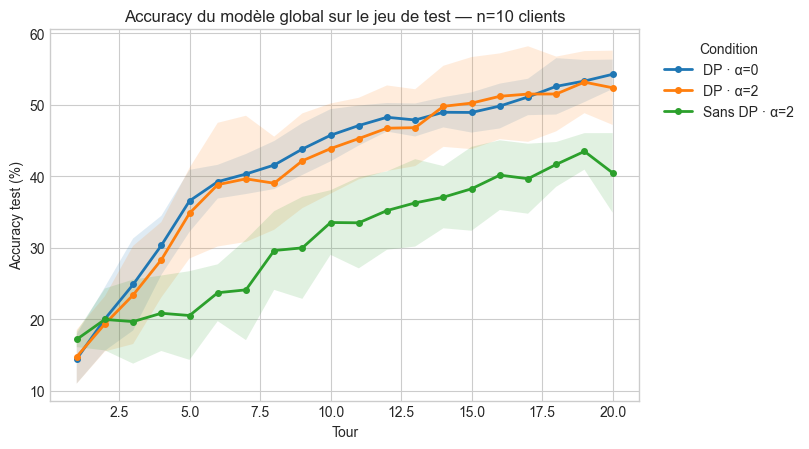

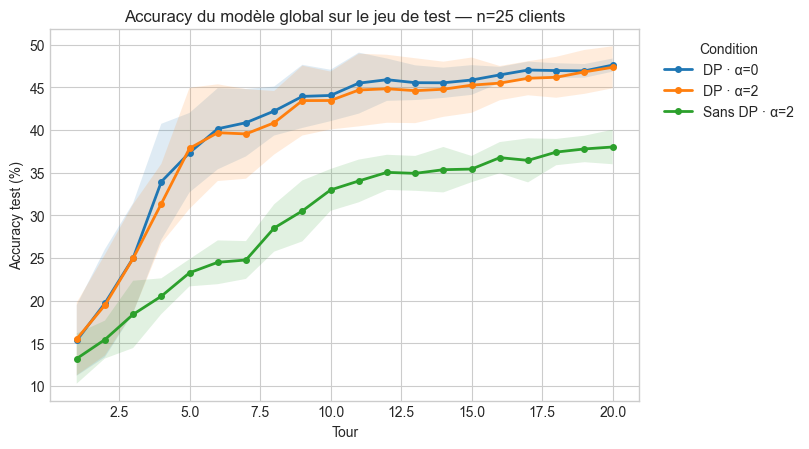

In [7]:
_plot_one_trajectory(
    trajectory_focus,
    "test_accuracy_pct",
    "Accuracy test (%)",
    "Accuracy du modèle global sur le jeu de test",
)

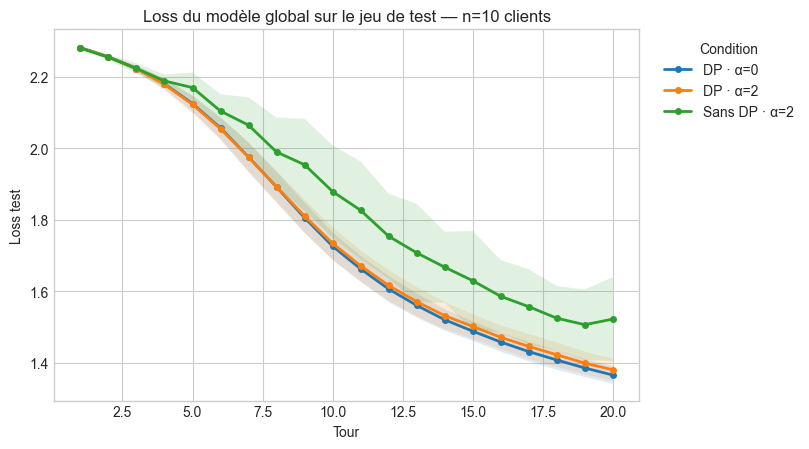

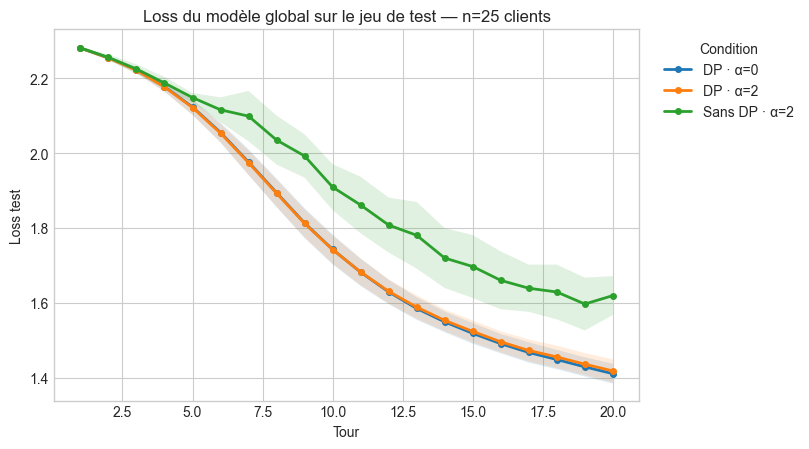

In [8]:
_plot_one_trajectory(
    trajectory_focus,
    "test_loss",
    "Loss test",
    "Loss du modèle global sur le jeu de test",
)

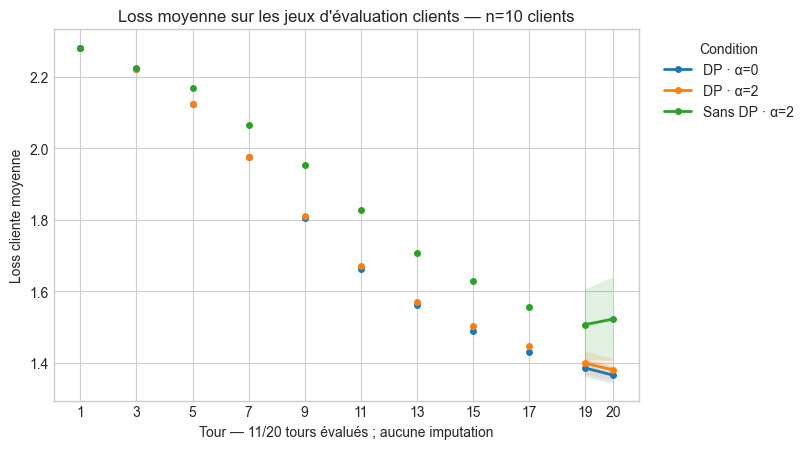

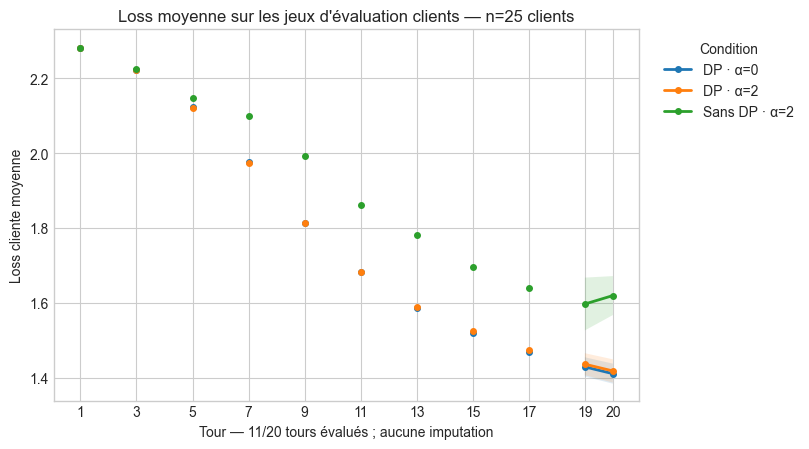

In [9]:
_plot_one_trajectory(
    trajectory_focus,
    "client_loss_heldout",
    "Loss cliente moyenne",
    "Loss moyenne sur les jeux d'évaluation clients",
)

In [10]:
metric_availability = pd.DataFrame([
    {
        "Métrique": "Train accuracy",
        "Champ": "train_accuracy",
        "Valeurs": int(rounds_df.train_accuracy_pct.notna().sum()),
        "Lecture": "Indisponible" if not rounds_df.train_accuracy_pct.notna().any() else "Disponible",
    },
    {
        "Métrique": "Train loss",
        "Champ": "train_loss hors placeholders privés",
        "Valeurs": int(rounds_df.train_loss.notna().sum()),
        "Lecture": "Indisponible" if not rounds_df.train_loss.notna().any() else "Disponible",
    },
    {
        "Métrique": "Test accuracy / loss",
        "Champ": "test_accuracy / test_loss",
        "Valeurs": int(rounds_df.test_accuracy_pct.notna().sum()),
        "Lecture": "Évaluation held-out",
    },
    {
        "Métrique": "Client loss",
        "Champ": "client_loss_mean",
        "Valeurs": int(rounds_df.client_loss_heldout.notna().sum()),
        "Lecture": "Moyenne held-out sur les clients",
    },
])
display(Markdown(
    "**Disponibilité.** Un zéro technique masqué par le transcript local-DP "
    "n'est jamais interprété comme une observation d'entraînement."
))
display(metric_availability)

**Disponibilité.** Un zéro technique masqué par le transcript local-DP n'est jamais interprété comme une observation d'entraînement.

,Métrique,Champ,Valeurs,Lecture
0,Train accuracy,train_accuracy,0,Indisponible
1,Train loss,train_loss hors placeholders privés,0,Indisponible
2,Test accuracy / loss,test_accuracy / test_loss,19400,Évaluation held-out
3,Client loss,client_loss_mean,13941,Moyenne held-out sur les clients


### 3.2 Le contrôle sans DP à α = 0 : présent dans E, absent dans F

Ce tableau compte les seeds réellement disponibles **sans attaque, à référence
FCC et à protocole fixé dans chaque phase**. Une case absente ne vaut pas zéro
accuracy. E utilise la seed 137 ; F utilise les seeds 28, 36 et 54. Leurs
estimations ne sont pas fusionnées. Dans E, les configurations sont identiques
hors α et mécanisme DP, mais une même seed ne garantit pas les mêmes batches
après chaque tirage de bruit : ce n'est pas un appariement aléatoire strict.

,Phase,Clients,Bruit DP,α,Seeds,Disponible,Accuracy test (%)
0,E : exploratoire,10,non,0.0,137,oui,54.29
1,E : exploratoire,10,non,2.0,137,oui,47.71
2,E : exploratoire,10,oui,0.0,137,oui,55.87
3,E : exploratoire,10,oui,2.0,137,oui,55.03
4,E : exploratoire,25,non,0.0,137,oui,50.31
5,E : exploratoire,25,non,2.0,137,oui,42.14
6,E : exploratoire,25,oui,0.0,137,oui,52.81
7,E : exploratoire,25,oui,2.0,137,oui,55.77
8,F : confirmation,10,non,0.0,,absent,—
9,F : confirmation,10,non,2.0,"28, 36, 54",oui,40.47


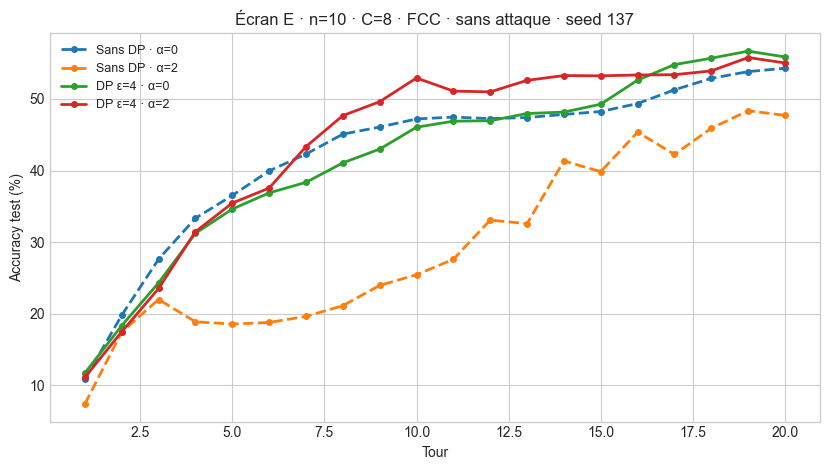

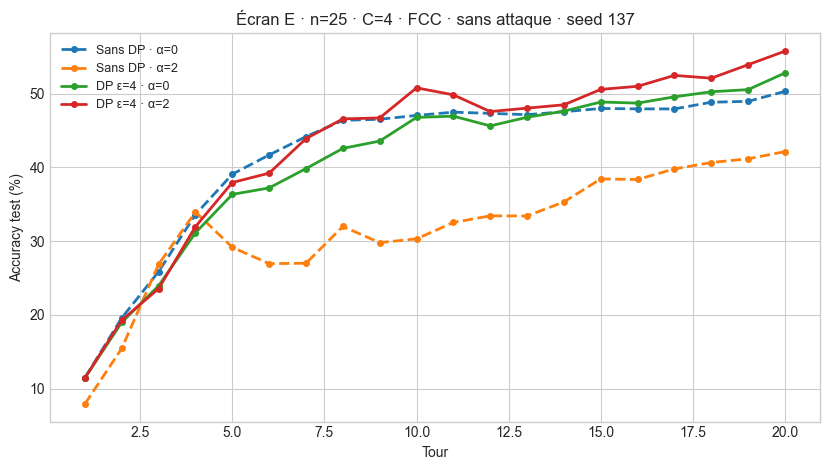

In [11]:
CONTROL_PHASES = ["e_byzantine_identification_screen", "f_confirmation_t20"]
control_data = final_df[
    (final_df.campaign == "positioning_v3")
    & final_df.phase.isin(CONTROL_PHASES)
    & (final_df.reference == "F_CC") & (final_df.attack == "none")
    & final_df.alpha.isin([0.0, 2.0])
].copy()
control_rows = []
for (phase, n), group in control_data.groupby(["phase", "n_clients"]):
    for dp in [False, True]:
        for alpha in [0.0, 2.0]:
            part = group[(group.dp_enabled == dp) & (group.alpha == alpha)]
            control_rows.append({
                "Phase": "E : exploratoire" if phase.startswith("e_") else "F : confirmation",
                "Clients": n, "Bruit DP": "oui" if dp else "non", "α": alpha,
                "Seeds": ", ".join(map(str, sorted(part.seed.unique()))),
                "Disponible": "oui" if len(part) else "absent",
                "Accuracy test (%)": "—" if part.empty else f"{part.test_accuracy_pct.mean():.2f}",
            })
control_table = pd.DataFrame(control_rows)
display(control_table)
control_table.to_csv(EXPORT_ROOT / "dp_alpha_control_coverage.csv", index=False)

alpha_figure_root = EXPORT_ROOT / "alpha_trajectories"
alpha_figure_root.mkdir(exist_ok=True)

def _save_alpha_figure(fig, name):
    fig.savefig(alpha_figure_root / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def _plot_controls_e(metric, ylabel):
    view = rounds_df[
        (rounds_df.campaign == "positioning_v3")
        & (rounds_df.phase == "e_byzantine_identification_screen")
        & (rounds_df.reference == "F_CC") & (rounds_df.attack == "none")
        & rounds_df.alpha.isin([0.0, 2.0])
    ].copy()
    for n, group in view.groupby("n_clients"):
        fig, ax = plt.subplots(figsize=(8.4, 4.8))
        for (dp, alpha), part in group.groupby(["dp_enabled", "alpha"]):
            values = part.groupby("round")[metric].mean()
            ax.plot(values.index, values, linewidth=2, marker="o", markersize=4,
                    label=f"{'DP ε=4' if dp else 'Sans DP'} · α={alpha:g}",
                    linestyle="-" if dp else "--")
        c = group.C_local.unique()
        assert len(c) == 1
        ax.set(xlabel="Tour", ylabel=ylabel,
               title=f"Écran E · n={n} · C={c[0]:g} · FCC · sans attaque · seed 137")
        _positioning_round_coverage_note(ax, group, metric)
        ax.legend(loc="best", fontsize=9)
        fig.tight_layout()
        _save_alpha_figure(fig, f"e_controls_{metric}_n{n}")

_plot_controls_e("test_accuracy_pct", "Accuracy test (%)")

### 3.3 Toutes les valeurs d'α : écran C sans DP

L'écran C a exécuté **−5, −2, −1, 0, 1, 2 et 5**, pour FCC, CM, trMean et RFA.
Les listes de sélection ci-dessous fixent les références et nombres de clients affichés ;
FCC est affichée par défaut. Les α négatifs et positifs ont chacun leur figure,
avec α = 0 comme repère commun. Toutes les valeurs sont ainsi visibles.

Il s'agit de **positioning_v1, C = 8, T = 20, seed 137, sans DP**. Les figures
ne sont pas des confirmations multi-seeds et ne doivent pas être superposées
aux courbes v3 à C = 4 pour n = 25.

**Points réellement observés.** Les métriques clientes (dont Worst-20 et gap) sont enregistrées tous les deux tours et au dernier tour : ici 1, 3, 5, …, 19 et 20. Les marqueurs rendent visibles ces observations isolées. Les trous restent non mesurés : aucune valeur n'est interpolée ou imputée, et les lignes/bandes ne franchissent pas ces trous. L'accuracy et la loss test restent disponibles aux 20 tours.

,Référence,Clients,C,Tours,Alphas,Seeds
0,CM,10,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
1,CM,25,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
2,F_CC,10,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
3,F_CC,25,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
4,RFA,10,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
5,RFA,25,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
6,trMean,10,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137
7,trMean,25,8.0,20,"-5, -2, -1, 0, 1, 2, 5",137


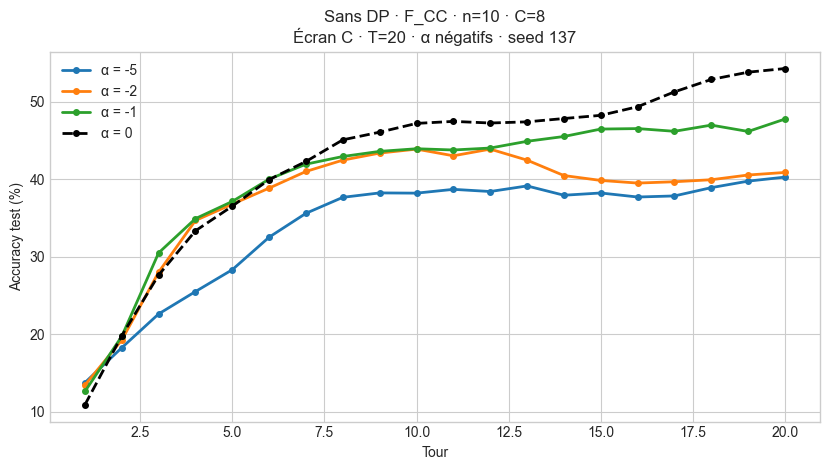

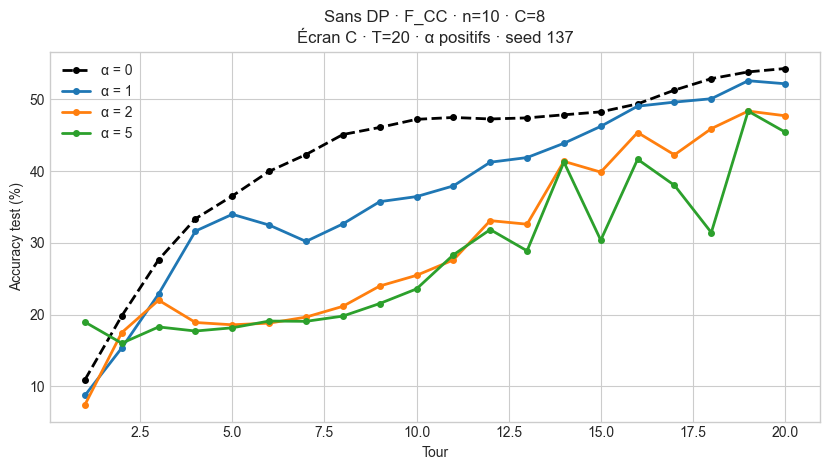

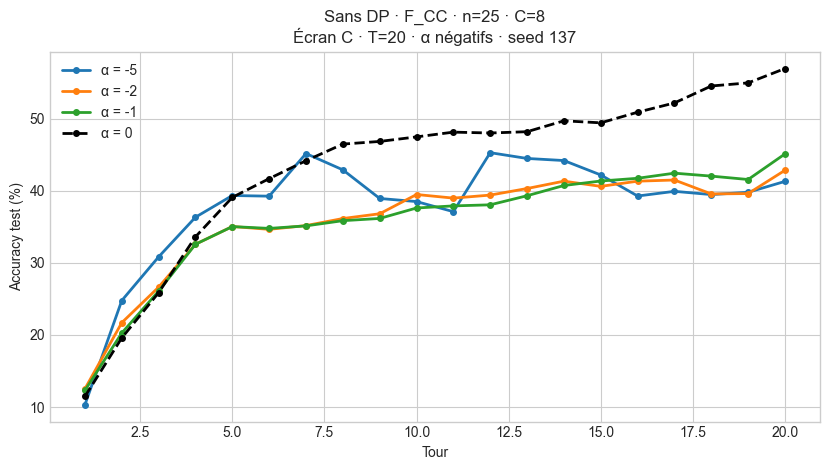

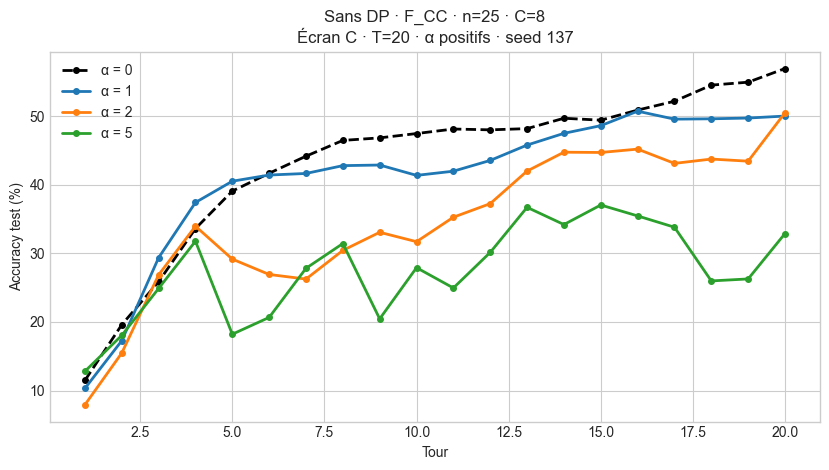

In [12]:
ALPHA_REFERENCES_TO_PLOT = ["F_CC"]  # Ajouter "CM", "trMean", "RFA" si souhaité.
ALPHA_CLIENTS_TO_PLOT = [10, 25]
alpha_all = rounds_df[
    (rounds_df.campaign == "positioning_v1")
    & (rounds_df.phase == "c_alpha_reference_screen")
    & (rounds_df.attack == "none") & ~rounds_df.dp_enabled
].copy()
alpha_availability = (alpha_all.drop_duplicates("run_uid")
    .groupby(["reference", "n_clients", "C_local", "horizon"])
    .agg(Alphas=("alpha", lambda s: ", ".join(f"{v:g}" for v in sorted(s.unique()))),
         Seeds=("seed", lambda s: ", ".join(map(str, sorted(s.unique())))))
    .reset_index().rename(columns={"reference":"Référence", "n_clients":"Clients",
                                  "C_local":"C", "horizon":"Tours"}))
display(alpha_availability)
alpha_availability.to_csv(EXPORT_ROOT / "alpha_trajectory_availability.csv", index=False)

def plot_all_alpha_trajectories(metric, ylabel):
    if alpha_all.empty:
        display(Markdown("**Écran C absent : aucune courbe inventée.**"))
        return
    chosen = alpha_all[alpha_all.reference.isin(ALPHA_REFERENCES_TO_PLOT)
                       & alpha_all.n_clients.isin(ALPHA_CLIENTS_TO_PLOT)]
    for (reference, n, c, horizon), group in chosen.groupby(
        ["reference", "n_clients", "C_local", "horizon"]
    ):
        for side, allowed in [("négatifs", [-5., -2., -1., 0.]),
                              ("positifs", [0., 1., 2., 5.])]:
            fig, ax = plt.subplots(figsize=(8.4, 4.8))
            for alpha, part in group[group.alpha.isin(allowed)].groupby("alpha"):
                stats = part.groupby("round")[metric].agg(["mean", "std", "count"])
                ax.plot(stats.index, stats["mean"], label=f"α = {alpha:g}",
                        color="black" if alpha == 0 else None,
                        linestyle="--" if alpha == 0 else "-", linewidth=2, marker="o", markersize=4)
                mask = stats["count"] > 1
                if mask.any():
                    ax.fill_between(stats.index,
                                    stats["mean"]-stats["std"],
                                    stats["mean"]+stats["std"], where=mask, alpha=.12)
            ax.set(xlabel="Tour", ylabel=ylabel,
                   title=f"Sans DP · {reference} · n={n} · C={c:g}\n"
                         f"Écran C · T={horizon} · α {side} · seed 137")
            _positioning_round_coverage_note(ax, group[group.alpha.isin(allowed)], metric)
            ax.legend(loc="best", fontsize=10)
            fig.tight_layout()
            _save_alpha_figure(fig, f"c_{metric}_{reference}_n{n}_{side}")

plot_all_alpha_trajectories("test_accuracy_pct", "Accuracy test (%)")

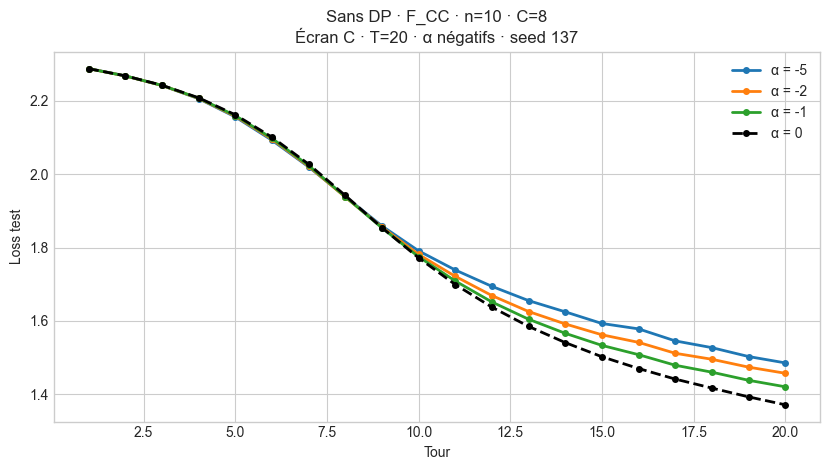

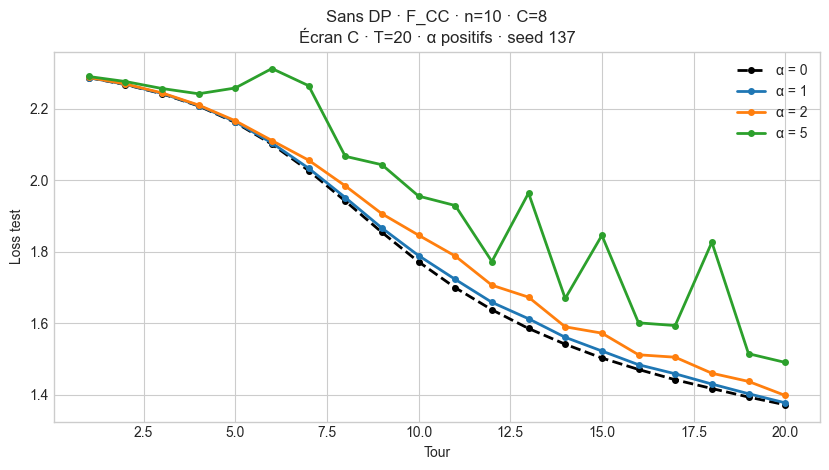

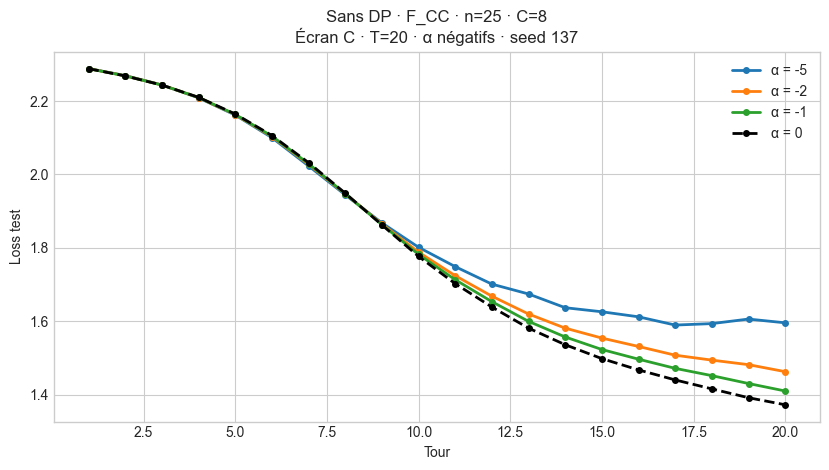

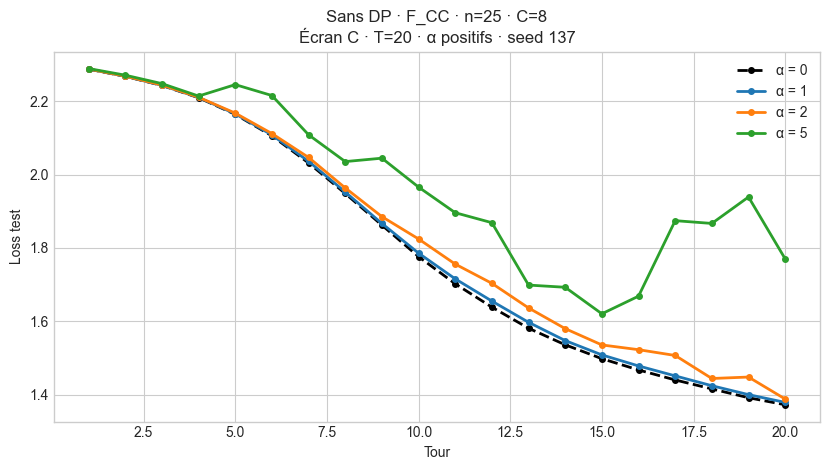

In [13]:
plot_all_alpha_trajectories("test_loss", "Loss test")

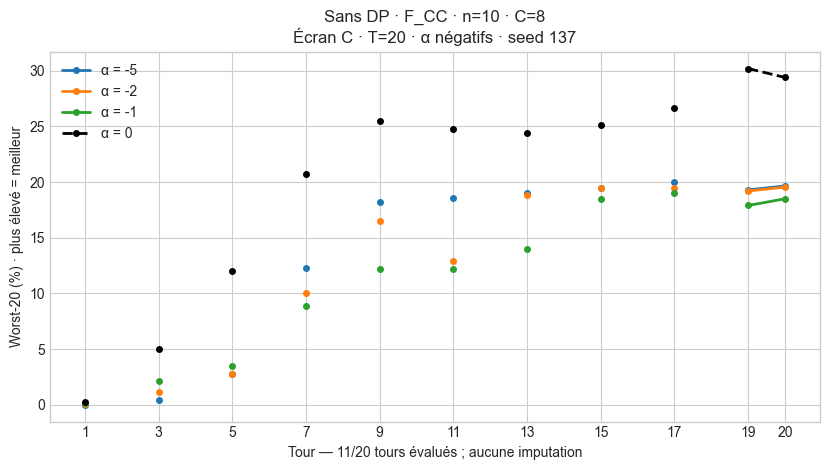

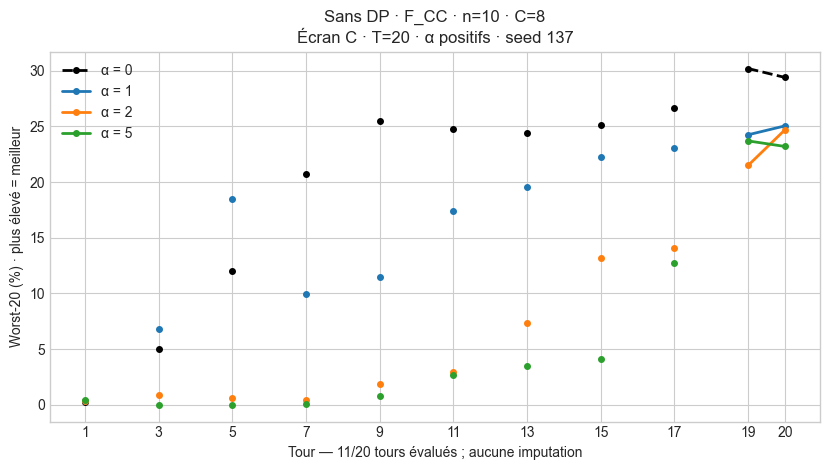

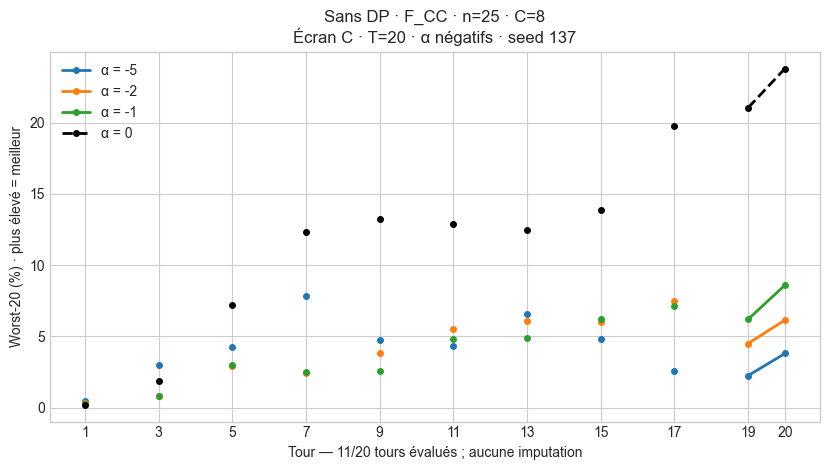

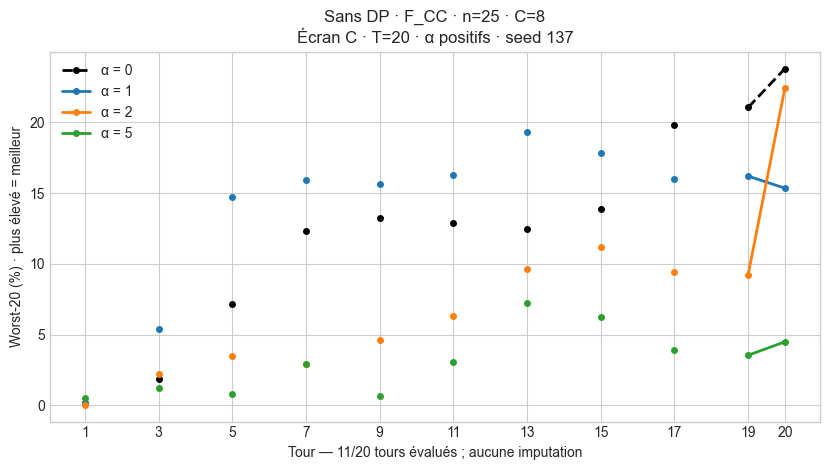

In [14]:
plot_all_alpha_trajectories("worst20_pct", "Worst-20 (%) · plus élevé = meilleur")

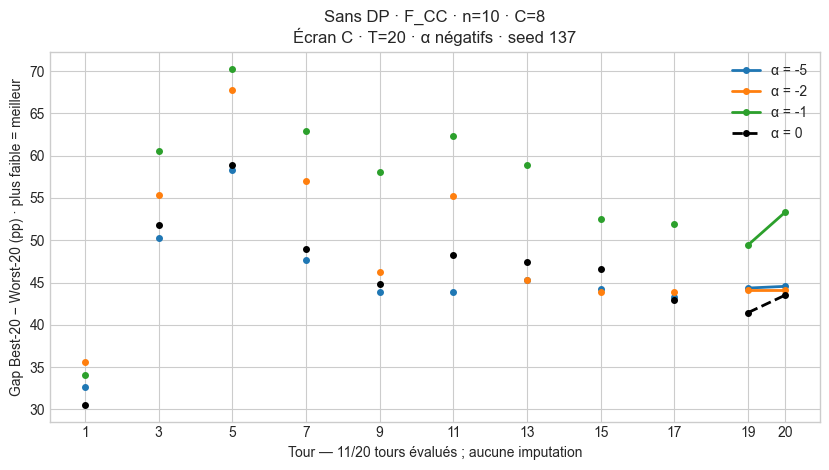

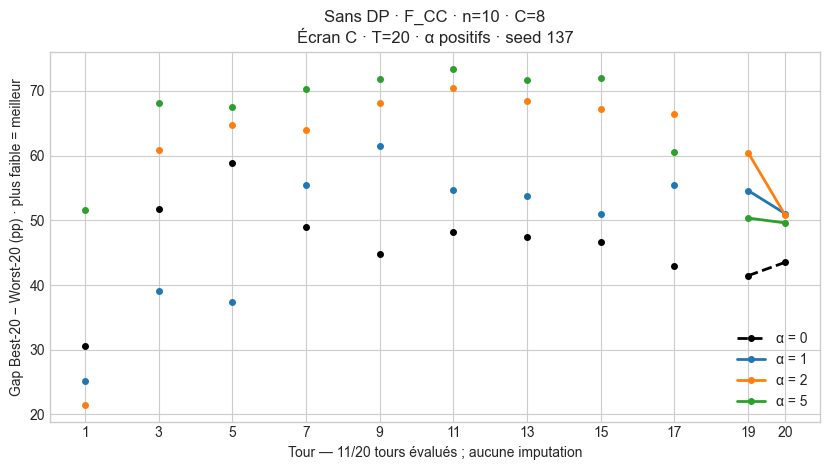

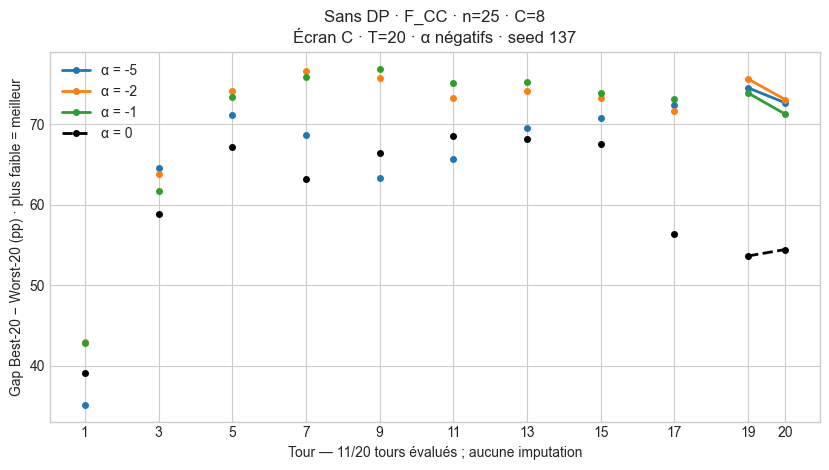

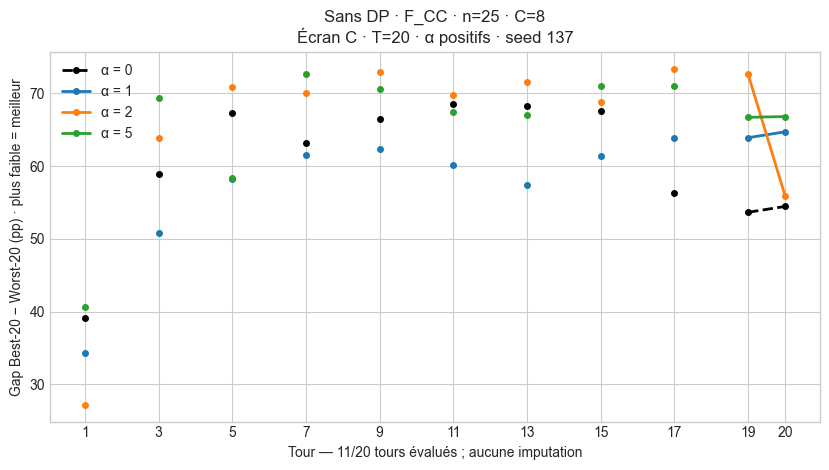

In [15]:
plot_all_alpha_trajectories("gap_pp", "Gap Best-20 − Worst-20 (pp) · plus faible = meilleur")

### 3.4 α négatif et positif avec DP : écran D

Les autres α de l'écran C n'ont pas tous été entraînés sous DP dans la
campagne positioning. D contient α = −2 et 2 aux budgets ε = 2, 4, 8.
Le budget choisi ci-dessous est fixé dans chaque figure ; il peut être changé
sans mélanger les runs. Les courbes sont exploratoires (seed 137).

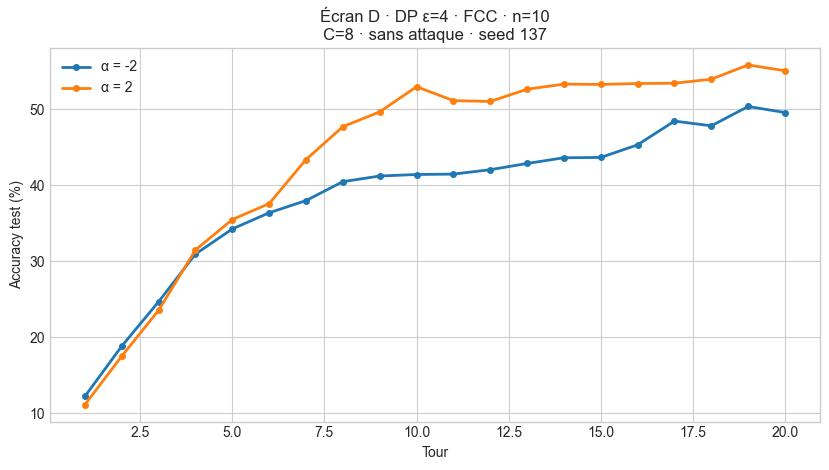

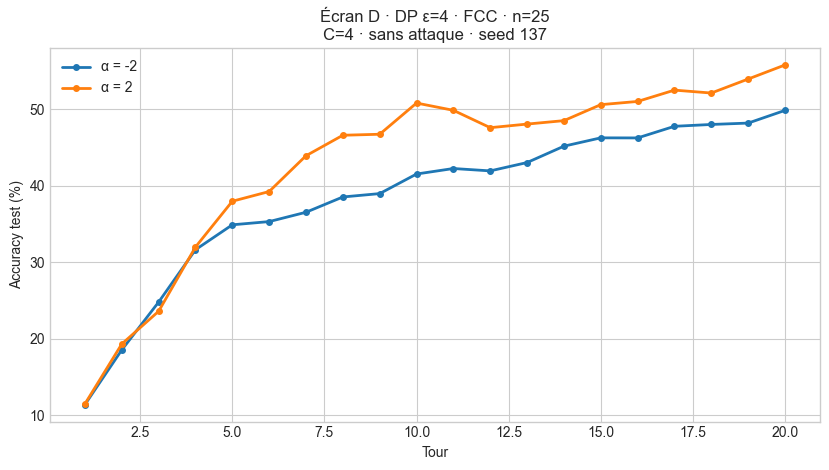

In [16]:
DP_ALPHA_EPSILON_TO_PLOT = 4.0  # Autres valeurs disponibles : 2.0 et 8.0.
dp_alpha_view = rounds_df[
    (rounds_df.campaign == "positioning_v3")
    & (rounds_df.phase == "d_privacy_screen_v3")
    & (rounds_df.reference == "F_CC") & (rounds_df.attack == "none")
    & np.isclose(rounds_df.target_epsilon, DP_ALPHA_EPSILON_TO_PLOT)
].copy()
for n, group in dp_alpha_view.groupby("n_clients"):
    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    for alpha, part in group.groupby("alpha"):
        stats = part.groupby("round").test_accuracy_pct.mean()
        ax.plot(stats.index, stats, linewidth=2, marker="o", markersize=4, label=f"α = {alpha:g}")
    ax.set(xlabel="Tour", ylabel="Accuracy test (%)",
           title=f"Écran D · DP ε={DP_ALPHA_EPSILON_TO_PLOT:g} · FCC · n={n}\n"
                 f"C={group.C_local.iloc[0]:g} · sans attaque · seed 137")
    ax.legend(loc="best")
    fig.tight_layout()
    _save_alpha_figure(fig, f"d_accuracy_eps{DP_ALPHA_EPSILON_TO_PLOT:g}_n{n}")

## 4. Accuracy et fairness finales

Les tableaux suivants conservent le nombre de seeds. Un faible gap ou une faible
variance n'est pas une amélioration si toutes les accuracies s'effondrent.

`balanced_accuracy_pct` est une accuracy équilibrée entre classes. La métrique
`balanced_performance_fairness` (BPF) est la variance des pertes clientes
held-out pondérée par les tailles clientes. Ce sont deux objets distincts :
le notebook ne les fusionne jamais et n'impute pas BPF lorsqu'elle est absente.

In [17]:
PERF_COLS = [
    "campaign", "phase", "horizon", "n_clients", "dp_enabled", "target_epsilon",
    "noise_profile", "noise_assignment", "C_local", "alpha", "reference", "attack", "n_seeds",
    "identifiability", "test_accuracy_pct_mean", "test_accuracy_pct_sd",
    "client_accuracy_pct_mean", "variance_pp2_mean", "worst20_pct_mean", "gap_pp_mean",
    "balanced_accuracy_pct_mean", "balanced_worst20_pct_mean", "balanced_gap_pp_mean",
    "balanced_performance_fairness_mean",
]
display(summary_df[PERF_COLS].sort_values(
    ["campaign", "phase", "n_clients", "alpha"], na_position="last"
).head(100))

available_balanced = final_df["balanced_accuracy_pct"].notna().sum() if len(final_df) else 0
display(Markdown(
    f"Balanced accuracy disponible dans **{available_balanced}/{len(final_df)}** runs finaux. "
    "Les cellules absentes restent `NaN` et ne sont pas imputées."
))

,campaign,phase,horizon,n_clients,dp_enabled,target_epsilon,noise_profile,noise_assignment,C_local,alpha,reference,attack,n_seeds,identifiability,test_accuracy_pct_mean,test_accuracy_pct_sd,client_accuracy_pct_mean,variance_pp2_mean,worst20_pct_mean,gap_pp_mean,balanced_accuracy_pct_mean,balanced_worst20_pct_mean,balanced_gap_pp_mean,balanced_performance_fairness_mean
0,fmnist_confirmatory_v1,unphased,40,10,True,4.0,heteroscedastic,custom_unspecified,8.0,0.0,F_NA-CC,none,3,multi-seed,59.340000,3.255718,59.340000,387.055933,28.533333,52.483333,59.111564,47.039051,28.104027,0.041641
3,fmnist_confirmatory_v1,unphased,40,10,True,4.0,homogeneous,homogeneous,8.0,0.0,F_NA-CC,none,3,multi-seed,64.646667,2.121140,64.646667,177.554333,44.833333,36.083333,64.496348,51.638090,25.501486,0.032097
1,fmnist_confirmatory_v1,unphased,40,10,True,4.0,heteroscedastic,custom_unspecified,8.0,1.0,F_CC,none,3,multi-seed,47.593333,4.737724,47.593333,754.817933,11.583333,68.016667,50.390728,34.382302,36.029042,0.167274
2,fmnist_confirmatory_v1,unphased,40,10,True,4.0,heteroscedastic,custom_unspecified,8.0,1.0,F_NA-CC,none,3,multi-seed,46.376667,3.862698,46.376667,811.848833,9.550000,70.450000,49.118824,32.551606,36.530603,0.404553
4,fmnist_confirmatory_v1,unphased,40,10,True,4.0,homogeneous,homogeneous,8.0,1.0,F_CC,none,3,multi-seed,64.253333,2.329213,64.253333,312.006333,34.533333,48.100000,63.441549,48.245488,29.211532,0.034970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,positioning_v2,b2_local_clip_dp_screen,20,10,True,4.0,homogeneous,homogeneous,8.0,0.0,F_CC,none,1,exploratory / non-identifiable (1 seed),55.870000,NaN,55.870000,288.296100,30.250000,47.000000,54.731518,45.156773,24.334361,0.048242
96,positioning_v2,b2_local_clip_dp_screen,20,10,True,4.0,homogeneous,homogeneous,16.0,0.0,F_CC,none,1,exploratory / non-identifiable (1 seed),49.820000,NaN,49.820000,269.047600,26.500000,47.650000,49.020499,37.277622,24.475843,0.038957
97,positioning_v2,b2_local_clip_dp_screen,20,25,True,4.0,homogeneous,homogeneous,4.0,0.0,F_CC,none,1,exploratory / non-identifiable (1 seed),52.810000,NaN,52.810000,596.966400,12.500000,70.200000,53.073630,35.054786,35.955193,0.080884
98,positioning_v2,b2_local_clip_dp_screen,20,25,True,4.0,homogeneous,homogeneous,8.0,0.0,F_CC,none,1,exploratory / non-identifiable (1 seed),49.690000,NaN,49.690000,513.276400,12.300000,64.400000,49.483690,32.999775,33.520425,0.031579


Balanced accuracy disponible dans **689/689** runs finaux. Les cellules absentes restent `NaN` et ne sont pas imputées.

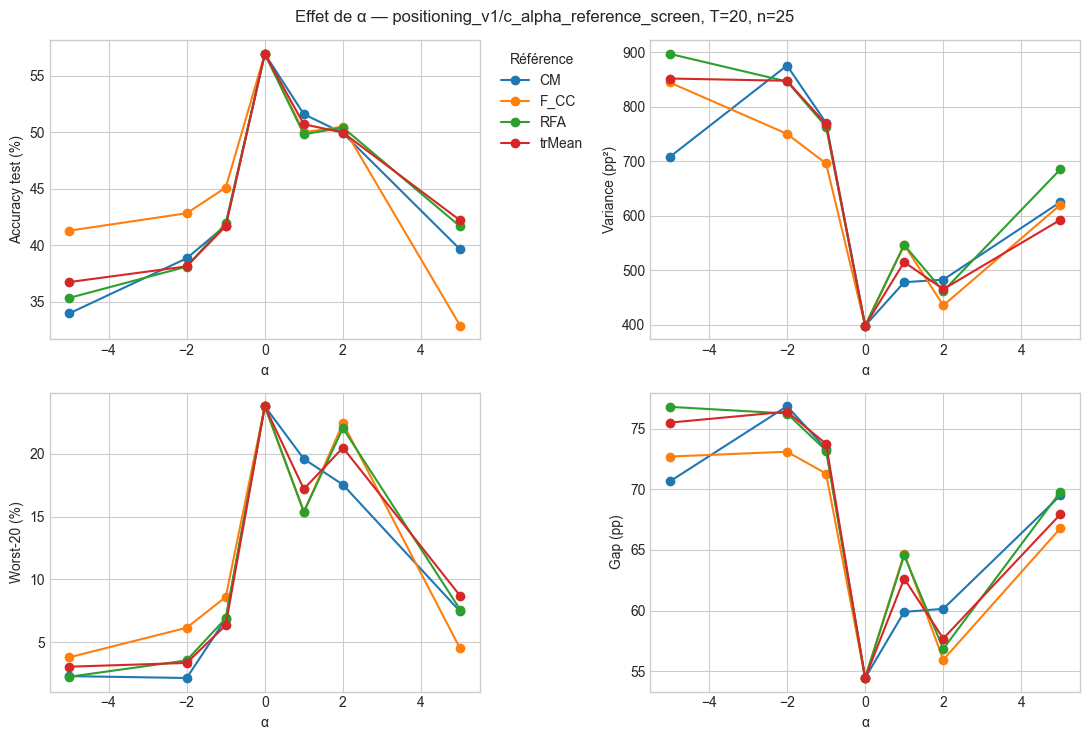

In [18]:
# Effet de alpha : une cellule compatible, choisie sans mélanger campagne,
# phase, horizon ou nombre de clients.
alpha_candidates = []
for (campaign, phase, horizon, n), group in final_df.groupby(
    ["campaign", "phase", "horizon", "n_clients"], dropna=False
):
    alpha_candidates.append((group.alpha.nunique(), len(group), campaign, phase, horizon, n))
alpha_candidates.sort(reverse=True)
if alpha_candidates and alpha_candidates[0][0] > 1:
    _, _, campaign, phase, horizon, n = alpha_candidates[0]
    alpha_view = final_df[
        (final_df.campaign == campaign) & (final_df.phase == phase)
        & (final_df.horizon == horizon) & (final_df.n_clients == n)
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
    for ax, metric, ylabel in zip(
        axes.ravel(),
        ["test_accuracy_pct", "variance_pp2", "worst20_pct", "gap_pp"],
        ["Accuracy test (%)", "Variance (pp²)", "Worst-20 (%)", "Gap (pp)"],
    ):
        for ref, group in alpha_view.groupby("reference"):
            stats = group.groupby("alpha")[metric].agg(["mean", "std", "count"]).reset_index()
            ax.plot(stats.alpha, stats["mean"], marker="o", label=ref)
        ax.set(xlabel="α", ylabel=ylabel)
    axes[0, 0].legend(title="Référence", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(f"Effet de α — {campaign}/{phase}, T={horizon}, n={n}")
    fig.tight_layout()
    plt.show()
else:
    display(Markdown("**Non identifiable : aucune strate ne contient plusieurs valeurs de α.**"))

## 5. Poids FAR : poids maximal, concentration et entropie

**Cette section sert à expliquer comment FAR agrège les gradients.** L'accuracy
et le Worst-20 donnent le résultat final ; les poids indiquent si FAR utilise
une pondération presque uniforme ou privilégie quelques clients. Ils aident
à comprendre pourquoi changer α ou la référence a parfois très peu d'effet.

Nous notons λᵢ les poids de FAR (les champs historiques du code utilisent parfois
`q`). Ils sont positifs et leur somme vaut 1. Ce λ ne désigne pas un budget DP.

| Indicateur | Uniforme | Information et exemple |
|---|---:|---|
| n × λ max | 1 | Domination du plus gros poids. À n = 10, une valeur 3 signifie λ max = 0,30, contre 0,10 uniforme. |
| Q = n × Σ λ² | 1 | Concentration de tous les poids. Q = 2 donne n/Q = n/2 clients effectifs au sens quadratique. |
| H / log(n) | 1 | Dispersion des poids : proche de 1, poids répartis ; proche de 0, un client domine. |
| exp(H) / n | 1 | Nombre effectif entropique, celui enregistré par le code. C'est une transformation de H, pas une quatrième preuve indépendante. |

$$
H(\lambda)=-\sum_i\lambda_i\log\lambda_i,\qquad
N_{2}=\frac{1}{\sum_i\lambda_i^2}=\frac{n}{Q},\qquad
N_H=\exp(H(\lambda)).
$$

Les deux nombres effectifs N₂ et N_H ne sont généralement pas égaux. Par exemple,
à n = 10, un poids de 0,30 et neuf poids de 0,70/9 donnent Q ≈ 1,444,
N₂ ≈ 6,92 et H/log(n) ≈ 0,933. Une entropie assez haute peut donc coexister avec
un client trois fois plus pondéré que sous uniforme.

**Lien précis avec le bruit.** Pour des poids fixés avant le bruit, et des
bruits centrés indépendants de même covariance Σ, on a

$$
\operatorname{tr}\operatorname{Cov}\left(\sum_i\lambda_i Z_i\right)
=\operatorname{tr}(\Sigma)\sum_i\lambda_i^2.
$$

Le rapport à l'uniforme vaut alors Q. Avec des covariances différentes,
le numérateur devient Σᵢ λᵢ² tr(Σᵢ). Dans FAR courant, les poids dépendent
des gradients bruités et le clipping serveur est non linéaire : **Q reste un
diagnostic de concentration, pas une mesure exacte de la variance DP réalisée**.

**Ce qu'il faut croiser.** Q proche de 1 explique un FAR presque uniforme ;
Q grand motive l'audit de l'identité des clients favorisés. Les corrélations
bruit–poids (section 8), la masse Byzantine (section 7), l'accuracy et le
Worst-20 permettent ensuite d'interpréter cette concentration. Aucun des
trois indicateurs ne distingue seul un honest outlier d'un attaquant et aucun
ne démontre la nécessité d'une référence temporelle RCIG.

Les vues ci-dessous concernent la phase F, T = 20, DP ε = 4, sans attaque.
Une médiane est d'abord calculée sur les tours de chaque run, puis ces médianes
sont moyennées entre seeds. Ce n'est pas une médiane sur un scalaire.

In [19]:
POSITIONING_RUN_LEVEL = (
    ROOT / "output" / "analysis" / "ldp_gradient_far_positioning_v3" / "run_level.csv"
)
if not POSITIONING_RUN_LEVEL.exists():
    raise FileNotFoundError(
        f"Artefact agrégé introuvable : {POSITIONING_RUN_LEVEL}. "
        "Exécuter d'abord l'analyse positioning_v3."
    )
positioning_run_level = pd.read_csv(POSITIONING_RUN_LEVEL)
reference_labels = {
    "coordinate_median": "CM", "centered_clipping": "F_CC",
    "rfa": "RFA", "trimmed_mean": "trMean",
}

# Les métriques de poids sont d'abord résumées par la médiane des tours dans
# chaque run, puis moyennées entre seeds. Cela évite qu'un dernier tour isolé
# représente toute la dynamique.
weights_focus = positioning_run_level[
    (positioning_run_level.phase == READABLE_PHASE)
    & positioning_run_level.dp_enabled.astype(str).str.lower().eq("true")
    & (positioning_run_level.attack == "none")
    & positioning_run_level.far_max_weight_median.notna()
].copy()
weights_focus["reference"] = weights_focus.robust_reference.map(reference_labels).fillna(
    weights_focus.robust_reference
)
weights_focus["n_qmax"] = weights_focus.num_clients * weights_focus.far_max_weight_median
weights_focus["entropy_normalized"] = (
    weights_focus.far_weight_entropy_median / np.log(weights_focus.num_clients)
)
weights_focus["effective_fraction"] = (
    weights_focus.far_effective_clients_median / weights_focus.num_clients
)

weight_summary = (
    weights_focus.groupby(["num_clients", "far_alpha", "reference"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        n_qmax=("n_qmax", "mean"),
        concentration=("far_weight_concentration_median", "mean"),
        entropy_normalized=("entropy_normalized", "mean"),
        effective_fraction=("effective_fraction", "mean"),
        score_span=("far_score_span_median", "mean"),
        logit_range=("far_logit_range_median", "mean"),
    )
    .reset_index()
    .rename(columns={
        "num_clients": "Clients", "far_alpha": "α", "reference": "Référence",
        "n_qmax": "n × poids max", "concentration": "n × Σ poids²",
        "entropy_normalized": "Entropie / log(n)",
        "effective_fraction": "Clients effectifs / n",
        "score_span": "Score-span médian", "logit_range": "Logit-range médian",
    })
)
display(Markdown(
    "### Concentration des poids\n\n"
    "Médiane sur les 20 tours de chaque run, puis moyenne entre seeds."
))
display(weight_summary[[
    "Clients", "α", "Référence", "Seeds", "n × poids max", "n × Σ poids²",
    "Entropie / log(n)", "Clients effectifs / n",
]].round({
    "n × poids max": 3, "n × Σ poids²": 3,
    "Entropie / log(n)": 3, "Clients effectifs / n": 3,
}))
display(Markdown(
    "### Géométrie des scores et logits\n\n"
    "Le score-span mesure l'étendue des distances utilisées par FAR ; le "
    "logit-range mesure l'étendue après multiplication par α."
))
display(weight_summary[[
    "Clients", "α", "Référence", "Seeds", "Score-span médian", "Logit-range médian",
]].round({"Score-span médian": 3, "Logit-range médian": 3}))
display(Markdown(
    "**Contrôle d'identité.** `Logit-range = |α| × score-span = "
    "log(q_max/q_min)`. Il mesure donc directement le contraste exponentiel "
    "entre le poids maximal et le poids minimal."
))

### Concentration des poids

Médiane sur les 20 tours de chaque run, puis moyenne entre seeds.

,Clients,α,Référence,Seeds,n × poids max,n × Σ poids²,Entropie / log(n),Clients effectifs / n
0,10,0.0,F_CC,3,1.000,1.000,1.000,1.000
1,10,2.0,CM,3,1.362,1.045,0.990,0.978
2,10,2.0,F_CC,3,1.329,1.041,0.991,0.980
3,10,2.0,RFA,3,1.360,1.047,0.990,0.977
4,10,2.0,trMean,3,1.358,1.045,0.990,0.978
5,25,0.0,F_CC,3,1.000,1.000,1.000,1.000
6,25,2.0,CM,3,1.378,1.023,0.997,0.989
7,25,2.0,F_CC,3,1.373,1.023,0.997,0.989
8,25,2.0,RFA,3,1.388,1.024,0.996,0.989
9,25,2.0,trMean,3,1.380,1.023,0.997,0.989


### Géométrie des scores et logits

Le score-span mesure l'étendue des distances utilisées par FAR ; le logit-range mesure l'étendue après multiplication par α.

,Clients,α,Référence,Seeds,Score-span médian,Logit-range médian
0,10,0.0,F_CC,3,0.331,0.000
1,10,2.0,CM,3,0.320,0.641
2,10,2.0,F_CC,3,0.308,0.616
3,10,2.0,RFA,3,0.324,0.649
4,10,2.0,trMean,3,0.317,0.634
5,25,0.0,F_CC,3,0.292,0.000
6,25,2.0,CM,3,0.293,0.586
7,25,2.0,F_CC,3,0.289,0.579
8,25,2.0,RFA,3,0.299,0.598
9,25,2.0,trMean,3,0.294,0.589


**Contrôle d'identité.** `Logit-range = |α| × score-span = log(q_max/q_min)`. Il mesure donc directement le contraste exponentiel entre le poids maximal et le poids minimal.

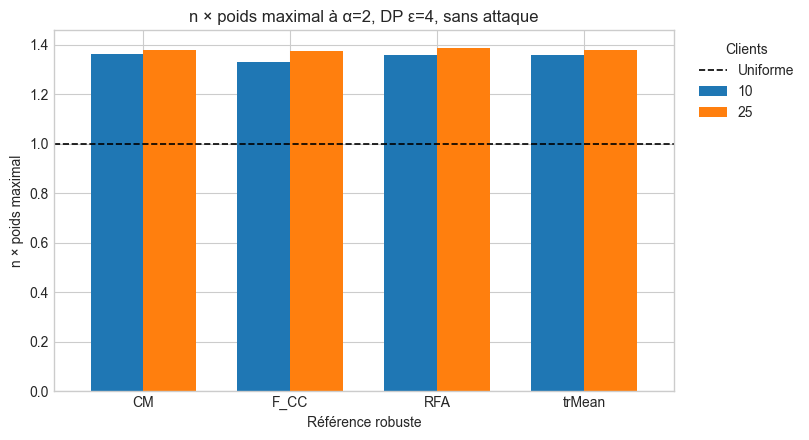

In [20]:
def _plot_weight_metric(column, ylabel, uniform_value):
    view = weight_summary[weight_summary["α"] == 2.0].copy()
    if view.empty:
        display(Markdown(f"**{ylabel} : données indisponibles.**"))
        return
    pivot = view.pivot(index="Référence", columns="Clients", values=column)
    ax = pivot.plot(kind="bar", figsize=(8.2, 4.5), width=0.72)
    ax.axhline(uniform_value, color="black", linestyle="--", linewidth=1.2, label="Uniforme")
    ax.set(xlabel="Référence robuste", ylabel=ylabel, title=f"{ylabel} à α=2, DP ε=4, sans attaque")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Clients", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


_plot_weight_metric("n × poids max", "n × poids maximal", 1.0)

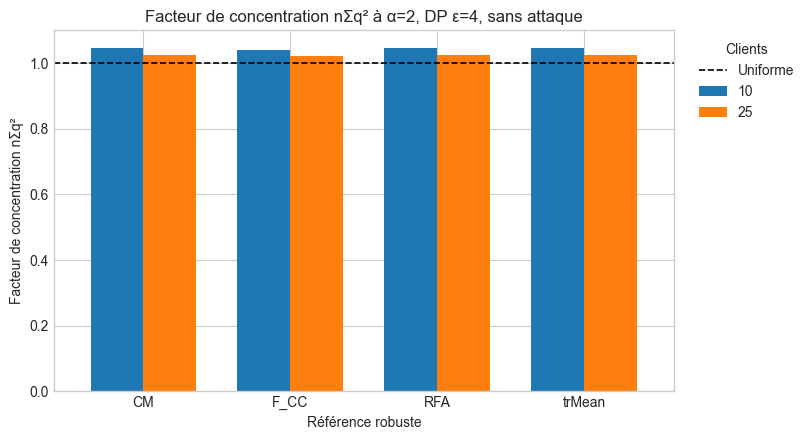

In [21]:
_plot_weight_metric("n × Σ poids²", "Facteur de concentration nΣq²", 1.0)

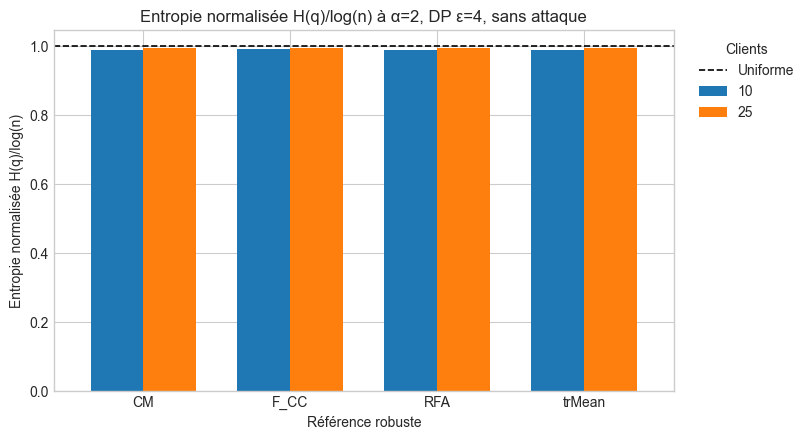

In [22]:
_plot_weight_metric("Entropie / log(n)", "Entropie normalisée H(q)/log(n)", 1.0)

In [23]:
if len(weight_summary):
    tilted = weight_summary[weight_summary["α"] > 0]
    display(Markdown(
        "**Lecture automatique.** Dans cette vue, le client le plus pondéré reçoit "
        f"entre **{tilted['n × poids max'].min():.2f}×** et "
        f"**{tilted['n × poids max'].max():.2f}×** le poids uniforme. "
        "Le facteur quadratique varie entre "
        f"**{tilted['n × Σ poids²'].min():.3f}** et "
        f"**{tilted['n × Σ poids²'].max():.3f}** ; l'entropie normalisée varie entre "
        f"**{tilted['Entropie / log(n)'].min():.3f}** et "
        f"**{tilted['Entropie / log(n)'].max():.3f}**. "
        "Ces valeurs quantifient la concentration ; elles ne prouvent pas à elles seules "
        "un gain ou une perte d'accuracy."
    ))

**Lecture automatique.** Dans cette vue, le client le plus pondéré reçoit entre **1.33×** et **1.39×** le poids uniforme. Le facteur quadratique varie entre **1.023** et **1.047** ; l'entropie normalisée varie entre **0.990** et **0.997**. Ces valeurs quantifient la concentration ; elles ne prouvent pas à elles seules un gain ou une perte d'accuracy.

### 5.1 Ce que ces diagnostics expliquent dans nos propres entraînements

Nous remettons ici côte à côte le contrôle uniforme, FAR sous DP et FAR sans
DP, avec l'accuracy et le Worst-20. Les poids sont résumés sur les tours de
chaque seed ; les performances sont celles du dernier tour. Cette lecture
évite de conclure « le bruit aide » simplement parce que DP/α=2 dépasse
sans-DP/α=2 : les deux trajectoires peuvent utiliser des poids très différents.

In [24]:
weight_bridge_source = trajectory_focus.copy()
weight_bridge_source["n_lambda_max"] = weight_bridge_source.n_clients * weight_bridge_source.max_weight
weight_bridge_source["entropy_fraction"] = weight_bridge_source.weight_entropy / np.log(weight_bridge_source.n_clients)
weight_per_run = (weight_bridge_source.groupby(["n_clients", "condition", "seed", "run_uid"])
    .agg(qmax=("n_lambda_max", "median"), concentration=("weight_concentration", "median"),
         entropy=("entropy_fraction", "median")).reset_index())
weight_bridge_final = trajectory_focus[trajectory_focus["round"] == trajectory_focus.horizon][
    ["run_uid", "test_accuracy_pct", "worst20_pct", "gap_pp"]]
weight_per_run = weight_per_run.merge(weight_bridge_final, on="run_uid", validate="one_to_one")
weight_bridge_rows = []
for (n, condition), part in weight_per_run.groupby(["n_clients", "condition"]):
    row = {"Clients":n, "Condition":condition, "Seeds":part.seed.nunique()}
    for source, label, digits in [
        ("qmax", "n × λ max", 3), ("concentration", "Q = n × Σ λ²", 3),
        ("entropy", "H / log(n)", 3), ("test_accuracy_pct", "Accuracy test (%)", 2),
        ("worst20_pct", "Worst-20 (%)", 2), ("gap_pp", "Gap (pp)", 2)]:
        row[label] = f"{part[source].mean():.{digits}f} ± {part[source].std(ddof=1):.{digits}f}"
    weight_bridge_rows.append(row)
weight_bridge = pd.DataFrame(weight_bridge_rows)
for n, part in weight_bridge.groupby("Clients"):
    display(Markdown(f"**n = {n} — moyenne ± écart-type entre seeds.**"))
    display(part.drop(columns="Clients"))
weight_bridge.to_csv(EXPORT_ROOT / "weight_mechanism_and_performance.csv", index=False)
display(Markdown(
    "**Lecture pour RCIG.** Une référence mieux estimée peut ne presque rien changer "
    "à l'agrégat lorsque Q ≈ 1. Si Q augmente, il reste à vérifier que les clients "
    "favorisés portent un signal honnête et pas surtout du bruit ou une attaque. "
    "La section 8.1 relie cette difficulté aux essais mécanistiques temporels."
))

**n = 10 — moyenne ± écart-type entre seeds.**

,Condition,Seeds,n × λ max,Q = n × Σ λ²,H / log(n),Accuracy test (%),Worst-20 (%),Gap (pp)
0,DP · α=0,3,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,54.28 ± 2.06,30.20 ± 5.78,44.38 ± 11.35
1,DP · α=2,3,1.329 ± 0.072,1.041 ± 0.022,0.991 ± 0.005,52.39 ± 5.20,20.52 ± 6.00,57.15 ± 7.73
2,Sans DP · α=2,3,2.617 ± 0.332,1.569 ± 0.313,0.884 ± 0.068,40.47 ± 5.57,7.38 ± 5.58,67.58 ± 11.72


**n = 25 — moyenne ± écart-type entre seeds.**

,Condition,Seeds,n × λ max,Q = n × Σ λ²,H / log(n),Accuracy test (%),Worst-20 (%),Gap (pp)
3,DP · α=0,3,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,47.61 ± 0.77,15.45 ± 5.15,60.80 ± 2.61
4,DP · α=2,3,1.373 ± 0.075,1.023 ± 0.007,0.997 ± 0.001,47.35 ± 2.46,15.43 ± 4.11,60.90 ± 4.01
5,Sans DP · α=2,3,4.303 ± 0.711,2.109 ± 0.642,0.875 ± 0.071,38.01 ± 2.02,4.78 ± 2.95,69.88 ± 9.85


**Lecture pour RCIG.** Une référence mieux estimée peut ne presque rien changer à l'agrégat lorsque Q ≈ 1. Si Q augmente, il reste à vérifier que les clients favorisés portent un signal honnête et pas surtout du bruit ou une attaque. La section 8.1 relie cette difficulté aux essais mécanistiques temporels.

## 6. Confidentialité, niveau de bruit et clipping

Cette section montre directement comment le budget de confidentialité, le
niveau de bruit et le seuil de clipping sont associés aux métriques finales.
Elle sépare deux expériences :

1. **écran D** : $\varepsilon\in\{2,4,8\}$, donc le bruit change alors que
   $C$ reste fixé pour chaque nombre de clients ;
2. **confirmation B3** : $C\in\{4,8,16\}$ à $\varepsilon=4$, sur trois
   seeds. Changer $C$ change simultanément le clipping et l'écart-type absolu
   du bruit $\sigma C/m$ : B3 mesure donc un effet conjoint, pas l'effet pur
   du clipping.

Chaque figure contient une seule métrique de résultat.

| Quantité | Unité | Question à laquelle elle répond |
|---|---:|---|
| $\varepsilon$ réalisé | sans unité | le budget comptabilisé correspond-il à la cible ? Plus petit signifie davantage de confidentialité |
| multiplicateur $\sigma$ | sans unité | combien de bruit est ajouté relativement au seuil de clipping local ? Plus grand signifie davantage de bruit |
| clipping local | % de gradients individuels | quelle part dépasse la borne locale avant bruit ? `NaN` signifie non publié, jamais zéro |
| clipping serveur | % d'uploads | quelle part des messages privés dépasse la borne serveur et est ramenée sur la boule ? |

Le multiplicateur $\sigma$ et $\varepsilon$ ne sont pas deux axes
indépendants : à protocole fixé, davantage de bruit produit généralement un
$\varepsilon$ plus faible. Dans les figures de l'écran D, l'axe horizontal
est $\varepsilon$ et chaque point est annoté par l'écart-type effectif
$\sigma C/m$. L'écran D n'a qu'une seed : ses courbes sont exploratoires.

In [25]:
privacy_screen = final_df[
    (final_df.campaign == READABLE_CAMPAIGN)
    & (final_df.phase == "d_privacy_screen_v3")
    & (final_df.reference == "F_CC")
    & np.isclose(final_df.alpha, 2.0)
    & (final_df.attack == "none")
].copy()

# Les paramètres sont lus dans le config exact de chaque metrics.json plutôt
# que réinférés depuis le nom du run.
def _privacy_config_fields(metrics_path):
    payload = json.loads(Path(metrics_path).read_text(encoding="utf-8"))
    config = payload["config"]
    batch = int(config.get("fixed_batch_size", config.get("batch_size")))
    return pd.Series({
        "batch_size": batch,
        "C_config": float(config["clip_norm"]),
        "U_config": float(config["far_server_clip_norm"]),
    })


privacy_screen[["batch_size", "C_config", "U_config"]] = privacy_screen.metrics_path.apply(
    _privacy_config_fields
)
privacy_screen["coord_noise_std"] = (
    privacy_screen.sigma_mean * privacy_screen.C_config / privacy_screen.batch_size
)
privacy_screen["replace_one_sensitivity"] = (
    2.0 * privacy_screen.C_config / privacy_screen.batch_size
)

privacy_table = (
    privacy_screen.groupby(["n_clients", "target_epsilon"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        C_local=("C_config", "mean"),
        batch_size=("batch_size", "mean"),
        U_server=("U_config", "mean"),
        epsilon_realise=("epsilon", "mean"),
        delta=("delta", "mean"),
        sigma_min=("sigma_min", "mean"),
        sigma_moyen=("sigma_mean", "mean"),
        sigma_max=("sigma_max", "mean"),
        coord_noise_std=("coord_noise_std", "mean"),
        replace_one_sensitivity=("replace_one_sensitivity", "mean"),
        clipping_serveur=("server_clip_rate", "mean"),
        accuracy=("test_accuracy_pct", "mean"),
        test_loss=("test_loss", "mean"),
        variance=("variance_pp2", "mean"),
        worst20=("worst20_pct", "mean"),
        gap=("gap_pp", "mean"),
    )
    .reset_index()
)
privacy_table["clipping_serveur"] *= 100.0
privacy_table = privacy_table.rename(columns={
    "n_clients": "Clients", "target_epsilon": "ε cible",
    "C_local": "C local", "batch_size": "Batch fixe",
    "U_server": "U serveur",
    "epsilon_realise": "ε réalisé", "delta": "δ",
    "sigma_min": "σ min", "sigma_moyen": "σ moyen", "sigma_max": "σ max",
    "coord_noise_std": "É.-t. bruit/coord. σC/m",
    "replace_one_sensitivity": "Sensibilité 2C/m",
    "clipping_serveur": "Uploads clippés (%)",
    "accuracy": "Accuracy test (%)", "test_loss": "Loss test",
    "variance": "Variance (pp²)", "worst20": "Worst-20 (%)",
    "gap": "Gap (pp)",
})
display(Markdown(
    "**Écran privacy D.** Les cellules sont exploratoires lorsqu'une seule seed "
    "est présente ; elles servent ici à lire le calibrage, pas à estimer une incertitude."
))
display(Markdown("### Ledger du mécanisme DP"))
display(privacy_table[[
    "Clients", "ε cible", "Seeds", "C local", "Batch fixe", "U serveur",
    "σ min", "σ moyen", "σ max", "É.-t. bruit/coord. σC/m",
    "Sensibilité 2C/m", "ε réalisé", "δ",
]].round({
    "ε cible": 3, "ε réalisé": 4, "δ": 7, "σ min": 3,
    "σ moyen": 3, "σ max": 3, "É.-t. bruit/coord. σC/m": 4,
    "Sensibilité 2C/m": 4,
}))
display(Markdown("### Résultats et clipping serveur"))
display(privacy_table[[
    "Clients", "ε cible", "Seeds", "Accuracy test (%)", "Loss test",
    "Variance (pp²)", "Worst-20 (%)", "Gap (pp)",
    "Uploads clippés (%)",
]].round({
    "ε cible": 3, "Accuracy test (%)": 2, "Loss test": 3,
    "Variance (pp²)": 1, "Worst-20 (%)": 2,
    "Gap (pp)": 2, "Uploads clippés (%)": 1,
}))
display(Markdown(
    "**Clipping local sous DP.** Le taux data-dependent n'est volontairement "
    "pas publié par ces runs (`NaN`) ; il n'est donc ni affiché ni remplacé par zéro. "
    "Pour le mécanisme à batch fixe, le runner ajoute au gradient moyen un bruit "
    "par coordonnée d'écart-type $\\sigma C/m$, et la sensibilité replace-one "
    "certifiée du gradient moyen vaut $2C/m$."
))

**Écran privacy D.** Les cellules sont exploratoires lorsqu'une seule seed est présente ; elles servent ici à lire le calibrage, pas à estimer une incertitude.

### Ledger du mécanisme DP

,Clients,ε cible,Seeds,C local,Batch fixe,U serveur,σ min,σ moyen,σ max,É.-t. bruit/coord. σC/m,Sensibilité 2C/m,ε réalisé,δ
0,10,2.0,1,8.0,300.0,16.0,2.694,2.694,2.694,0.0718,0.0533,2.0000,0.00001
1,10,4.0,1,8.0,300.0,16.0,1.836,1.836,1.836,0.0490,0.0533,4.0001,0.00001
2,10,8.0,1,8.0,300.0,16.0,1.326,1.326,1.326,0.0354,0.0533,8.0000,0.00001
3,25,2.0,1,4.0,120.0,16.0,2.694,2.694,2.694,0.0898,0.0667,2.0000,0.00001
4,25,4.0,1,4.0,120.0,16.0,1.836,1.836,1.836,0.0612,0.0667,4.0001,0.00001
5,25,8.0,1,4.0,120.0,16.0,1.326,1.326,1.326,0.0442,0.0667,8.0000,0.00001


### Résultats et clipping serveur

,Clients,ε cible,Seeds,Accuracy test (%),Loss test,Variance (pp²),Worst-20 (%),Gap (pp),Uploads clippés (%)
0,10,2.0,1,54.95,1.393,276.7,29.35,46.35,100.0
1,10,4.0,1,55.03,1.353,331.4,27.65,50.65,0.0
2,10,8.0,1,54.84,1.361,330.2,26.90,50.80,0.0
3,25,2.0,1,50.67,1.531,585.7,11.40,70.50,100.0
4,25,4.0,1,55.77,1.394,486.7,19.80,61.90,0.0
5,25,8.0,1,56.50,1.400,435.6,20.95,58.85,0.0


**Clipping local sous DP.** Le taux data-dependent n'est volontairement pas publié par ces runs (`NaN`) ; il n'est donc ni affiché ni remplacé par zéro. Pour le mécanisme à batch fixe, le runner ajoute au gradient moyen un bruit par coordonnée d'écart-type $\sigma C/m$, et la sensibilité replace-one certifiée du gradient moyen vaut $2C/m$.

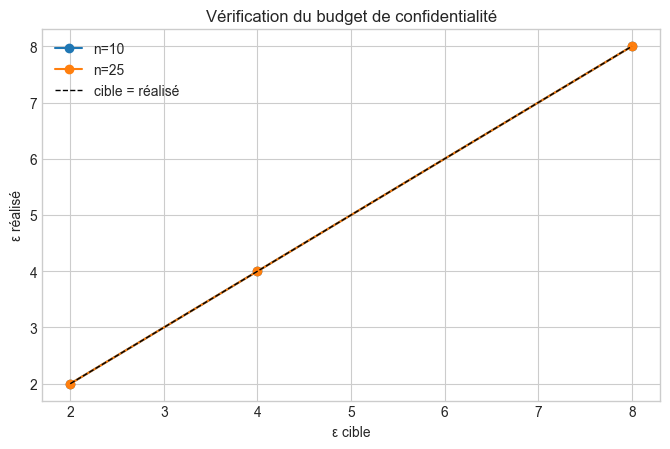

In [26]:
if len(privacy_table):
    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    for n_clients, group in privacy_table.groupby("Clients"):
        ax.plot(group["ε cible"], group["ε réalisé"], marker="o", label=f"n={int(n_clients)}")
    lo = float(min(privacy_table["ε cible"].min(), privacy_table["ε réalisé"].min()))
    hi = float(max(privacy_table["ε cible"].max(), privacy_table["ε réalisé"].max()))
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="cible = réalisé")
    ax.set(xlabel="ε cible", ylabel="ε réalisé", title="Vérification du budget de confidentialité")
    ax.legend()
    fig.tight_layout()
    plt.show()

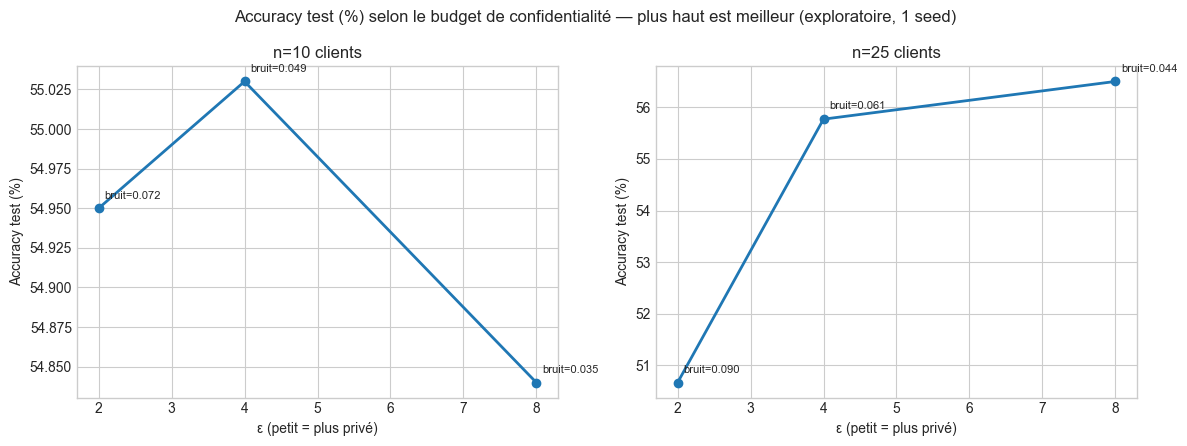

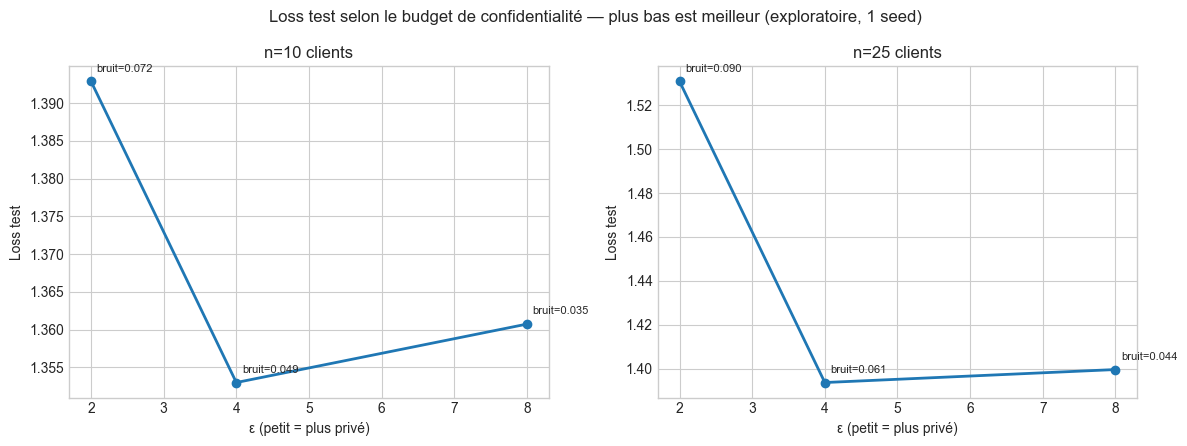

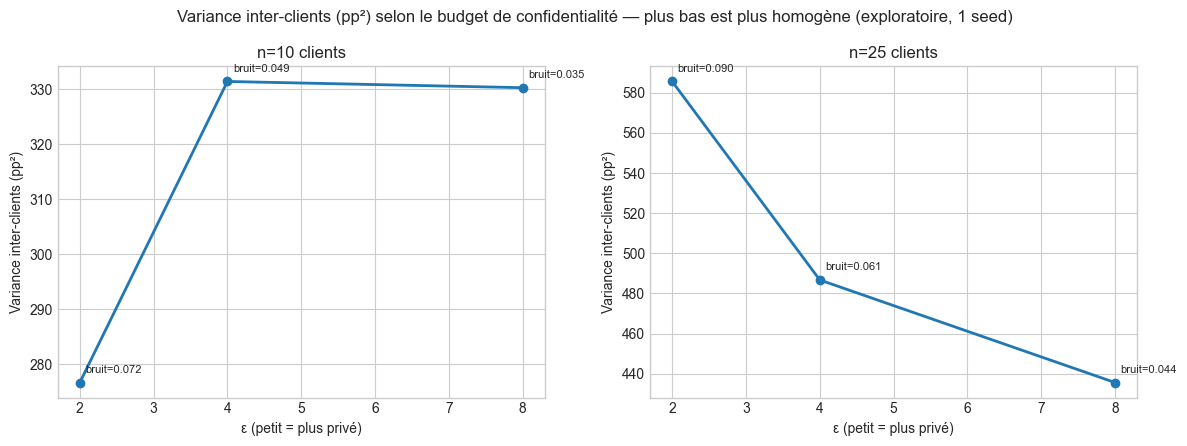

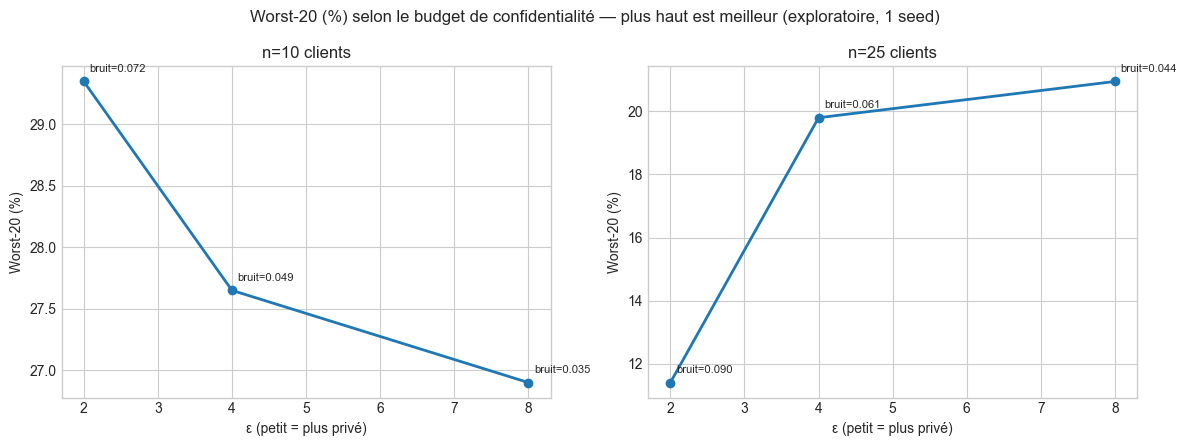

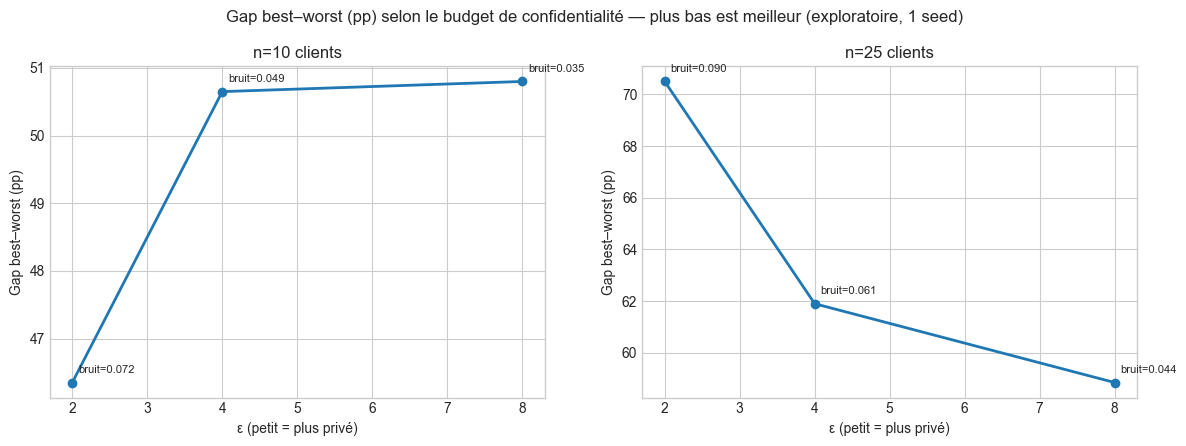

**Lecture.** Pour chaque nombre de clients, $C$, le batch, la référence et $\alpha$ sont fixes. Lorsque $\varepsilon$ augmente de 2 à 8, $\sigma$ et $\sigma C/m$ diminuent. Les annotations donnent le niveau de bruit effectivement ajouté par coordonnée. Comme l'écran ne contient qu'une seed, une pente ne doit pas être présentée comme une loi générale.

In [27]:
def _plot_privacy_outcome(metric, ylabel, better):
    if privacy_table.empty or not privacy_table[metric].notna().any():
        display(Markdown(f"**{metric} : données indisponibles.**"))
        return
    client_values = sorted(privacy_table["Clients"].dropna().unique())
    fig, axes = plt.subplots(
        1, len(client_values), figsize=(6.0 * len(client_values), 4.5),
        squeeze=False,
    )
    for ax, n_clients in zip(axes.ravel(), client_values):
        group = privacy_table[privacy_table["Clients"] == n_clients].copy()
        group = group.sort_values("ε cible")
        ax.plot(
            group["ε cible"], group[metric], marker="o", linewidth=2,
        )
        for _, row in group.iterrows():
            ax.annotate(
                f"bruit={row['É.-t. bruit/coord. σC/m']:.3f}",
                (row["ε cible"], row[metric]), xytext=(4, 7),
                textcoords="offset points", fontsize=8,
            )
        ax.set(
            xlabel="ε (petit = plus privé)", ylabel=ylabel,
            title=f"n={int(n_clients)} clients",
        )
    fig.suptitle(f"{ylabel} selon le budget de confidentialité — {better} (exploratoire, 1 seed)")
    fig.tight_layout(); plt.show()


_plot_privacy_outcome("Accuracy test (%)", "Accuracy test (%)", "plus haut est meilleur")
_plot_privacy_outcome("Loss test", "Loss test", "plus bas est meilleur")
_plot_privacy_outcome("Variance (pp²)", "Variance inter-clients (pp²)", "plus bas est plus homogène")
_plot_privacy_outcome("Worst-20 (%)", "Worst-20 (%)", "plus haut est meilleur")
_plot_privacy_outcome("Gap (pp)", "Gap best–worst (pp)", "plus bas est meilleur")

display(Markdown(
    "**Lecture.** Pour chaque nombre de clients, $C$, le batch, la référence "
    r"et $\alpha$ sont fixes. Lorsque $\varepsilon$ augmente de 2 à 8, "
    r"$\sigma$ et $\sigma C/m$ diminuent. Les annotations donnent le niveau "
    "de bruit effectivement ajouté par coordonnée. Comme l'écran ne contient "
    "qu'une seed, une pente ne doit pas être présentée comme une loi générale."
))

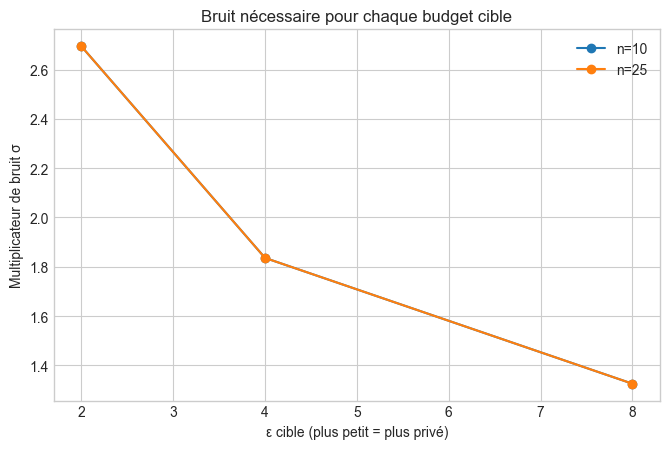

In [28]:
if len(privacy_table):
    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    for n_clients, group in privacy_table.groupby("Clients"):
        group = group.sort_values("ε cible")
        ax.plot(group["ε cible"], group["σ moyen"], marker="o", label=f"n={int(n_clients)}")
    ax.set(
        xlabel="ε cible (plus petit = plus privé)",
        ylabel="Multiplicateur de bruit σ",
        title="Bruit nécessaire pour chaque budget cible",
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

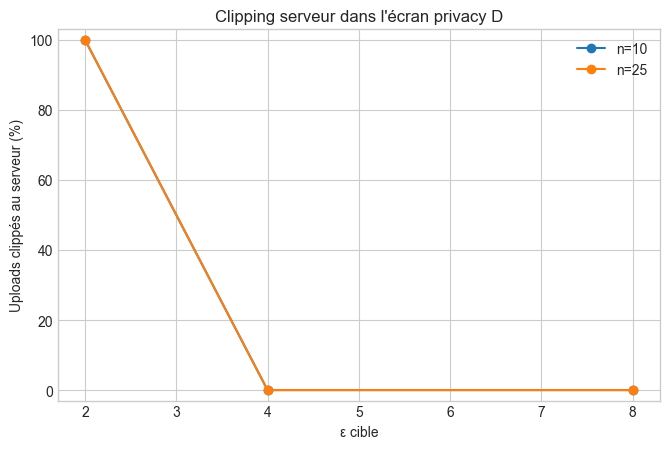

**Note F-confirmation.** Dans F-confirmation, le taux serveur observé vaut 0.0–0.0 %. Le taux local sous DP reste non publié. Une courbe plate à zéro ne démontrerait pas l'utilité du clipping serveur ; elle indique seulement que ce seuil n'est pas actif dans cette cellule.

**Lecture automatique.** L'écart maximal $|\varepsilon_{réalisé}-\varepsilon_{cible}|$ vaut **9.028e-05**. Dans l'écran D, le clipping serveur varie de 0.0 % à 100.0 %. Un taux de 100 % indique que tous les uploads dépassent le seuil serveur ; cela signale un calibrage géométrique très contraignant, pas un gain d'utilité.

## 6.2 Impact conjoint du seuil local C et du bruit absolu

**B3-confirmation :** trois seeds, $\varepsilon=4$, FCC, $\alpha=0$, sans attaque. Le taux de clipping local dépendant des données n'est pas publié. Le taux serveur et $\sigma C/m$ permettent néanmoins de voir quand la géométrie du mécanisme change.

,Clients,C local,Seeds,É.-t. bruit/coord.,Uploads serveur clippés (%),Accuracy moyenne,Loss moyenne,Variance moyenne,Worst-20 moyen,Gap moyen
0,10,4.0,3,0.024,0.0,47.923,1.428,465.243,20.967,58.017
1,10,8.0,3,0.049,0.0,52.223,1.392,417.680,24.117,55.217
2,10,16.0,3,0.098,100.0,47.793,1.576,405.112,22.450,55.317
3,25,4.0,3,0.061,0.0,48.637,1.423,530.842,16.350,63.867
4,25,8.0,3,0.122,100.0,46.520,1.713,532.592,14.600,64.650
5,25,16.0,3,0.245,100.0,39.660,2.100,565.890,10.067,65.500


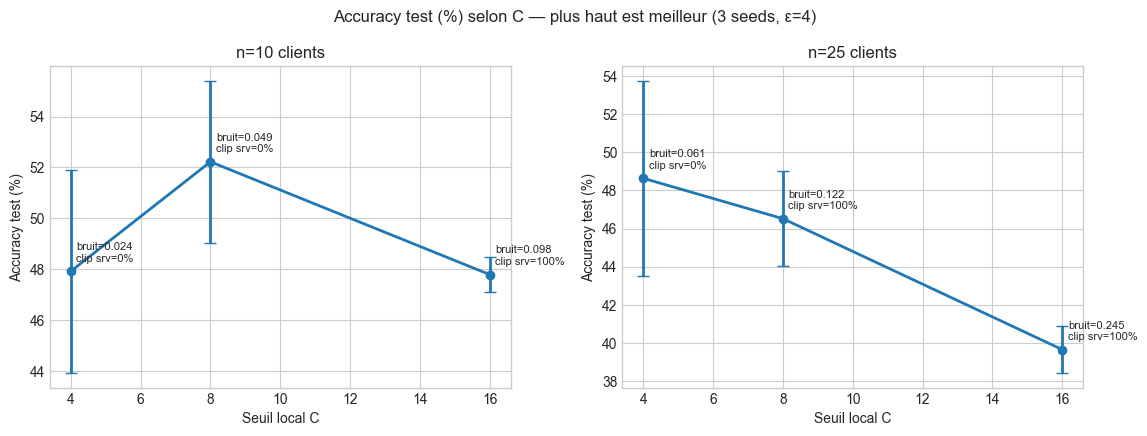

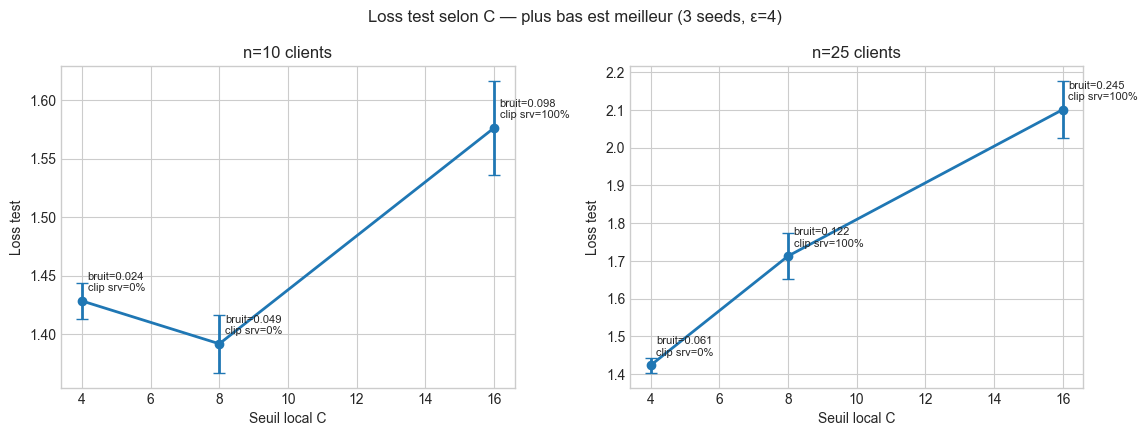

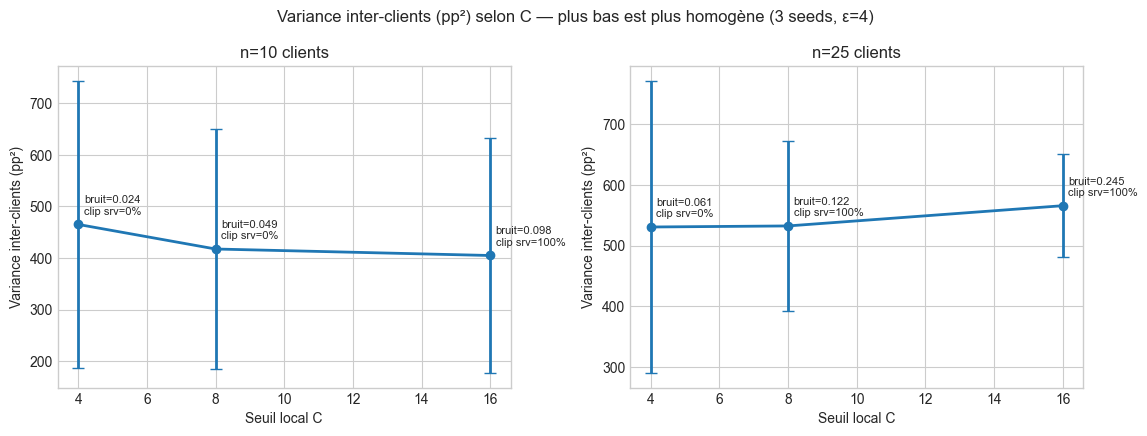

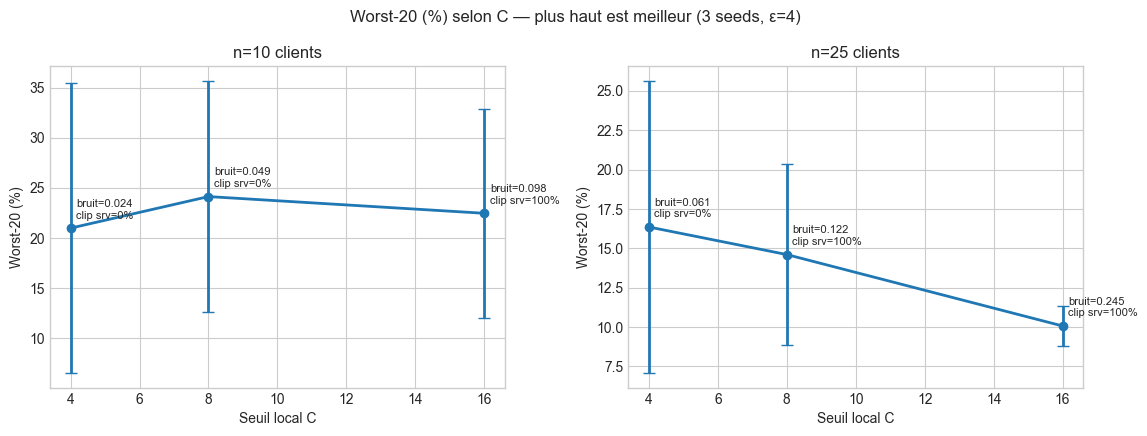

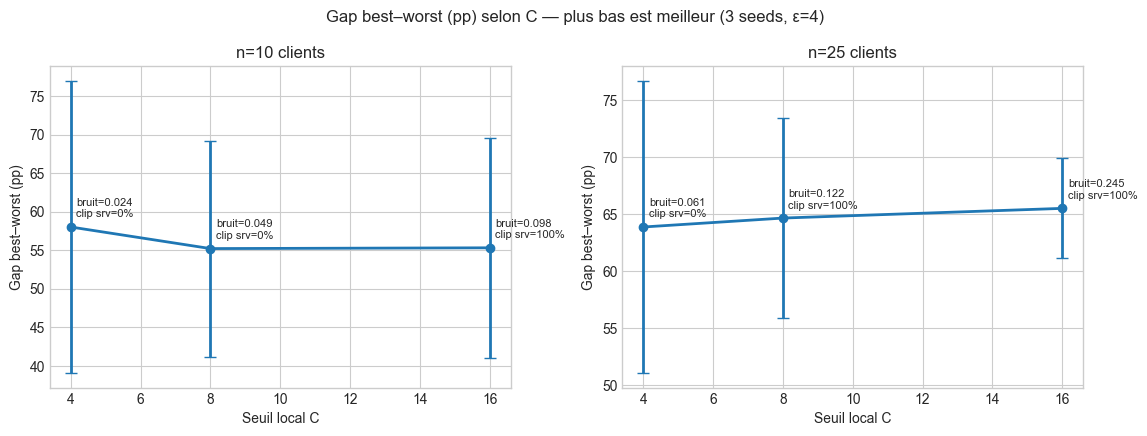

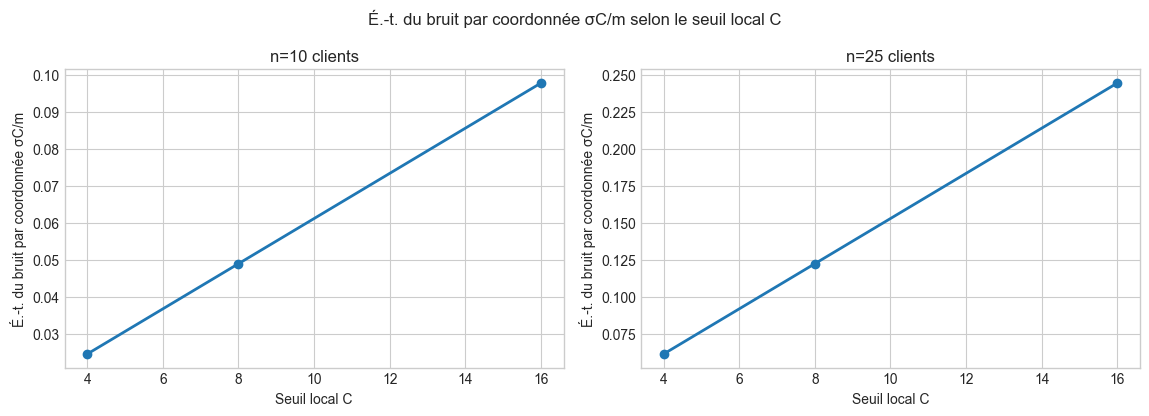

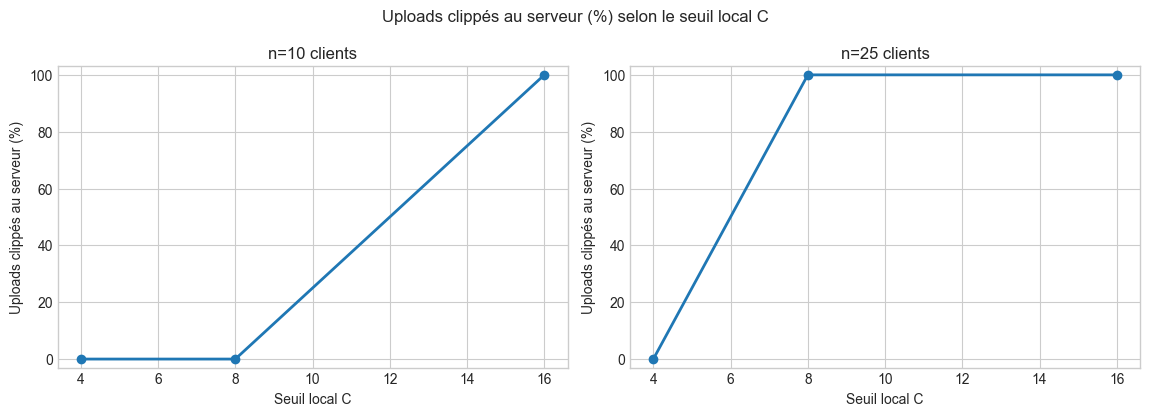

**Interprétation causale.** À $\varepsilon=4$, le multiplicateur $\sigma$ reste fixé mais $\sigma C/m$ augmente avec $C$. Une mauvaise métrique à grand $C$ peut donc venir du bruit absolu plus fort, de l'activation du clipping serveur, ou de leur interaction. Cette campagne compare les mécanismes complets associés à chaque $C$ ; elle n'identifie pas l'effet pur du clipping local. Une ablation causale demanderait des streams aléatoires séparés et un facteur maintenu fixe.

In [29]:
if len(privacy_table):
    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    for n_clients, group in privacy_table.groupby("Clients"):
        group = group.sort_values("ε cible")
        ax.plot(
            group["ε cible"], group["Uploads clippés (%)"], marker="o",
            label=f"n={int(n_clients)}",
        )
    ax.set(
        xlabel="ε cible", ylabel="Uploads clippés au serveur (%)", ylim=(-3, 103),
        title="Clipping serveur dans l'écran privacy D",
    )
    ax.legend()
    fig.tight_layout(); plt.show()

f_clip = final_df[
    (final_df.campaign == READABLE_CAMPAIGN)
    & (final_df.phase == READABLE_PHASE)
    & final_df.dp_enabled
    & (final_df.reference == "F_CC")
    & (final_df.attack == "none")
]
f_server = 100.0 * f_clip.server_clip_rate.dropna()
f_note = (
    f"Dans F-confirmation, le taux serveur observé vaut "
    f"{f_server.min():.1f}–{f_server.max():.1f} %. " if len(f_server) else
    "Dans F-confirmation, le taux serveur n'est pas publié. "
)
display(Markdown(
    "**Note F-confirmation.** " + f_note
    + "Le taux local sous DP reste non publié. Une courbe plate à zéro ne "
    "démontrerait pas l'utilité du clipping serveur ; elle indique seulement "
    "que ce seuil n'est pas actif dans cette cellule."
))

if len(privacy_table):
    deviation = (privacy_table["ε réalisé"] - privacy_table["ε cible"]).abs().max()
    server_values = privacy_table["Uploads clippés (%)"].dropna()
    clip_sentence = (
        f"Dans l'écran D, le clipping serveur varie de {server_values.min():.1f} % à "
        f"{server_values.max():.1f} %." if len(server_values) else
        "Le clipping serveur n'est pas publié dans l'écran D."
    )
    display(Markdown(
        f"**Lecture automatique.** L'écart maximal $|\\varepsilon_{{réalisé}}-"
        f"\\varepsilon_{{cible}}|$ vaut **{deviation:.4g}**. {clip_sentence} "
        "Un taux de 100 % indique que tous les uploads dépassent le seuil serveur ; "
        "cela signale un calibrage géométrique très contraignant, pas un gain d'utilité."
    ))

display(Markdown("## 6.2 Impact conjoint du seuil local C et du bruit absolu"))
b3_clip = final_df[
    (final_df.campaign == READABLE_CAMPAIGN)
    & (final_df.phase == "b3_local_clip_dp_confirmation")
    & (final_df.reference == "F_CC")
    & np.isclose(final_df.alpha, 0.0)
    & (final_df.attack == "none")
].copy()
b3_clip[["batch_size", "C_config", "U_config"]] = b3_clip.metrics_path.apply(
    _privacy_config_fields
)
b3_clip["coord_noise_std"] = (
    b3_clip.sigma_mean * b3_clip.C_config / b3_clip.batch_size
)
b3_summary = (
    b3_clip.groupby(["n_clients", "C_config"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        noise_std=("coord_noise_std", "mean"),
        server_clip_mean=("server_clip_rate", "mean"),
        accuracy_mean=("test_accuracy_pct", "mean"),
        accuracy_sd=("test_accuracy_pct", "std"),
        loss_mean=("test_loss", "mean"),
        loss_sd=("test_loss", "std"),
        variance_mean=("variance_pp2", "mean"),
        variance_sd=("variance_pp2", "std"),
        worst20_mean=("worst20_pct", "mean"),
        worst20_sd=("worst20_pct", "std"),
        gap_mean=("gap_pp", "mean"),
        gap_sd=("gap_pp", "std"),
    )
    .reset_index()
)
b3_summary["server_clip_pct"] = 100.0 * b3_summary.server_clip_mean
display(Markdown(
    r"**B3-confirmation :** trois seeds, $\varepsilon=4$, FCC, $\alpha=0$, "
    "sans attaque. Le taux de clipping local dépendant des données n'est pas "
    r"publié. Le taux serveur et $\sigma C/m$ permettent néanmoins de voir "
    "quand la géométrie du mécanisme change."
))
display(b3_summary.rename(columns={
    "n_clients": "Clients", "C_config": "C local",
    "noise_std": "É.-t. bruit/coord.",
    "server_clip_pct": "Uploads serveur clippés (%)",
    "accuracy_mean": "Accuracy moyenne", "loss_mean": "Loss moyenne",
    "variance_mean": "Variance moyenne",
    "worst20_mean": "Worst-20 moyen", "gap_mean": "Gap moyen",
})[[
    "Clients", "C local", "Seeds", "É.-t. bruit/coord.",
    "Uploads serveur clippés (%)", "Accuracy moyenne", "Loss moyenne",
    "Variance moyenne", "Worst-20 moyen", "Gap moyen",
]].round(3))


def _plot_clipping_outcome(mean_col, sd_col, ylabel, better):
    if b3_summary.empty or not b3_summary[mean_col].notna().any():
        display(Markdown(f"**{ylabel} : données indisponibles dans B3.**"))
        return
    client_values = sorted(b3_summary.n_clients.unique())
    fig, axes = plt.subplots(
        1, len(client_values), figsize=(5.8 * len(client_values), 4.4),
        squeeze=False,
    )
    for ax, n_clients in zip(axes.ravel(), client_values):
        group = b3_summary[b3_summary.n_clients == n_clients].sort_values("C_config")
        ax.errorbar(
            group.C_config, group[mean_col], yerr=group[sd_col], marker="o",
            linewidth=2, capsize=4,
        )
        for _, row in group.iterrows():
            ax.annotate(
                f"bruit={row.noise_std:.3f}\nclip srv={row.server_clip_pct:.0f}%",
                (row.C_config, row[mean_col]), xytext=(4, 7),
                textcoords="offset points", fontsize=8,
            )
        ax.set(xlabel="Seuil local C", ylabel=ylabel, title=f"n={int(n_clients)} clients")
    fig.suptitle(f"{ylabel} selon C — {better} (3 seeds, ε=4)")
    fig.tight_layout(); plt.show()


_plot_clipping_outcome("accuracy_mean", "accuracy_sd", "Accuracy test (%)", "plus haut est meilleur")
_plot_clipping_outcome("loss_mean", "loss_sd", "Loss test", "plus bas est meilleur")
_plot_clipping_outcome("variance_mean", "variance_sd", "Variance inter-clients (pp²)", "plus bas est plus homogène")
_plot_clipping_outcome("worst20_mean", "worst20_sd", "Worst-20 (%)", "plus haut est meilleur")
_plot_clipping_outcome("gap_mean", "gap_sd", "Gap best–worst (pp)", "plus bas est meilleur")

for metric, ylabel in [("noise_std", "É.-t. du bruit par coordonnée σC/m"),
                         ("server_clip_pct", "Uploads clippés au serveur (%)")]:
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2), squeeze=False)
    for ax, n_clients in zip(axes.ravel(), sorted(b3_summary.n_clients.unique())):
        group = b3_summary[b3_summary.n_clients == n_clients].sort_values("C_config")
        ax.plot(group.C_config, group[metric], marker="o", linewidth=2)
        ax.set(xlabel="Seuil local C", ylabel=ylabel, title=f"n={int(n_clients)} clients")
        if metric == "server_clip_pct":
            ax.set_ylim(-3, 103)
    fig.suptitle(ylabel + " selon le seuil local C")
    fig.tight_layout(); plt.show()

display(Markdown(
    r"**Interprétation causale.** À $\varepsilon=4$, le multiplicateur "
    r"$\sigma$ reste fixé mais $\sigma C/m$ augmente avec $C$. Une mauvaise "
    "métrique à grand $C$ peut donc venir du bruit absolu plus fort, de "
    "l'activation du clipping serveur, ou de leur interaction. Cette campagne "
    "compare les mécanismes complets associés à chaque $C$ ; elle n'identifie "
    "pas l'effet pur du clipping local. Une ablation causale demanderait des "
    "streams aléatoires séparés et un facteur maintenu fixe."
))

## 7. Attaques byzantines et références robustes

La comparaison principale utilise uniquement la confirmation F : DP avec
$\varepsilon=4$, $\alpha=2$, trois seeds, 20 % de clients byzantins dans les
bras attaqués. Les références CM, FCC, RFA et trMean sont évaluées sur les
mêmes cellules expérimentales.

Sens de lecture :

- **accuracy test** et **Worst-20 honnête** : plus grand est meilleur ;
- **gap honnête**, **erreur de référence oracle** et **masse byzantine oracle** :
  plus petit est meilleur ;
- les métriques `honest_*` retirent les identifiants byzantins de l'évaluation
  de fairness ;
- les métriques oracle servent à expliquer le simulateur et ne sont pas
  disponibles au serveur en situation réelle.

In [30]:
attack_focus = final_df[
    (final_df.campaign == READABLE_CAMPAIGN)
    & (final_df.phase == READABLE_PHASE)
    & final_df.dp_enabled
    & np.isclose(final_df.target_epsilon, 4.0)
    & np.isclose(final_df.alpha, 2.0)
].copy()

attack_summary_readable = (
    attack_focus.groupby(["n_clients", "attack", "reference"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        accuracy=("test_accuracy_pct", "mean"),
        accuracy_sd=("test_accuracy_pct", "std"),
        worst20=("honest_worst20_pct", "mean"),
        gap=("honest_gap_pp", "mean"),
        reference_error=("reference_error_oracle", "mean"),
        byzantine_mass=("byzantine_mass_oracle", "mean"),
        byzantine_displacement=("byzantine_displacement_norm_oracle", "mean"),
        aggregate_error=("aggregate_error_oracle", "mean"),
    )
    .reset_index()
)

for n_clients in sorted(attack_summary_readable.n_clients.unique()):
    table = attack_summary_readable[attack_summary_readable.n_clients == n_clients].copy()
    table = table.rename(columns={
        "attack": "Attaque", "reference": "Référence",
        "accuracy": "Accuracy test (%)", "accuracy_sd": "Écart-type accuracy",
        "worst20": "Worst-20 honnête (%)", "gap": "Gap honnête (pp)",
        "reference_error": "Erreur référence (oracle)",
        "byzantine_mass": "Masse byzantine (oracle)",
        "byzantine_displacement": "Déplacement byzantin (oracle)",
        "aggregate_error": "Erreur agrégat (oracle)",
    })
    display(Markdown(f"### Utilité et fairness — n={int(n_clients)} clients"))
    display(table[[
        "Attaque", "Référence", "Seeds", "Accuracy test (%)", "Écart-type accuracy",
        "Worst-20 honnête (%)", "Gap honnête (pp)",
    ]].round(3))
    display(Markdown(f"### Diagnostics oracle de robustesse — n={int(n_clients)} clients"))
    display(table[[
        "Attaque", "Référence", "Seeds", "Erreur référence (oracle)",
        "Masse byzantine (oracle)", "Déplacement byzantin (oracle)",
        "Erreur agrégat (oracle)",
    ]].round(4))

### Utilité et fairness — n=10 clients

,Attaque,Référence,Seeds,Accuracy test (%),Écart-type accuracy,Worst-20 honnête (%),Gap honnête (pp)
0,alie,CM,3,47.473,3.671,25.967,47.167
1,alie,F_CC,3,47.580,3.287,26.400,46.517
2,alie,RFA,3,47.580,3.340,26.267,46.717
3,alie,trMean,3,47.550,3.791,25.883,47.367
4,bf,CM,3,17.677,13.245,1.083,51.583
5,bf,F_CC,3,18.950,14.606,2.917,48.833
6,bf,RFA,3,18.237,14.241,2.117,50.100
7,bf,trMean,3,17.877,13.600,1.383,51.217
8,ipm,CM,3,48.143,2.954,27.817,45.267
9,ipm,F_CC,3,47.987,2.665,26.933,46.100


### Diagnostics oracle de robustesse — n=10 clients

,Attaque,Référence,Seeds,Erreur référence (oracle),Masse byzantine (oracle),Déplacement byzantin (oracle),Erreur agrégat (oracle)
0,alie,CM,3,0.9537,0.0000,0.0000,4.4498
1,alie,F_CC,3,1.2511,0.0000,0.0000,4.4506
2,alie,RFA,3,0.0000,0.0000,0.0000,4.4391
3,alie,trMean,3,1.2591,0.0000,0.0000,4.4574
4,bf,CM,3,3.2501,0.8097,11.2709,11.4590
5,bf,F_CC,3,3.0414,0.6734,8.9808,9.2419
6,bf,RFA,3,2.2154,0.7807,10.7907,11.0117
7,bf,trMean,3,2.5989,0.8035,11.1925,11.3933
8,ipm,CM,3,3.5566,0.0000,0.0000,4.4393
9,ipm,F_CC,3,2.9541,0.0000,0.0000,4.4379


### Utilité et fairness — n=25 clients

,Attaque,Référence,Seeds,Accuracy test (%),Écart-type accuracy,Worst-20 honnête (%),Gap honnête (pp)
20,alie,CM,3,43.140,2.993,9.812,69.396
21,alie,F_CC,3,43.087,2.996,9.771,69.292
22,alie,RFA,3,43.127,3.014,9.750,69.417
23,alie,trMean,3,43.100,2.992,9.812,69.354
24,bf,CM,3,38.803,2.253,7.479,71.625
25,bf,F_CC,3,38.737,2.189,7.125,71.896
26,bf,RFA,3,38.650,2.180,7.167,72.104
27,bf,trMean,3,38.850,2.257,7.500,71.604
28,ipm,CM,3,43.127,3.015,9.750,69.396
29,ipm,F_CC,3,43.117,2.993,9.708,69.396


### Diagnostics oracle de robustesse — n=25 clients

,Attaque,Référence,Seeds,Erreur référence (oracle),Masse byzantine (oracle),Déplacement byzantin (oracle),Erreur agrégat (oracle)
20,alie,CM,3,3.4139,0.0000,0.0000,3.4493
21,alie,F_CC,3,1.9629,0.0000,0.0000,3.4483
22,alie,RFA,3,3.7698,0.0000,0.0000,3.4475
23,alie,trMean,3,1.6101,0.0000,0.0000,3.4499
24,bf,CM,3,2.7401,0.2022,1.4246,3.0975
25,bf,F_CC,3,2.1452,0.1998,1.4077,3.0941
26,bf,RFA,3,1.5472,0.2020,1.4252,3.0968
27,bf,trMean,3,1.9210,0.2021,1.4251,3.0963
28,ipm,CM,3,3.9349,0.0000,0.0000,3.4487
29,ipm,F_CC,3,2.6729,0.0000,0.0000,3.4472


In [31]:
# Deltas strictement appariés à FCC au niveau seed. Une valeur positive de
# Δ accuracy/Worst-20 favorise la référence; une valeur négative de Δ gap la favorise.
paired_keys = ["n_clients", "attack", "seed"]
paired_source = attack_focus[[
    *paired_keys, "reference", "test_accuracy_pct", "honest_worst20_pct", "honest_gap_pp",
]].copy()
paired_wide = paired_source.pivot_table(
    index=paired_keys, columns="reference",
    values=["test_accuracy_pct", "honest_worst20_pct", "honest_gap_pp"],
    aggfunc="first",
)
paired_rows = []
for reference in ["CM", "RFA", "trMean"]:
    required = [(metric, label) for metric, label in [
        ("test_accuracy_pct", "Δ accuracy (pp)"),
        ("honest_worst20_pct", "Δ Worst-20 (pp)"),
        ("honest_gap_pp", "Δ gap (pp)"),
    ] if (metric, reference) in paired_wide and (metric, "F_CC") in paired_wide]
    if not required:
        continue
    for keys, row in paired_wide.iterrows():
        output = {"Clients": int(keys[0]), "Attaque": keys[1], "Seed": int(keys[2]), "Référence": reference}
        for metric, label in required:
            output[label] = row[(metric, reference)] - row[(metric, "F_CC")]
        paired_rows.append(output)
paired_delta_runs = pd.DataFrame(paired_rows)
if len(paired_delta_runs):
    paired_delta_summary = (
        paired_delta_runs.groupby(["Clients", "Attaque", "Référence"], dropna=False)
        .agg(
            Seeds=("Seed", "nunique"),
            delta_accuracy=("Δ accuracy (pp)", "mean"),
            delta_worst20=("Δ Worst-20 (pp)", "mean"),
            delta_gap=("Δ gap (pp)", "mean"),
        )
        .reset_index()
        .rename(columns={
            "delta_accuracy": "Δ accuracy vs FCC (pp)",
            "delta_worst20": "Δ Worst-20 vs FCC (pp)",
            "delta_gap": "Δ gap vs FCC (pp)",
        })
    )
    display(Markdown(
        "### Différences appariées à FCC\n\n"
        "Chaque différence est d'abord calculée pour la même seed, puis moyennée. "
        "Ainsi, une différence de seed ou de partition ne peut pas expliquer le signe."
    ))
    for n_clients in sorted(paired_delta_summary.Clients.unique()):
        display(Markdown(f"**n={int(n_clients)} clients**"))
        display(paired_delta_summary[paired_delta_summary.Clients == n_clients].drop(columns="Clients").round(3))

### Différences appariées à FCC

Chaque différence est d'abord calculée pour la même seed, puis moyennée. Ainsi, une différence de seed ou de partition ne peut pas expliquer le signe.

**n=10 clients**

,Attaque,Référence,Seeds,Δ accuracy vs FCC (pp),Δ Worst-20 vs FCC (pp),Δ gap vs FCC (pp)
0,alie,CM,3,-0.107,-0.433,0.650
1,alie,RFA,3,0.000,-0.133,0.200
2,alie,trMean,3,-0.030,-0.517,0.850
3,bf,CM,3,-1.273,-1.833,2.750
4,bf,RFA,3,-0.713,-0.800,1.267
5,bf,trMean,3,-1.073,-1.533,2.383
6,ipm,CM,3,0.157,0.883,-0.833
7,ipm,RFA,3,0.013,0.067,-0.117
8,ipm,trMean,3,-0.087,-0.050,0.250
9,minmax,CM,3,-0.553,-0.933,0.917


**n=25 clients**

,Attaque,Référence,Seeds,Δ accuracy vs FCC (pp),Δ Worst-20 vs FCC (pp),Δ gap vs FCC (pp)
15,alie,CM,3,0.053,0.042,0.104
16,alie,RFA,3,0.040,-0.021,0.125
17,alie,trMean,3,0.013,0.042,0.062
18,bf,CM,3,0.067,0.354,-0.271
19,bf,RFA,3,-0.087,0.042,0.208
20,bf,trMean,3,0.113,0.375,-0.292
21,ipm,CM,3,0.010,0.042,0.000
22,ipm,RFA,3,-0.017,-0.062,0.062
23,ipm,trMean,3,-0.017,0.062,-0.062
24,minmax,CM,3,0.020,0.062,0.021


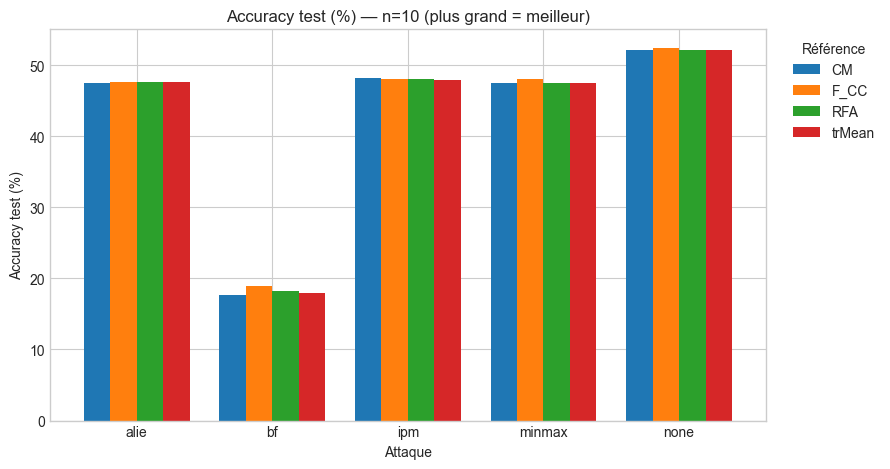

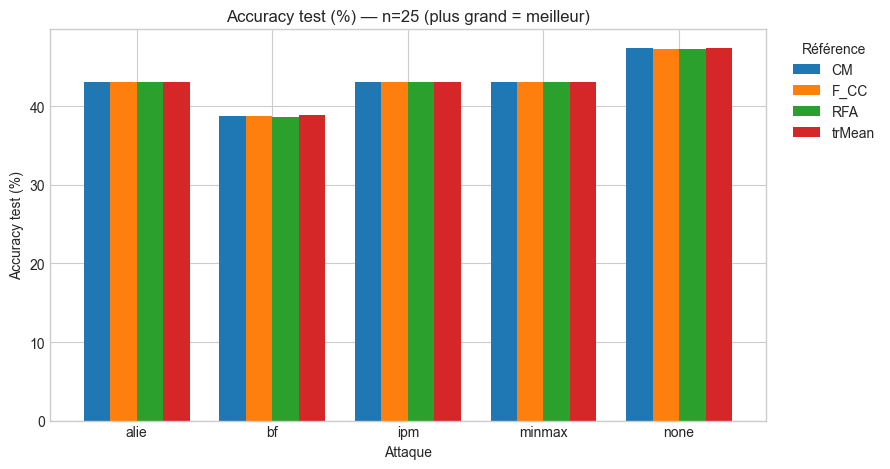

In [32]:
def _plot_attack_reference(metric, ylabel, higher_is_better):
    if attack_summary_readable.empty or not attack_summary_readable[metric].notna().any():
        display(Markdown(f"**{ylabel} : données indisponibles.**"))
        return
    for n_clients in sorted(attack_summary_readable.n_clients.unique()):
        view = attack_summary_readable[attack_summary_readable.n_clients == n_clients]
        pivot = view.pivot(index="attack", columns="reference", values=metric)
        ax = pivot.plot(kind="bar", figsize=(9, 4.8), width=0.78)
        direction = "plus grand = meilleur" if higher_is_better else "plus petit = meilleur"
        ax.set(
            xlabel="Attaque", ylabel=ylabel,
            title=f"{ylabel} — n={int(n_clients)} ({direction})",
        )
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Référence", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig = ax.get_figure(); fig.tight_layout(); plt.show()


_plot_attack_reference("accuracy", "Accuracy test (%)", True)

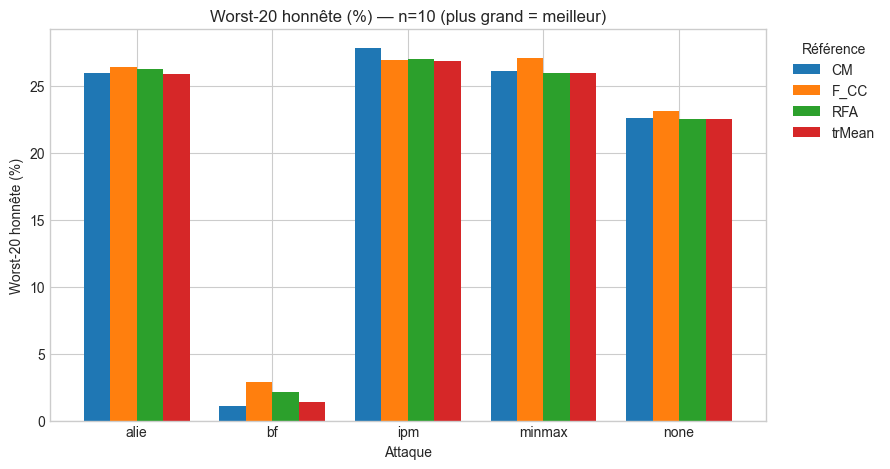

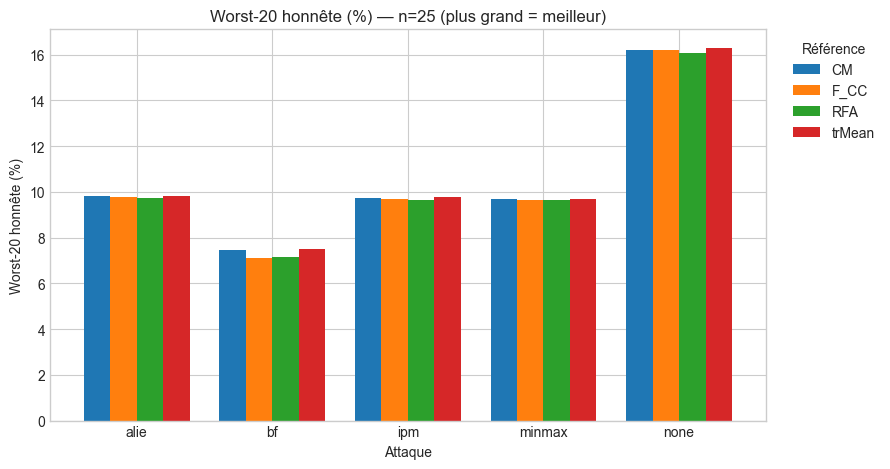

In [33]:
_plot_attack_reference("worst20", "Worst-20 honnête (%)", True)

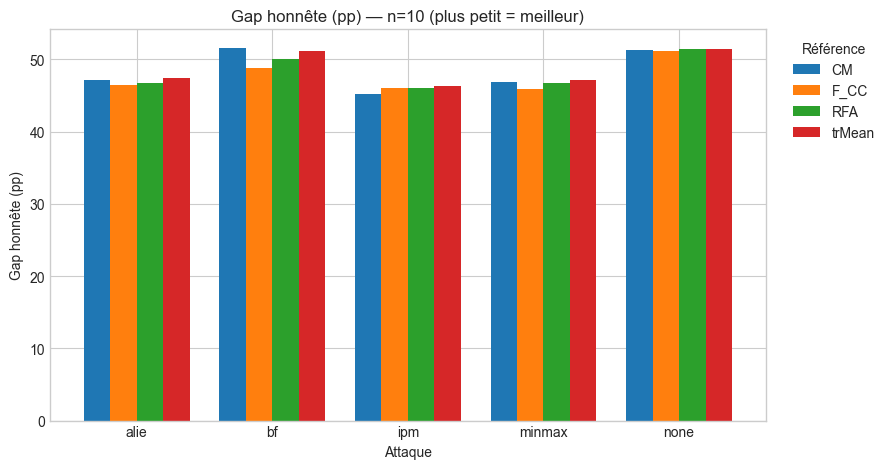

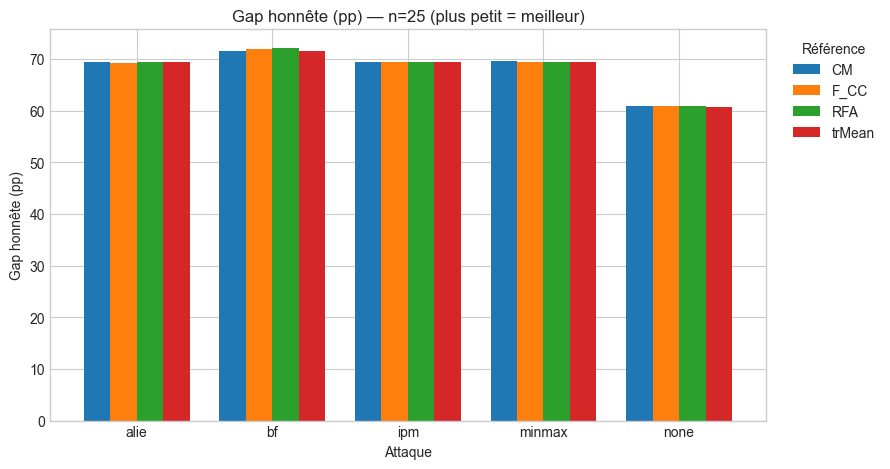

In [34]:
_plot_attack_reference("gap", "Gap honnête (pp)", False)

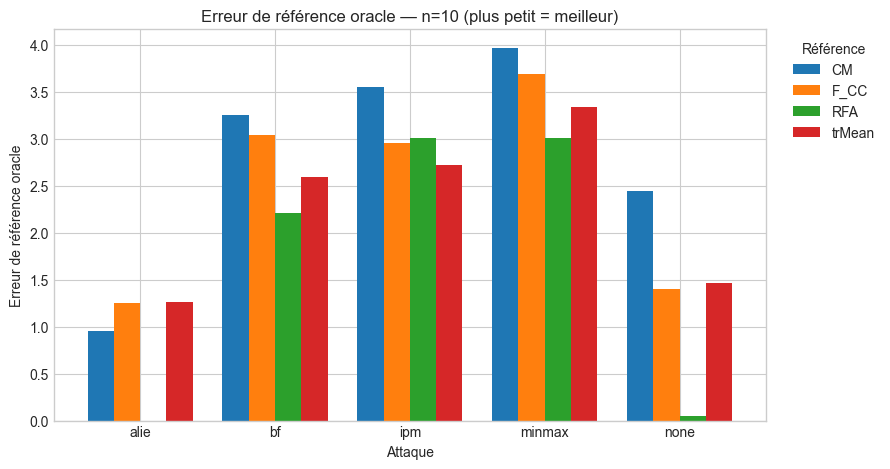

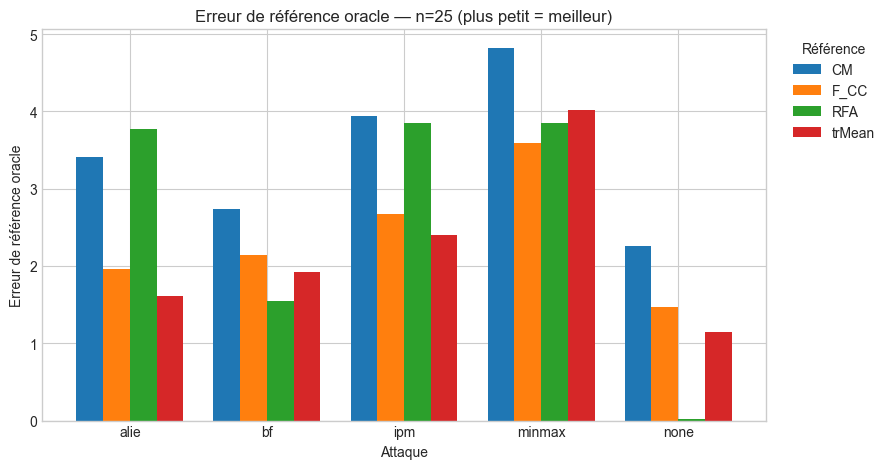

In [35]:
_plot_attack_reference("reference_error", "Erreur de référence oracle", False)

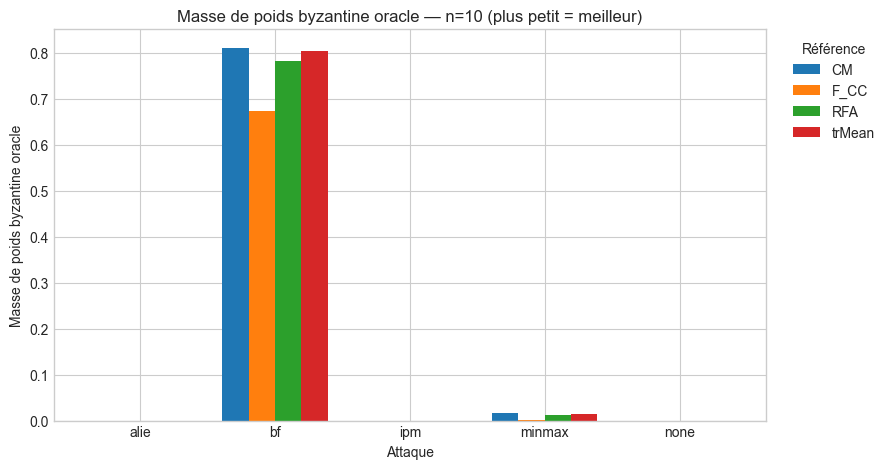

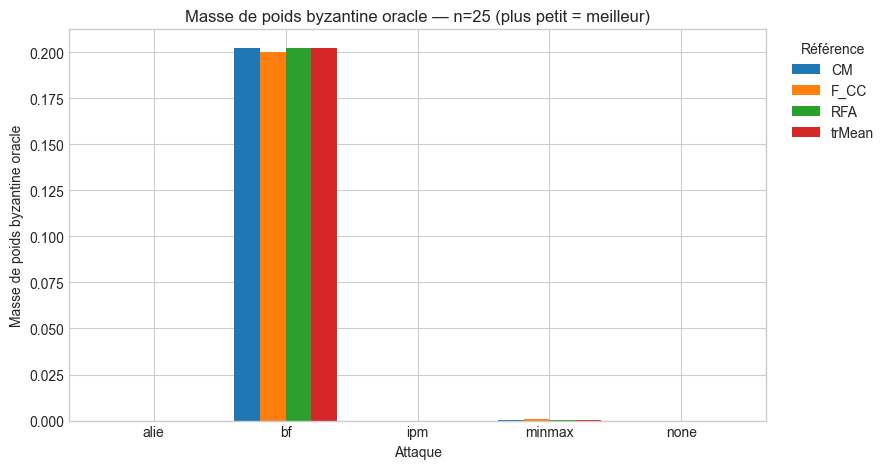

**Lecture automatique, critère par critère.** Des gagnants différents montrent qu'une petite erreur de centre ne garantit pas automatiquement la meilleure accuracy ou fairness end-to-end.

,Clients,Attaque,Meilleure accuracy,Meilleur Worst-20,Plus petite erreur de référence
0,10,alie,F_CC,F_CC,RFA
1,10,bf,F_CC,F_CC,RFA
2,10,ipm,CM,CM,trMean
3,10,minmax,F_CC,F_CC,RFA
4,25,alie,CM,CM,trMean
5,25,bf,trMean,trMean,RFA
6,25,ipm,CM,trMean,trMean
7,25,minmax,CM,CM,F_CC


In [36]:
_plot_attack_reference("byzantine_mass", "Masse de poids byzantine oracle", False)

if len(attack_summary_readable):
    attacked_only = attack_summary_readable[attack_summary_readable.attack != "none"]
    winners = []
    for (n_clients, attack), group in attacked_only.groupby(["n_clients", "attack"]):
        winners.append({
            "Clients": int(n_clients),
            "Attaque": attack,
            "Meilleure accuracy": group.loc[group.accuracy.idxmax(), "reference"],
            "Meilleur Worst-20": group.loc[group.worst20.idxmax(), "reference"],
            "Plus petite erreur de référence": group.loc[group.reference_error.idxmin(), "reference"],
        })
    display(Markdown(
        "**Lecture automatique, critère par critère.** Des gagnants différents "
        "montrent qu'une petite erreur de centre ne garantit pas automatiquement "
        "la meilleure accuracy ou fairness end-to-end."
    ))
    display(pd.DataFrame(winners))

## 8. Diagnostics oracle : signal propre, bruit DP et déplacement byzantin

Ces diagnostics ne sont connus que dans le simulateur :

| Diagnostic | Définition opérationnelle | Lecture |
|---|---|---|
| corrélation poids–bruit | corrélation entre poids FAR et amplitude de bruit effectif par client | proche de 0 : pas d'alignement linéaire ; positive : les clients plus bruités tendent à être plus pondérés |
| corrélation score bruité–score propre | fidélité du classement géométrique après ajout du bruit | proche de 1 : le score bruité conserve mieux la géométrie propre |
| rappel de la queue honnête | part des honest outliers propres retrouvés par le score bruité | plus grand est meilleur pour l'objectif FAR d'inclusion |
| biais de tilting honnête | déplacement dû à la repondération des seuls messages honnêtes propres | coût géométrique de fairness |
| bruit DP à poids fixes | contribution du bruit lorsque les poids sont figés | bruit incompressible à pondération donnée |
| déplacement byzantin | contribution vectorielle des messages byzantins | effet direct de l'attaque |
| erreur totale | distance de l'agrégat au centre honnête propre | résultat combiné, donc non égal en général à la somme des normes précédentes |

Pour garder les figures lisibles, cette section fixe FCC, DP
$\varepsilon=4$, $\alpha=2$ et la confirmation F. Chaque graphique varie
seulement l'attaque et le nombre de clients.

In [37]:
# D2-confirmation isole le problème score/bruit sous bruit hétéroscédastique,
# sans attaque. Les quantités sont des médianes sur les tours de chaque run,
# ensuite moyennées entre les trois seeds.
d2_oracle = positioning_run_level[
    (positioning_run_level.phase == "d2_noise_assignment_confirmation")
    & (positioning_run_level.robust_reference == "centered_clipping")
    & (positioning_run_level.attack == "none")
].copy()
d2_oracle["niveau_bruit"] = np.where(
    d2_oracle.variant_id.str.contains("strong", na=False), "fort", "modéré"
)
d2_oracle["assignation"] = np.where(
    d2_oracle.variant_id.str.contains("reverse", na=False), "inversée", "directe"
)
d2_oracle["condition_bruit"] = d2_oracle.niveau_bruit + " · " + d2_oracle.assignation

d2_oracle_summary = (
    d2_oracle.groupby(["num_clients", "condition_bruit"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        corr_weight_noise=("weight_dp_noise_corr_median_oracle", "mean"),
        corr_distance_noise=("distance_dp_noise_corr_median_oracle", "mean"),
        corr_score_clean=("honest_noisy_clean_score_corr_median_oracle", "mean"),
        top_tail_recall=("honest_clean_top_tail_recall_median_oracle", "mean"),
    )
    .reset_index()
)
d2_table = d2_oracle_summary.rename(columns={
    "num_clients": "Clients", "condition_bruit": "Bruit / assignation",
    "corr_weight_noise": "Corr. poids–bruit DP",
    "corr_distance_noise": "Corr. distance–bruit DP",
    "corr_score_clean": "Corr. score bruité–propre",
    "top_tail_recall": "Rappel honest outliers",
})
d2_table["Rappel honest outliers"] *= 100.0
display(Markdown("### D2-confirmation — fidélité du score sous bruit hétéroscédastique"))
display(d2_table.round(3))

### D2-confirmation — fidélité du score sous bruit hétéroscédastique

,Clients,Bruit / assignation,Seeds,Corr. poids–bruit DP,Corr. distance–bruit DP,Corr. score bruité–propre,Rappel honest outliers
0,10,fort · directe,3,0.999,0.999,-0.265,16.667
1,10,fort · inversée,3,0.999,0.998,0.090,16.667
2,10,modéré · directe,3,0.998,0.998,-0.344,0.000
3,10,modéré · inversée,3,0.998,0.997,0.041,16.667
4,25,fort · directe,3,0.998,0.991,0.150,33.333
5,25,fort · inversée,3,0.998,0.992,-0.005,20.000
6,25,modéré · directe,3,0.997,0.991,0.150,26.667
7,25,modéré · inversée,3,0.997,0.991,0.004,20.000


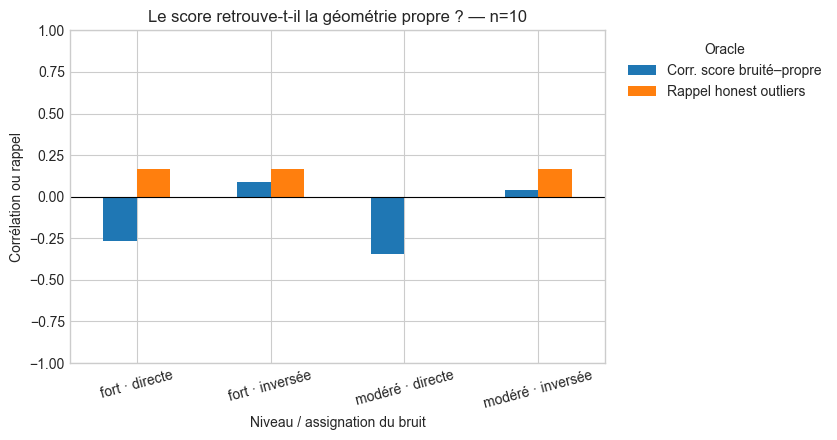

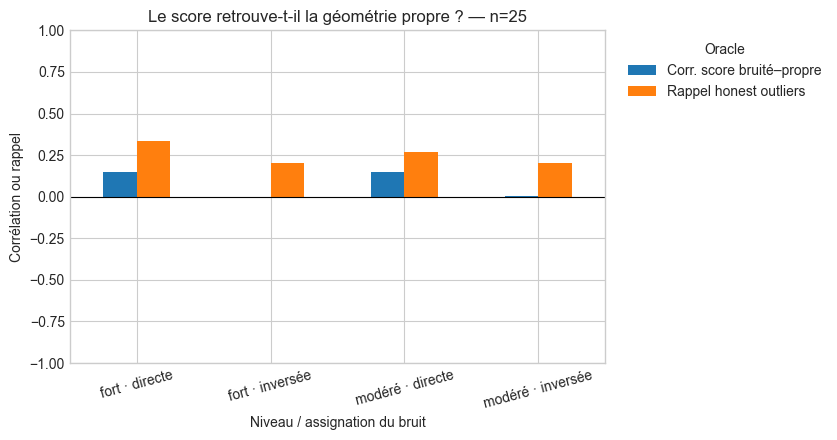

In [38]:
if len(d2_oracle_summary):
    for n_clients in sorted(d2_oracle_summary.num_clients.unique()):
        view = d2_oracle_summary[d2_oracle_summary.num_clients == n_clients].set_index("condition_bruit")
        ax = view[["corr_score_clean", "top_tail_recall"]].rename(columns={
            "corr_score_clean": "Corr. score bruité–propre",
            "top_tail_recall": "Rappel honest outliers",
        }).plot(kind="bar", figsize=(8.5, 4.5))
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set(
            xlabel="Niveau / assignation du bruit", ylabel="Corrélation ou rappel",
            ylim=(-1, 1), title=f"Le score retrouve-t-il la géométrie propre ? — n={int(n_clients)}",
        )
        ax.tick_params(axis="x", rotation=15)
        ax.legend(title="Oracle", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig = ax.get_figure(); fig.tight_layout(); plt.show()

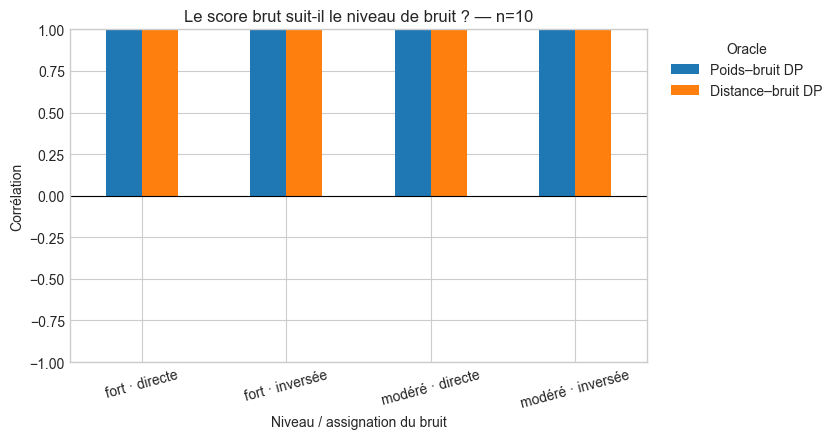

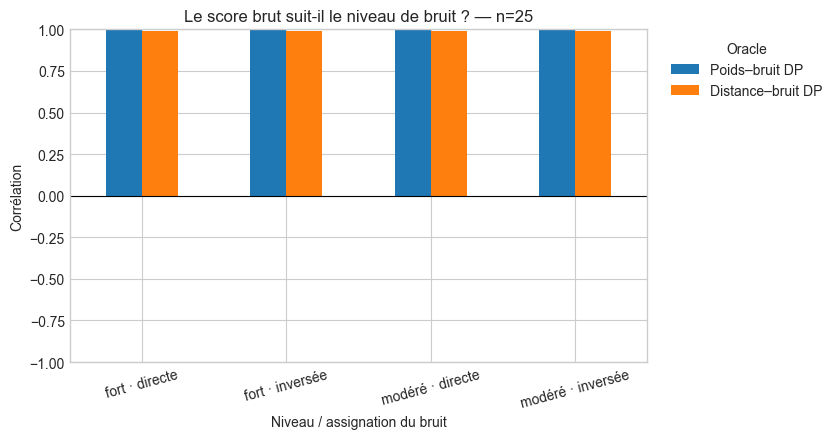

**Lecture automatique D2.** La corrélation poids–bruit médiane vaut **0.998**, tandis que la corrélation score bruité–propre médiane vaut **0.022** et le rappel médian **18.3 %**. Cela quantifie séparément l'alignement au bruit et la conservation du signal propre ; ce n'est pas une preuve causale hors du simulateur.

In [39]:
if len(d2_oracle_summary):
    for n_clients in sorted(d2_oracle_summary.num_clients.unique()):
        view = d2_oracle_summary[d2_oracle_summary.num_clients == n_clients].set_index("condition_bruit")
        ax = view[["corr_weight_noise", "corr_distance_noise"]].rename(columns={
            "corr_weight_noise": "Poids–bruit DP",
            "corr_distance_noise": "Distance–bruit DP",
        }).plot(kind="bar", figsize=(8.5, 4.5))
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set(
            xlabel="Niveau / assignation du bruit", ylabel="Corrélation",
            ylim=(-1, 1), title=f"Le score brut suit-il le niveau de bruit ? — n={int(n_clients)}",
        )
        ax.tick_params(axis="x", rotation=15)
        ax.legend(title="Oracle", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig = ax.get_figure(); fig.tight_layout(); plt.show()

    median_weight_noise = d2_oracle_summary.corr_weight_noise.median()
    median_score_clean = d2_oracle_summary.corr_score_clean.median()
    median_recall = d2_oracle_summary.top_tail_recall.median()
    display(Markdown(
        f"**Lecture automatique D2.** La corrélation poids–bruit médiane vaut "
        f"**{median_weight_noise:.3f}**, tandis que la corrélation score bruité–propre "
        f"médiane vaut **{median_score_clean:.3f}** et le rappel médian "
        f"**{100*median_recall:.1f} %**. Cela quantifie séparément l'alignement au "
        "bruit et la conservation du signal propre ; ce n'est pas une preuve causale "
        "hors du simulateur."
    ))

In [40]:
# F/T20 fournit ensuite la décomposition sous attaques. Le terme de tilting
# est q_H ||B_tilt|| : la masse honnête q_H est nécessaire pour retrouver la
# contribution réellement présente dans l'identité vectorielle.
f_oracle = positioning_run_level[
    (positioning_run_level.phase == READABLE_PHASE)
    & positioning_run_level.dp_enabled.astype(str).str.lower().eq("true")
    & np.isclose(positioning_run_level.target_epsilon, 4.0)
    & np.isclose(positioning_run_level.far_alpha, 2.0)
    & (positioning_run_level.robust_reference == "centered_clipping")
].copy()
f_oracle["weighted_tilting"] = (
    f_oracle.honest_weight_mass_median_oracle
    * f_oracle.honest_clean_tilting_bias_norm_median_oracle
)
oracle_readable = (
    f_oracle.groupby(["num_clients", "attack"], dropna=False)
    .agg(
        Seeds=("seed", "nunique"),
        weighted_tilting=("weighted_tilting", "mean"),
        dp_noise=("honest_fixed_weight_dp_noise_norm_median_oracle", "mean"),
        byzantine_shift=("byzantine_displacement_norm_median_oracle", "mean"),
        aggregate_error=("aggregate_error_to_clean_honest_center_median_oracle", "mean"),
        residual=("error_decomposition_residual_norm_median_oracle", "max"),
    )
    .reset_index()
)
oracle_table = oracle_readable.rename(columns={
    "num_clients": "Clients", "attack": "Attaque",
    "weighted_tilting": "q_H × biais tilting",
    "dp_noise": "Bruit DP à poids fixes",
    "byzantine_shift": "Déplacement byzantin",
    "aggregate_error": "Erreur agrégat",
    "residual": "Résidu décomposition",
})
display(Markdown("### F-confirmation — décomposition des contributions"))
display(oracle_table.round(4))

### F-confirmation — décomposition des contributions

,Clients,Attaque,Seeds,q_H × biais tilting,Bruit DP à poids fixes,Déplacement byzantin,Erreur agrégat,Résidu décomposition
0,10,alie,3,0.1735,4.3921,0.0000,4.3958,0.0
1,10,bf,3,0.1386,3.0799,2.9920,4.4670,0.0
2,10,ipm,3,0.1587,4.3853,0.0000,4.3885,0.0
3,10,minmax,3,0.1546,4.3739,0.0155,4.3600,0.0
4,10,none,3,0.1588,3.9193,0.0000,3.9231,0.0
5,25,alie,3,0.0638,3.4370,0.0000,3.4375,0.0
6,25,bf,3,0.0533,2.7463,1.4246,3.0866,0.0
7,25,ipm,3,0.0624,3.4379,0.0000,3.4383,0.0
8,25,minmax,3,0.0609,3.4365,0.0065,3.4304,0.0
9,25,none,3,0.0623,3.0776,0.0000,3.0785,0.0


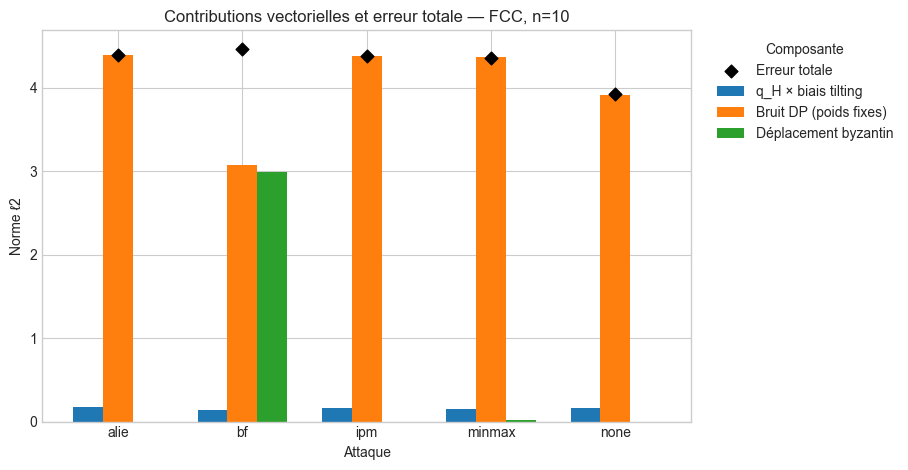

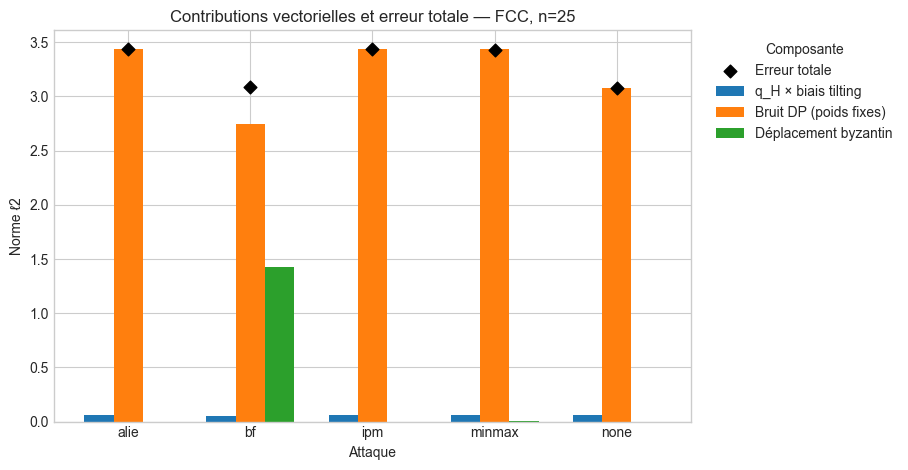

**Lecture automatique F.** La composante médiane la plus grande est **le bruit DP à poids fixes**. Le résidu maximal vaut **9.15e-16** : il contrôle l'identité numérique, mais n'est pas une métrique de qualité. Les barres ne sont pas empilées, car les vecteurs peuvent se compenser et leurs normes ne s'additionnent pas.

In [41]:
if len(oracle_readable):
    component_labels = {
        "weighted_tilting": "q_H × biais tilting",
        "dp_noise": "Bruit DP (poids fixes)",
        "byzantine_shift": "Déplacement byzantin",
    }
    for n_clients in sorted(oracle_readable.num_clients.unique()):
        view = oracle_readable[oracle_readable.num_clients == n_clients].set_index("attack")
        ax = view[list(component_labels)].rename(columns=component_labels).plot(
            kind="bar", figsize=(9.2, 4.8), width=0.72
        )
        x = np.arange(len(view))
        ax.scatter(
            x, view.aggregate_error, color="black", marker="D", s=42,
            label="Erreur totale", zorder=5,
        )
        ax.set(
            xlabel="Attaque", ylabel="Norme ℓ2",
            title=f"Contributions vectorielles et erreur totale — FCC, n={int(n_clients)}",
        )
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Composante", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig = ax.get_figure(); fig.tight_layout(); plt.show()

    max_residual = oracle_readable.residual.max()
    dominant = oracle_readable[["weighted_tilting", "dp_noise", "byzantine_shift"]].median().idxmax()
    dominant_label = {
        "weighted_tilting": "la contribution de tilting honnête",
        "dp_noise": "le bruit DP à poids fixes",
        "byzantine_shift": "le déplacement byzantin",
    }[dominant]
    display(Markdown(
        f"**Lecture automatique F.** La composante médiane la plus grande est "
        f"**{dominant_label}**. Le résidu maximal vaut **{max_residual:.2e}** : "
        "il contrôle l'identité numérique, mais n'est pas une métrique de qualité. "
        "Les barres ne sont pas empilées, car les vecteurs peuvent se compenser et "
        "leurs normes ne s'additionnent pas."
    ))
else:
    display(Markdown("**Décomposition oracle indisponible dans F-confirmation.**"))

## 8.1 Motivation initiale : partir des entraînements réels, avant d'évaluer RCIG

La question scientifique est : **comment préserver la fairness de FAR sous
local-DP, lorsque le bruit peut différer entre clients, tout en limitant
l'influence Byzantine ?**

Cette partie répond à **pourquoi avons-nous voulu construire un mécanisme
comme RCIG ?** Elle ne prend aucun résultat synthétique de RCIG comme argument
de motivation. Elle part de nos entraînements Fashion-MNIST, puis expose le
raisonnement qui conduit à chercher une information temporelle et un critère
de compatibilité avec le bruit attendu.

La progression est : **problème observé → diagnostic → limite des corrections
simples → hypothèse de construction**. Ces observations motivent une famille
de mécanismes ; elles ne déterminent pas à elles seules la formule de RCIG.

Les tableaux ci-dessous sont reconstruits depuis les artefacts réels. Les
tests synthétiques et le statut d'évaluation de RCIG sont placés à part,
en **section 11**, après la présentation des expériences de positionnement.

In [42]:
from pathlib import Path
import json

RCIG_EXPORT = EXPORT_ROOT / "rcig_motivation"
RCIG_EXPORT.mkdir(parents=True, exist_ok=True)

# Vrais gradients privés Fashion-MNIST, n=10, T=40, trois seeds appariées.
motivation_runs = final_df[
    (final_df["campaign"] == "fmnist_confirmatory_v1")
    & (final_df["n_clients"] == 10)
    & (final_df["horizon"] == 40)
    & (final_df["attack"] == "none")
    & (final_df["noise_profile"].isin(["homogeneous", "heteroscedastic"]))
    & (
        np.isclose(final_df["alpha"], 0.0)
        | (
            np.isclose(final_df["alpha"], 1.0)
            & final_df["reference"].isin(["F_CC", "F_NA-CC"])
        )
    )
].copy()

def rcig_arm(row):
    if np.isclose(row["alpha"], 0.0):
        return "Uniforme (alpha=0)"
    if row["reference"] == "F_CC":
        return "FAR + F_CC (alpha=1)"
    return "FAR + F_NA-CC (alpha=1)"

motivation_runs["arm"] = motivation_runs.apply(rcig_arm, axis=1)
motivation_runs["regime"] = motivation_runs["noise_profile"].map({
    "homogeneous": "Homogène",
    "heteroscedastic": "Hétéroscédastique",
})

protocol_errors = []
if len(motivation_runs) != 18:
    protocol_errors.append(f"18 runs attendus, {len(motivation_runs)} trouvés")
if set(motivation_runs["seed"].astype(int)) != {28, 36, 54}:
    protocol_errors.append("seeds attendues {28, 36, 54} absentes ou supplémentaires")
if set(motivation_runs["noise_profile"]) != {"homogeneous", "heteroscedastic"}:
    protocol_errors.append("les deux régimes de bruit attendus ne sont pas présents")
if set(motivation_runs["arm"]) != {
    "Uniforme (alpha=0)", "FAR + F_CC (alpha=1)", "FAR + F_NA-CC (alpha=1)"
}:
    protocol_errors.append("les trois bras confirmatoires attendus ne sont pas présents")
if set(motivation_runs["dataset"].astype(str).str.lower()) != {"fashionmnist"}:
    protocol_errors.append("dataset différent de Fashion-MNIST")
if protocol_errors:
    display(Markdown("**Artefacts confirmatoires incomplets ou incompatibles :** "
                     + "; ".join(protocol_errors)))
    raise RuntimeError("; ".join(protocol_errors))

metric_labels = {
    "test_accuracy_pct": "Test Acc. (%)",
    "worst20_pct": "Worst-20 (%)",
    "gap_pp": "Gap (pp)",
    "variance_pp2": "Variance (pp²)",
}
summary_rows = []
for (regime, arm), group in motivation_runs.groupby(["regime", "arm"], sort=False):
    row = {"Bruit": regime, "Méthode": arm, "Seeds": group["seed"].nunique()}
    for key, label in metric_labels.items():
        values = pd.to_numeric(group[key], errors="coerce").dropna()
        mean = values.mean()
        sd = values.std(ddof=1) if len(values) > 1 else np.nan
        row[label] = f"{mean:.2f} ± {sd:.2f}" if np.isfinite(sd) else f"{mean:.2f}"
    summary_rows.append(row)

motivation_summary = pd.DataFrame(summary_rows)
display(Markdown("### 8.1.1 Vrais gradients privés : tableau final, moyenne ± écart-type"))
display(motivation_summary)

# Deltas strictement appariés à l'agrégation uniforme de la même seed et du
# même régime. Un gap négatif et un Worst-20 positif sont favorables.
paired_rows = []
baseline = motivation_runs[motivation_runs["arm"] == "Uniforme (alpha=0)"]
for arm in ["FAR + F_CC (alpha=1)", "FAR + F_NA-CC (alpha=1)"]:
    treated = motivation_runs[motivation_runs["arm"] == arm]
    paired = treated.merge(
        baseline,
        on=["seed", "regime"],
        suffixes=("_t", "_u"),
        validate="one_to_one",
    )
    for _, row in paired.iterrows():
        paired_rows.append({
            "Bruit": row["regime"],
            "Méthode vs uniforme": arm,
            "Seed": int(row["seed"]),
            "Delta Test Acc. (pp)": row["test_accuracy_pct_t"] - row["test_accuracy_pct_u"],
            "Delta Worst-20 (pp)": row["worst20_pct_t"] - row["worst20_pct_u"],
            "Delta Gap (pp)": row["gap_pp_t"] - row["gap_pp_u"],
        })

paired_seed_deltas = pd.DataFrame(paired_rows)
for col in ["Delta Test Acc. (pp)", "Delta Worst-20 (pp)", "Delta Gap (pp)"]:
    paired_seed_deltas[col] = paired_seed_deltas[col].round(2)
display(Markdown("### Deltas par seed (traitement − uniforme)"))
display(paired_seed_deltas.sort_values(["Bruit", "Méthode vs uniforme", "Seed"]))
display(Markdown(
    "**Ce que cela nous apprend.** Sous bruit homogène, l'accuracy des trois "
    "méthodes est voisine, mais FAR dégrade déjà le Worst-20 et le gap dans ces "
    "runs. Sous bruit hétéroscédastique, l'écart touche aussi fortement "
    "l'accuracy. Les deltas par seed montrent que ce n'est pas uniquement "
    "l'effet d'une moyenne masquant un résultat isolé. Cette expérience "
    "compare des agrégations sous DP ; elle ne contient pas leur témoin "
    "sans DP et ne démontre donc pas à elle seule l'effet causal du bruit. "
    "Elle établit le problème à résoudre dans cette instanciation."
))

motivation_summary.to_csv(RCIG_EXPORT / "fmnist_confirmatory_summary.csv", index=False)
paired_seed_deltas.to_csv(RCIG_EXPORT / "fmnist_confirmatory_paired_seed_deltas.csv", index=False)
print("Source :", RESULTS_ROOT / "fmnist_confirmatory_v1")

### 8.1.1 Vrais gradients privés : tableau final, moyenne ± écart-type

,Bruit,Méthode,Seeds,Test Acc. (%),Worst-20 (%),Gap (pp),Variance (pp²)
0,Hétéroscédastique,FAR + F_CC (alpha=1),3,47.59 ± 4.74,11.58 ± 8.65,68.02 ± 10.55,754.82 ± 324.04
1,Hétéroscédastique,FAR + F_NA-CC (alpha=1),3,46.38 ± 3.86,9.55 ± 7.35,70.45 ± 9.25,811.85 ± 313.02
2,Hétéroscédastique,Uniforme (alpha=0),3,59.34 ± 3.26,28.53 ± 3.83,52.48 ± 8.12,387.06 ± 122.83
3,Homogène,FAR + F_CC (alpha=1),3,64.25 ± 2.33,34.53 ± 4.70,48.10 ± 4.77,312.01 ± 32.45
4,Homogène,FAR + F_NA-CC (alpha=1),3,64.25 ± 2.33,34.53 ± 4.70,48.10 ± 4.77,312.01 ± 32.45
5,Homogène,Uniforme (alpha=0),3,64.65 ± 2.12,44.83 ± 7.19,36.08 ± 8.22,177.55 ± 82.53


### Deltas par seed (traitement − uniforme)

,Bruit,Méthode vs uniforme,Seed,Delta Test Acc. (pp),Delta Worst-20 (pp),Delta Gap (pp)
3,Homogène,FAR + F_CC (alpha=1),28,-0.06,-4.40,5.65
4,Homogène,FAR + F_CC (alpha=1),36,-0.58,-16.95,22.25
5,Homogène,FAR + F_CC (alpha=1),54,-0.54,-9.55,8.15
9,Homogène,FAR + F_NA-CC (alpha=1),28,-0.06,-4.40,5.65
10,Homogène,FAR + F_NA-CC (alpha=1),36,-0.58,-16.95,22.25
11,Homogène,FAR + F_NA-CC (alpha=1),54,-0.54,-9.55,8.15
0,Hétéroscédastique,FAR + F_CC (alpha=1),28,-12.49,-12.65,9.50
1,Hétéroscédastique,FAR + F_CC (alpha=1),36,-6.93,-15.95,21.00
2,Hétéroscédastique,FAR + F_CC (alpha=1),54,-15.82,-22.25,16.10
6,Hétéroscédastique,FAR + F_NA-CC (alpha=1),28,-14.30,-15.65,13.05


**Ce que cela nous apprend.** Sous bruit homogène, l'accuracy des trois méthodes est voisine, mais FAR dégrade déjà le Worst-20 et le gap dans ces runs. Sous bruit hétéroscédastique, l'écart touche aussi fortement l'accuracy. Les deltas par seed montrent que ce n'est pas uniquement l'effet d'une moyenne masquant un résultat isolé. Cette expérience compare des agrégations sous DP ; elle ne contient pas leur témoin sans DP et ne démontre donc pas à elle seule l'effet causal du bruit. Elle établit le problème à résoudre dans cette instanciation.

Source : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/ldp_gradient_far/fmnist_confirmatory_v1


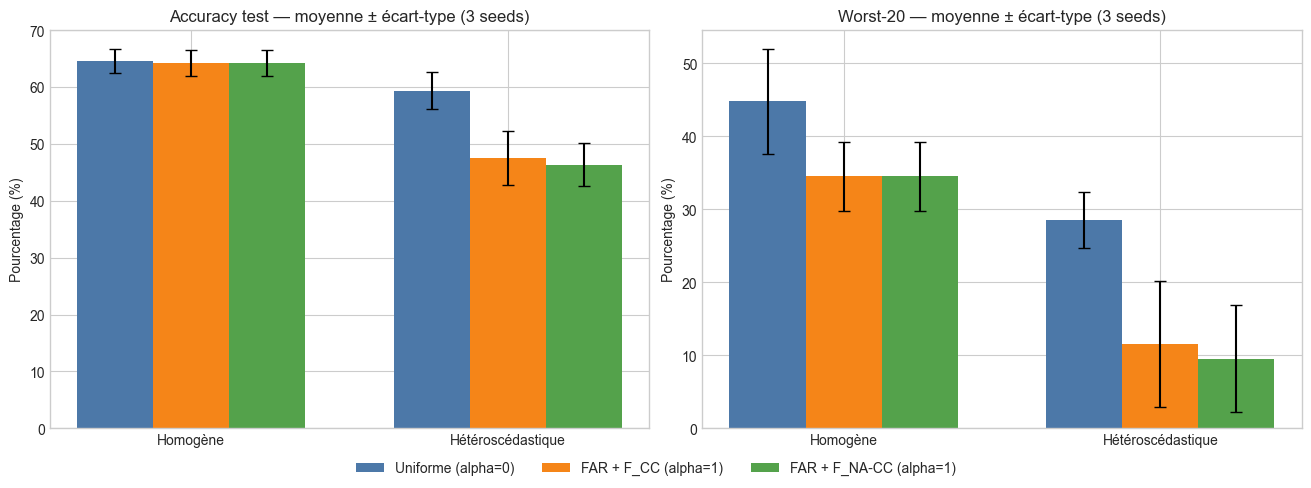

Figure : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/ldp_gradient_far_positioning_notebook/rcig_motivation/real_private_gradients_accuracy_worst20.png


In [43]:
# Figure 1 — niveau de performance et bas de distribution des clients.
arm_order = [
    "Uniforme (alpha=0)",
    "FAR + F_CC (alpha=1)",
    "FAR + F_NA-CC (alpha=1)",
]
regime_order = ["Homogène", "Hétéroscédastique"]
colors = ["#4C78A8", "#F58518", "#54A24B"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for ax, (metric, title) in zip(
    axes,
    [("test_accuracy_pct", "Accuracy test"), ("worst20_pct", "Worst-20")],
):
    x = np.arange(len(regime_order), dtype=float)
    width = 0.24
    for j, arm in enumerate(arm_order):
        means, sds = [], []
        for regime in regime_order:
            values = pd.to_numeric(
                motivation_runs.loc[
                    (motivation_runs["regime"] == regime)
                    & (motivation_runs["arm"] == arm), metric
                ], errors="coerce"
            ).dropna()
            means.append(values.mean())
            sds.append(values.std(ddof=1) if len(values) > 1 else 0.0)
        ax.bar(x + (j - 1) * width, means, width, yerr=sds, capsize=4,
               color=colors[j], label=arm)
    ax.set_xticks(x, regime_order)
    ax.set_ylabel("Pourcentage (%)")
    ax.set_title(f"{title} — moyenne ± écart-type (3 seeds)")
    ax.set_ylim(bottom=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
path = RCIG_EXPORT / "real_private_gradients_accuracy_worst20.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Figure :", path)

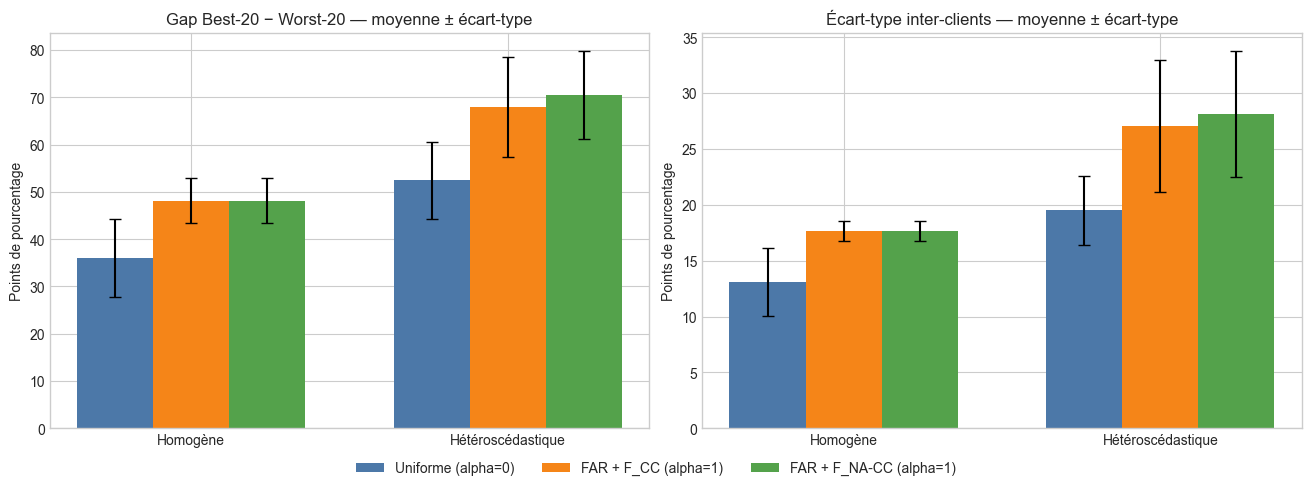

Figure : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/ldp_gradient_far_positioning_notebook/rcig_motivation/real_private_gradients_fairness_dispersion.png


In [44]:
# Figure 2 — deux mesures de dispersion : gap et écart-type inter-clients.
# La racine carrée de la variance est exprimée en points de pourcentage, ce qui
# la rend comparable visuellement au gap. Pour les deux métriques, plus bas est mieux.
dispersion = motivation_runs.copy()
dispersion["client_sd_pp"] = np.sqrt(dispersion["variance_pp2"].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for ax, (metric, title) in zip(
    axes,
    [("gap_pp", "Gap Best-20 − Worst-20"),
     ("client_sd_pp", "Écart-type inter-clients")],
):
    x = np.arange(len(regime_order), dtype=float)
    width = 0.24
    for j, arm in enumerate(arm_order):
        means, sds = [], []
        for regime in regime_order:
            values = pd.to_numeric(
                dispersion.loc[
                    (dispersion["regime"] == regime)
                    & (dispersion["arm"] == arm), metric
                ], errors="coerce"
            ).dropna()
            means.append(values.mean())
            sds.append(values.std(ddof=1) if len(values) > 1 else 0.0)
        ax.bar(x + (j - 1) * width, means, width, yerr=sds, capsize=4,
               color=colors[j], label=arm)
    ax.set_xticks(x, regime_order)
    ax.set_ylabel("Points de pourcentage")
    ax.set_title(f"{title} — moyenne ± écart-type")
    ax.set_ylim(bottom=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
path = RCIG_EXPORT / "real_private_gradients_fairness_dispersion.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Figure :", path)

### 8.1.2 Pourquoi une distance brute confond signal et bruit

Pour une référence $r$ **fixe conditionnellement au passé** et indépendante du
bruit frais, écrivons $Y_i=g_i+Z_i$, avec
$\mathbb E[Z_i]=0$ et $\operatorname{Cov}(Z_i)=\Sigma_i$. Alors

$$
\begin{aligned}
\mathbb E\!\left[\lVert Y_i-r\rVert_2^2\mid r,g_i\right]
&=\mathbb E\!\left[\lVert(g_i-r)+Z_i\rVert_2^2\right]\\
&=\lVert g_i-r\rVert_2^2
  +2(g_i-r)^\top\mathbb E[Z_i]
  +\mathbb E\lVert Z_i\rVert_2^2\\
&=\lVert g_i-r\rVert_2^2+\operatorname{tr}(\Sigma_i).
\end{aligned}
$$

La distance contient donc une **géométrie propre** et un **plancher de bruit**.
Quand les $\Sigma_i$ diffèrent, une grande distance ne signifie pas à elle seule
« client honnête utile » ou « Byzantine ».

La référence intervient ensuite dans l'agrégat FAR. Pour une cohorte fixée avec
$\lVert X_i\rVert_2\le U$, posons

$$
d_i(F)=\lVert X_i-F\rVert_2,
\qquad
\lambda(F)=\operatorname{softmax}(\alpha d(F)),
\qquad
A(F)=\sum_i\lambda_i(F)X_i.
$$

L'inégalité triangulaire inverse donne
$|d_i(F)-d_i(F')|\le\lVert F-F'\rVert_2$. Le contrôle du Jacobien de la
softmax donne alors

$$
\lVert\lambda(F)-\lambda(F')\rVert_1
\le 2|\alpha|\lVert F-F'\rVert_2,
$$

et, pour cette composante où seuls les poids changent,

$$
\lVert A(F)-A(F')\rVert_2
\le U\lVert\lambda(F)-\lambda(F')\rVert_1
\le 2|\alpha|U\lVert F-F'\rVert_2.
$$

Cela explique pourquoi la qualité et la stabilité de la référence comptent
d'autant plus que $|\alpha|$ augmente. Pour $\alpha=0$, les poids sont uniformes
et cette voie d'influence de $F$ sur $A$ est exactement nulle. Cette borne ne
prouve ni fairness, ni optimalité de RCIG, et ne traite pas à elle seule la
dépendance entre poids et bruit du même tour.

L'identité d'espérance du début de cette section a des limites importantes :
elle n'est pas directement valable
si la référence est recalculée sur la même cohorte $F(Y_1,\ldots,Y_n)$, car les
termes deviennent dépendants ; le clipping rend aussi la loi non gaussienne et
modifie covariance et biais. La borne Lipschitz pointwise sur $A(F)$ reste, elle,
valable sous ses hypothèses déterministes. De même, avec des poids du même tour
$\lambda_i(Y_t)$,

$$
\mathbb E\!\left[\sum_i\lambda_i(Y_t)Z_{i,t}\mid\mathcal F_{t-1}\right]
$$

n'est pas automatiquement nul. Cette dépendance est un **risque théorique**,
pas une preuve que la corrélation poids–bruit est positive, ni que le retard ou
RCIG améliorera forcément l'apprentissage. Elle doit être vérifiée empiriquement.

In [45]:
# D2 : diagnostic oracle stratifié de la confusion distance / bruit réalisé.
# Ces variables servent uniquement à l'audit du simulateur ; elles ne sont pas
# disponibles au mécanisme déployé.
d2 = final_df[
    (final_df["campaign"] == "positioning_v3")
    & (final_df["phase"] == "d2_noise_assignment_confirmation")
].copy()

if len(d2) != 48:
    raise RuntimeError(
        f"D2 confirmation incomplète : 48 runs attendus, {len(d2)} trouvés"
    )

oracle_rows = []
for _, row in d2.iterrows():
    payload = json.loads(Path(row["metrics_path"]).read_text(encoding="utf-8"))
    all_rounds = payload["rounds"]
    def median_round_metric(key):
        values = pd.to_numeric(
            pd.Series([round_row.get(key, np.nan) for round_row in all_rounds]),
            errors="coerce",
        ).dropna()
        return float(values.median()) if len(values) else np.nan
    assignment = str(row["noise_assignment"])
    severity, order = assignment.split("_", 1)
    oracle_rows.append({
        "n": int(row["n_clients"]),
        "Sévérité": severity,
        "Affectation": order,
        "Référence": row["reference"],
        "Seed": int(row["seed"]),
        "Corr distance-bruit réalisé": median_round_metric(
            "far_distance_dp_noise_corr_oracle"),
        "Corr poids-bruit réalisé": median_round_metric(
            "far_weight_dp_noise_corr_oracle"),
        "Corr score bruité-score propre": median_round_metric(
            "far_honest_noisy_clean_score_corr_oracle"),
        "Rappel top-tail honnête": median_round_metric(
            "far_honest_clean_top_tail_recall_oracle"),
    })

d2_oracle = pd.DataFrame(oracle_rows)
group_keys = ["n", "Sévérité", "Affectation", "Référence"]
diagnostics = [
    "Corr distance-bruit réalisé",
    "Corr poids-bruit réalisé",
    "Corr score bruité-score propre",
    "Rappel top-tail honnête",
]
d2_rows = []
for keys, group in d2_oracle.groupby(group_keys, sort=False):
    out = dict(zip(group_keys, keys))
    for metric in diagnostics:
        values = pd.to_numeric(group[metric], errors="coerce").dropna()
        mean = values.mean()
        sd = values.std(ddof=1) if len(values) > 1 else np.nan
        out[metric] = (
            f"{mean:.3f} ± {sd:.3f}" if np.isfinite(sd) else f"{mean:.3f}"
        )
    d2_rows.append(out)
d2_summary = pd.DataFrame(d2_rows)

display(Markdown(
    "### 8.1.3 D2 — affectations de bruit stratifiées (oracle)\n\n"
    "`identity` et `reverse` permutent les niveaux publics entre identités clientes. "
    "Elles testent si le diagnostic suit le niveau de bruit plutôt qu'une identité "
    "ou une partition particulière. Les trois seeds sont les réplications ; les "
    "deux affectations ne doivent pas être comptées comme six seeds. Chaque valeur "
    "par seed est d'abord la médiane sur les rounds. Ici, « bruit réalisé » désigne "
    "la norme de la réalisation fraîche simulée, connue uniquement de l'oracle, et "
    "non le multiplicateur public sigma."
))
for (n, severity), group in d2_summary.groupby(["n", "Sévérité"]):
    display(Markdown(f"**{n} clients — hétéroscédasticité {severity}**"))
    display(group.drop(columns=["n", "Sévérité"]).sort_values(["Référence", "Affectation"]))
display(Markdown(
    "**Lecture.** Les distances et les poids suivent presque parfaitement "
    "la norme du bruit réalisé, alors que la corrélation score bruité–score "
    "propre est faible, parfois négative. Le rappel mesure la fraction des "
    "20 % d'honnêtes les plus éloignés selon le score propre que retrouve "
    "le classement bruité : 1 signifie tous retrouvés, 0 aucun. Ces clients "
    "sont des outliers géométriques ; leur utilité pour l'apprentissage n'est "
    "pas garantie par cette seule distance.\n\n"
    "Ces corrélations sont calculées **entre clients** à chaque tour. Sous "
    "hétéroscédasticité, elles mélangent l'effet des niveaux de bruit et "
    "celui des fluctuations aléatoires. Elles ne démontrent pas un effet "
    "du tirage frais à niveau de bruit fixé, ni un avantage du retard des poids."
))
d2_oracle.to_csv(RCIG_EXPORT / "d2_oracle_seed_rows.csv", index=False)
d2_summary.to_csv(RCIG_EXPORT / "d2_oracle_stratified_summary.csv", index=False)
print("Source :", RESULTS_ROOT / "positioning_v3" / "d2_noise_assignment_confirmation")

### 8.1.3 D2 — affectations de bruit stratifiées (oracle)

`identity` et `reverse` permutent les niveaux publics entre identités clientes. Elles testent si le diagnostic suit le niveau de bruit plutôt qu'une identité ou une partition particulière. Les trois seeds sont les réplications ; les deux affectations ne doivent pas être comptées comme six seeds. Chaque valeur par seed est d'abord la médiane sur les rounds. Ici, « bruit réalisé » désigne la norme de la réalisation fraîche simulée, connue uniquement de l'oracle, et non le multiplicateur public sigma.

**10 clients — hétéroscédasticité mild**

,Affectation,Référence,Corr distance-bruit réalisé,Corr poids-bruit réalisé,Corr score bruité-score propre,Rappel top-tail honnête
0,identity,F_CC,0.998 ± 0.001,0.998 ± 0.001,-0.344 ± 0.320,0.000 ± 0.000
2,reverse,F_CC,0.997 ± 0.003,0.998 ± 0.001,0.041 ± 0.437,0.167 ± 0.289
1,identity,RFA,0.998 ± 0.001,0.995 ± 0.003,-0.327 ± 0.337,0.000 ± 0.000
3,reverse,RFA,0.997 ± 0.003,0.994 ± 0.003,0.028 ± 0.450,0.167 ± 0.289


**10 clients — hétéroscédasticité strong**

,Affectation,Référence,Corr distance-bruit réalisé,Corr poids-bruit réalisé,Corr score bruité-score propre,Rappel top-tail honnête
4,identity,F_CC,0.999 ± 0.001,0.999 ± 0.000,-0.265 ± 0.398,0.167 ± 0.289
6,reverse,F_CC,0.998 ± 0.002,0.999 ± 0.000,0.090 ± 0.426,0.167 ± 0.289
5,identity,RFA,0.998 ± 0.001,0.997 ± 0.001,-0.242 ± 0.423,0.167 ± 0.289
7,reverse,RFA,0.998 ± 0.002,0.997 ± 0.001,0.081 ± 0.441,0.167 ± 0.289


...

,Affectation,Référence,Corr distance-bruit réalisé,Corr poids-bruit réalisé,Corr score bruité-score propre,Rappel top-tail honnête
8,identity,F_CC,0.991 ± 0.002,0.997 ± 0.001,0.150 ± 0.368,0.267 ± 0.115
10,reverse,F_CC,0.991 ± 0.005,0.997 ± 0.001,0.004 ± 0.341,0.200 ± 0.000
9,identity,RFA,0.990 ± 0.002,0.996 ± 0.001,0.168 ± 0.359,0.333 ± 0.115
11,reverse,RFA,0.990 ± 0.005,0.996 ± 0.001,-0.005 ± 0.337,0.200 ± 0.000


**25 clients — hétéroscédasticité strong**

,Affectation,Référence,Corr distance-bruit réalisé,Corr poids-bruit réalisé,Corr score bruité-score propre,Rappel top-tail honnête
12,identity,F_CC,0.991 ± 0.002,0.998 ± 0.001,0.150 ± 0.370,0.333 ± 0.115
14,reverse,F_CC,0.992 ± 0.003,0.998 ± 0.001,-0.005 ± 0.347,0.200 ± 0.000
13,identity,RFA,0.990 ± 0.002,0.997 ± 0.001,0.170 ± 0.355,0.333 ± 0.115
15,reverse,RFA,0.991 ± 0.003,0.997 ± 0.001,-0.016 ± 0.343,0.200 ± 0.000


**Lecture.** Les distances et les poids suivent presque parfaitement la norme du bruit réalisé, alors que la corrélation score bruité–score propre est faible, parfois négative. Le rappel mesure la fraction des 20 % d'honnêtes les plus éloignés selon le score propre que retrouve le classement bruité : 1 signifie tous retrouvés, 0 aucun. Ces clients sont des outliers géométriques ; leur utilité pour l'apprentissage n'est pas garantie par cette seule distance.

Ces corrélations sont calculées **entre clients** à chaque tour. Sous hétéroscédasticité, elles mélangent l'effet des niveaux de bruit et celui des fluctuations aléatoires. Elles ne démontrent pas un effet du tirage frais à niveau de bruit fixé, ni un avantage du retard des poids.

Source : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/ldp_gradient_far/positioning_v3/d2_noise_assignment_confirmation


### 8.1.4 Une meilleure variance de référence ne suffit pas

La première correction inverse-variance favorisait les clients dont le bruit
était plus faible. Dans l'exemple de deux groupes de même taille, de variances
respectives v et 4v, les poids internes de référence deviennent 0,16 et 0,04
à n = 10 : les masses de groupe sont 0,8 et 0,2, au lieu de 0,5 et 0,5.
Dans le cas linéaire idéal sans clipping, sa variance est 0,16v au lieu de
0,25v pour l'uniforme, soit une baisse de 36 %.

Mais, si les moyennes propres des groupes diffèrent, cette pondération change
aussi la cible. Elle ne préserve pas automatiquement la représentation d'un
groupe honnête plus bruité. De plus, FAR utilise ensuite les distances à cette
référence pour repondérer les gradients : **optimiser la variance de F n'est
pas optimiser la qualité de l'agrégat FAR**.

C'est précisément ce qu'illustre la campagne réelle ci-dessus : malgré ce gain
de variance théorique, la variante inverse-variance ne restaure ni l'accuracy
ni le Worst-20 sous bruit hétéroscédastique. La dérivation de la cible et de la
covariance résiduelle figure dans
[l'analyse préalable des références](../output/analysis/Gaussian_Aware_Robust_Reference_Beyond_FCC.md).
La réduction de 36 % n'est pas une mesure de variance après toute la chaîne
non linéaire de clipping.

### 8.1.5 Ce que nos premiers essais réels de mémoire nous avaient appris

Il ne faut pas réécrire l'histoire en affirmant que « la mémoire marchait
déjà ». Les essais antérieurs à RCIG étaient exploratoires et peu favorables :

| Essai sur Fashion-MNIST | Observation | Enseignement pour la construction |
|---|---|---|
| Stage 14B : 25 clients, 6 tours, seed 28 | Remplacer FCC courant par une référence passée donne des deltas d'accuracy allant de −0,02 à +0,38 pp selon la menace ; pas de gain cohérent de gap | Un historique utilisé systématiquement n'est pas une solution validée |
| Stage 14C : 25 clients, 20 tours, seed 28, propre → attaque → récupération | FCC temporel : erreur propre de référence 0,0051 contre 0,0025 pour FCC courant ; delta d'accuracy finale moyen −0,17 pp sur les trois menaces | La mémoire peut introduire un décalage nuisible même avant l'attaque |
| Même stage 14C | Les neuf bras reviennent à l'enveloppe propre dès le premier tour de récupération | Ce stress ne démontre pas de bénéfice de mémoire face à un empoisonnement persistant |

Sources : [stage 14B](../output/analysis/DT_LDP_FAR_Stage14B_FashionMNIST_Temporal_Reference.md)
et [stage 14C](../output/analysis/DT_LDP_FAR_Stage14C_Temporal_Poison_Recovery.md).
Ce sont des entraînements avec DP-SGD local à pas Poisson, distincts de la
campagne LDP-Gradient-FAR à gradient unique et batch fixe. Leurs chiffres ne
sont pas fusionnés ; ils apportent un enseignement de conception, pas une
comparaison directe d'algorithmes sous le même protocole.

**Inférence, pas résultat démontré :** si l'on réutilise l'historique, il faut
envisager de le faire sélectivement. Quand la vue récente paraît compatible
avec l'évolution honnête et le bruit attendu, la conserver évite une
correction temporelle inutile. C'est la raison de chercher une **tolérance
statistique au bruit**, plutôt qu'un simple remplacement systématique par le
passé.

### 8.1.6 Pourquoi envisager une référence temporelle sélective ?

**Ce que les données nous ont appris :** une grande distance instantanée peut
refléter le bruit, et une modification de référence peut déplacer les poids
sans améliorer la fairness. **Ce qu'elles n'ont pas prouvé :** qu'un historique
permettrait nécessairement de reconnaître les Byzantins.

Le passage au temporel vient du raisonnement suivant. Dans une seule cohorte,
trois causes peuvent produire un message éloigné : données honnêtes atypiques,
perturbation DP, ou attaque. Si un attaquant reproduit exactement la même loi
observable qu'un honnête atypique, aucune règle utilisant seulement cette
observation ne peut distinguer les deux. Une hypothèse supplémentaire est donc
nécessaire : séparation entre groupes, structure connue, ou continuité
temporelle. **L'historique est l'option que nous proposons d'exploiter ; ce n'est
pas une nécessité universelle démontrée.**

Pour visualiser cette idée, considérons le modèle explicatif avant clipping
serveur, pour une identité cliente i suivie à deux instants :

$$
Y_{i,t}=g_{i,t}+Z_{i,t}+b_{i,t},
\qquad
Y_{i,t}-Y_{i,s}
=(g_{i,t}-g_{i,s})+(Z_{i,t}-Z_{i,s})+(b_{i,t}-b_{i,s}).
$$

Ici g est le gradient propre, Z le bruit DP et b un déplacement d'attaque
(nul pour un client honnête). Ce modèle explicatif ne suppose pas que le
serveur connaît g ou b. Le niveau atypique mais stable de g peut disparaître
dans la différence ; restent son évolution normale, la fluctuation de bruit,
et un éventuel changement d'attaque.

Dans le cas idéal de bruits indépendants à covariances fixées,
Cov(Z au temps t − Z au temps s) = Σ au temps t + Σ au temps s.
On peut donc chercher à comparer une évolution récente à son incertitude
attendue, plutôt que juger uniquement sa distance brute. Les fenêtres de
plusieurs tours peuvent réduire la fluctuation, **au prix d'un retard face à
l'évolution du vrai gradient**. Après clipping et apprentissage adaptatif,
il faut auditer les covariances effectives et le drift ; cette identité simple
ne suffit plus à fournir un test calibré.

### 8.1.7 Du problème observé au cahier des charges — sans résultat synthétique

| Point de départ | Conclusion défendable | Propriété recherchée |
|---|---|---|
| Sous DP, FAR positif détériore Worst-20 et gap dans les comparaisons réelles affichées | L'inclusion par distance ne préserve pas automatiquement la fairness | Vérifier ensemble qualité du centre, poids finaux et fairness |
| Dans D2, distances/poids suivent le bruit tandis que le classement propre est mal retrouvé | Une grande distance ne signifie pas nécessairement signal honnête utile | Tenir compte du niveau et de la géométrie du bruit DP attendu |
| La référence inverse-variance ne transmet pas son gain à l'agrégat | Réduire la variance seule et favoriser systématiquement les clients peu bruités ne suffit pas | Tolérer une variation honnête compatible avec son incertitude |
| Pour α positif, même une bonne référence peut donner un grand poids à un message byzantin éloigné | Référence robuste et agrégat FAR robuste sont deux exigences distinctes | Limiter l'influence d'une rupture anormale, sans exclure tous les honnêtes atypiques |
| Une cohorte instantanée ne contient pas toujours assez d'information pour séparer ces causes | La continuité temporelle peut être une information auxiliaire, sous hypothèses | Comparer historique et évolution récente, avec une tolérance au drift et au bruit |

Le lien avec l'erreur d'agrégation et la convergence est expliqué dans
[l'analyse théorique préalable](../output/analysis/LDP_Gradient_FAR_Convergence_Alpha_Byzantine_DP.md).
Les diagnostics empiriques sous attaques sont détaillés séparément en section 7.

**L'intuition à présenter est donc :** ne pas punir une déviation simplement
parce qu'elle est grande ; examiner si son évolution est compatible avec le
bruit DP et le drift honnête attendus, et limiter son effet lorsqu'elle ne
l'est pas. C'est le cahier des charges qui motive un mécanisme comme RCIG.

Ce n'est pas encore une preuve d'identification des Byzantins. Une évolution
honnête rapide peut être signalée à tort ; une attaque lente ou déjà présente
dans l'historique peut passer inaperçue. Les expériences **après construction**
doivent précisément tester ces limites, sans servir rétrospectivement à
justifier l'intuition de départ. En particulier, cette piste n'est pas fondée
sur un avantage préalablement démontré du retard des poids FAR : exploiter un
historique de référence est une autre proposition.

## 9. Explorateur de cellules strictement comparables

La fonction suivante évite les comparaisons accidentelles. Elle exige un seul
`campaign`, une seule `phase` et un seul `horizon`; elle signale sinon la liste
des strates qu'il faut analyser séparément.

In [46]:
def comparable_cell(frame, *, campaign, phase, horizon, n_clients=None, dp_enabled=None,
                    target_epsilon=None, attack=None):
    view = frame[
        (frame.campaign == campaign) & (frame.phase == phase) & (frame.horizon == horizon)
    ].copy()
    if n_clients is not None: view = view[view.n_clients == n_clients]
    if dp_enabled is not None: view = view[view.dp_enabled == dp_enabled]
    if target_epsilon is not None: view = view[np.isclose(view.target_epsilon, target_epsilon, equal_nan=False)]
    if attack is not None: view = view[view.attack == attack]
    return view


if len(final_df):
    example = final_df.groupby(["campaign", "phase", "horizon"]).size().sort_values(ascending=False).index[0]
    example_view = comparable_cell(
        final_df, campaign=example[0], phase=example[1], horizon=example[2]
    )
    print("Exemple sélectionné :", example, "—", len(example_view), "runs")
    display(example_view[[
        "seed", "n_clients", "dp_enabled", "target_epsilon", "C_local", "alpha",
        "reference", "attack", "test_accuracy_pct", "worst20_pct", "gap_pp",
    ]].head(50))

Exemple sélectionné : ('positioning_v3', 'f_confirmation_t20', np.int64(20)) — 180 runs


,seed,n_clients,dp_enabled,target_epsilon,C_local,alpha,reference,attack,test_accuracy_pct,worst20_pct,gap_pp
8659,28,10,True,4.0,8.0,2.0,CM,alie,48.02,22.00,50.15
8679,36,10,True,4.0,8.0,2.0,CM,alie,50.84,47.30,20.55
8699,54,10,True,4.0,8.0,2.0,CM,alie,43.56,8.60,70.80
8719,28,10,True,4.0,8.0,2.0,F_CC,alie,47.96,22.10,50.05
8739,36,10,True,4.0,8.0,2.0,F_CC,alie,50.66,47.45,20.25
8759,54,10,True,4.0,8.0,2.0,F_CC,alie,44.12,9.65,69.25
8779,28,10,True,4.0,8.0,2.0,RFA,alie,48.00,22.10,50.00
8799,36,10,True,4.0,8.0,2.0,RFA,alie,50.69,47.40,20.15
8819,54,10,True,4.0,8.0,2.0,RFA,alie,44.05,9.30,70.00
8839,28,10,True,4.0,8.0,2.0,trMean,alie,48.06,22.15,50.05


## 10. Vues explicites par axe expérimental

Chaque panneau sélectionne automatiquement une cellule où l'axe varie tout en
gardant fixes campagne, phase et horizon ainsi que les autres facteurs connus.
S'il n'existe pas au moins deux valeurs de l'axe, le panneau affiche « non
identifiable ». Les vues couvrent performance/loss, fairness et, lorsqu'ils
existent, les oracles de robustesse.

Cellule C_local : ('positioning_v3', 'b3_local_clip_dp_confirmation', np.int64(20), 'fashionmnist', 'lenet5_tanh', np.int64(10), 'client_dirichlet_balanced', 'fixed_without_replacement', 'replace_one', 'single_step_gradient', np.True_, np.float64(4.0), 'homogeneous', 'homogeneous', (1.0,), np.float64(16.0), np.float64(0.0), 'F_CC', 'none')


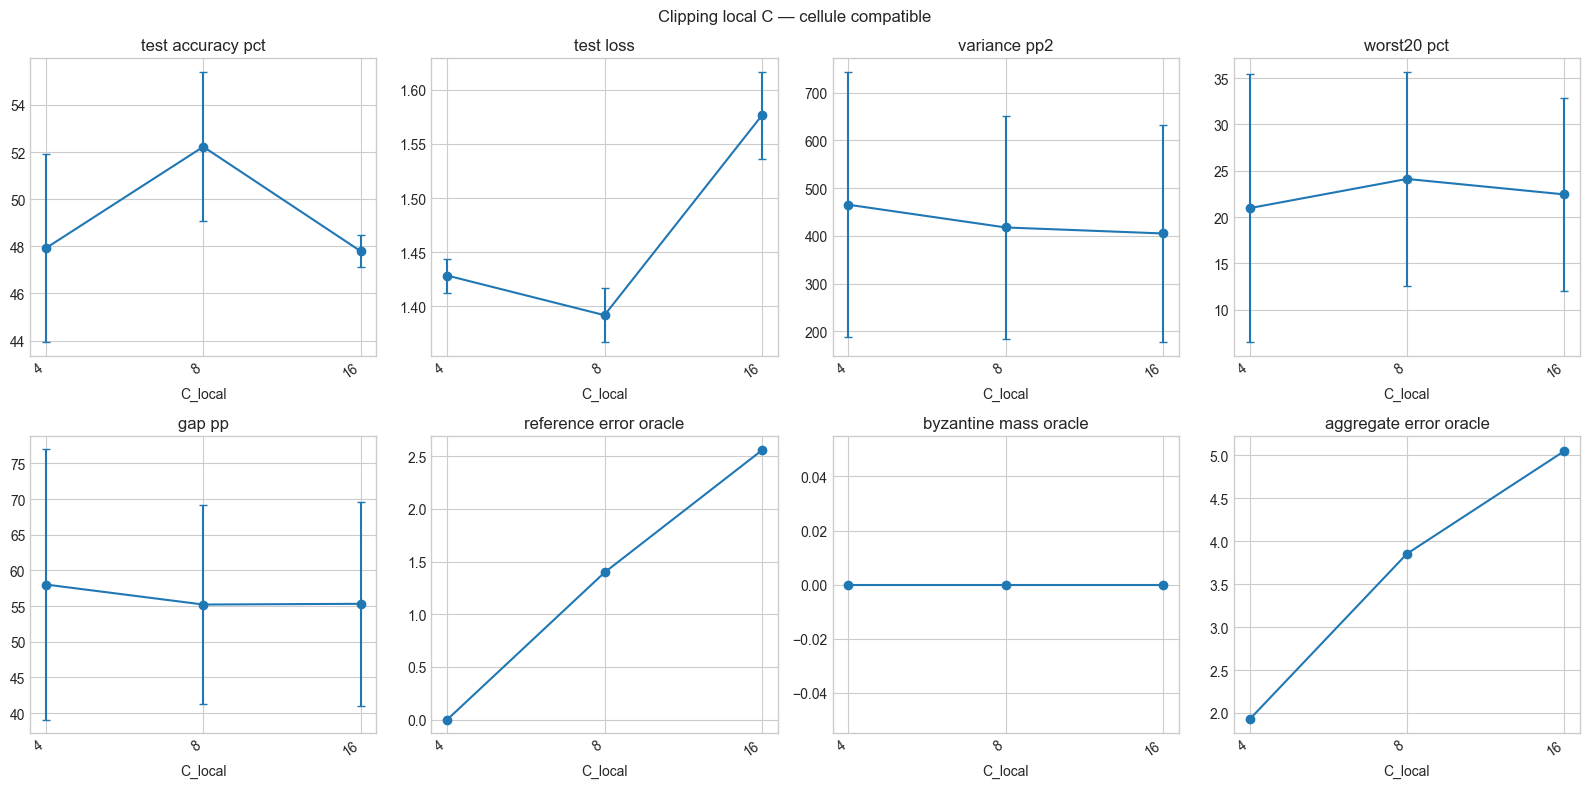

In [47]:
AXIS_METRICS = [
    "test_accuracy_pct", "test_loss", "variance_pp2", "worst20_pct", "gap_pp",
    "reference_error_oracle", "byzantine_mass_oracle", "aggregate_error_oracle",
]


def select_axis_cell(frame, axis, invariants):
    candidates = []
    for keys, group in frame.groupby(invariants, dropna=False):
        distinct = group[axis].dropna().nunique()
        if distinct >= 2:
            seed_counts = group.groupby(axis, dropna=False).seed.nunique()
            candidates.append((
                int(seed_counts.min()), distinct, group.run_uid.nunique(), keys, group,
            ))
    if not candidates:
        return pd.DataFrame(), None
    # A confirmation multi-seeds is preferred to a wider one-seed screen.
    candidates.sort(key=lambda item: (item[0], item[1], item[2]), reverse=True)
    return candidates[0][4].copy(), candidates[0][3]


def plot_axis_panel(view, axis, title):
    if view.empty:
        display(Markdown(f"**Non identifiable : pas de cellule compatible pour {title}.**"))
        return
    usable = [metric for metric in AXIS_METRICS if view[metric].notna().any()]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), squeeze=False)
    for ax, metric in zip(axes.ravel(), usable):
        stats = view.groupby(axis, dropna=False)[metric].agg(["mean", "std", "count"]).reset_index()
        labels = stats[axis].map(
            lambda value: f"{value:.4g}" if isinstance(value, (float, np.floating)) else str(value)
        )
        positions = np.arange(len(stats))
        ax.plot(positions, stats["mean"], marker="o")
        multi = stats["count"] >= 2
        if multi.any():
            ax.errorbar(positions[multi], stats.loc[multi, "mean"],
                        yerr=stats.loc[multi, "std"], fmt="none", capsize=3)
        ax.set_xticks(positions, labels, rotation=35, ha="right")
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel(axis)
    for ax in axes.ravel()[len(usable):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(); plt.show()


common = ["campaign", "phase", "horizon", "dataset", "model", "n_clients",
          "partition", "sampling_scheme", "adjacency", "update_mode", "dp_enabled",
          "target_epsilon", "noise_profile", "noise_assignment", "noise_signature",
          "U_server", "alpha", "reference", "attack"]
c_invariants = [key for key in common if key != "C_local"]
c_view, c_key = select_axis_cell(final_df, "C_local", c_invariants)
print("Cellule C_local :", c_key)
plot_axis_panel(c_view, "C_local", "Clipping local C — cellule compatible")

**Attention — transfert confondu :** une différence entre n=10 et n=25 ne peut pas être attribuée causalement à n, car N_i, le batch et parfois C/U changent.

Cellule de transfert n : positioning_v3/B3; profils calibrés n10:C8 et n25:C4


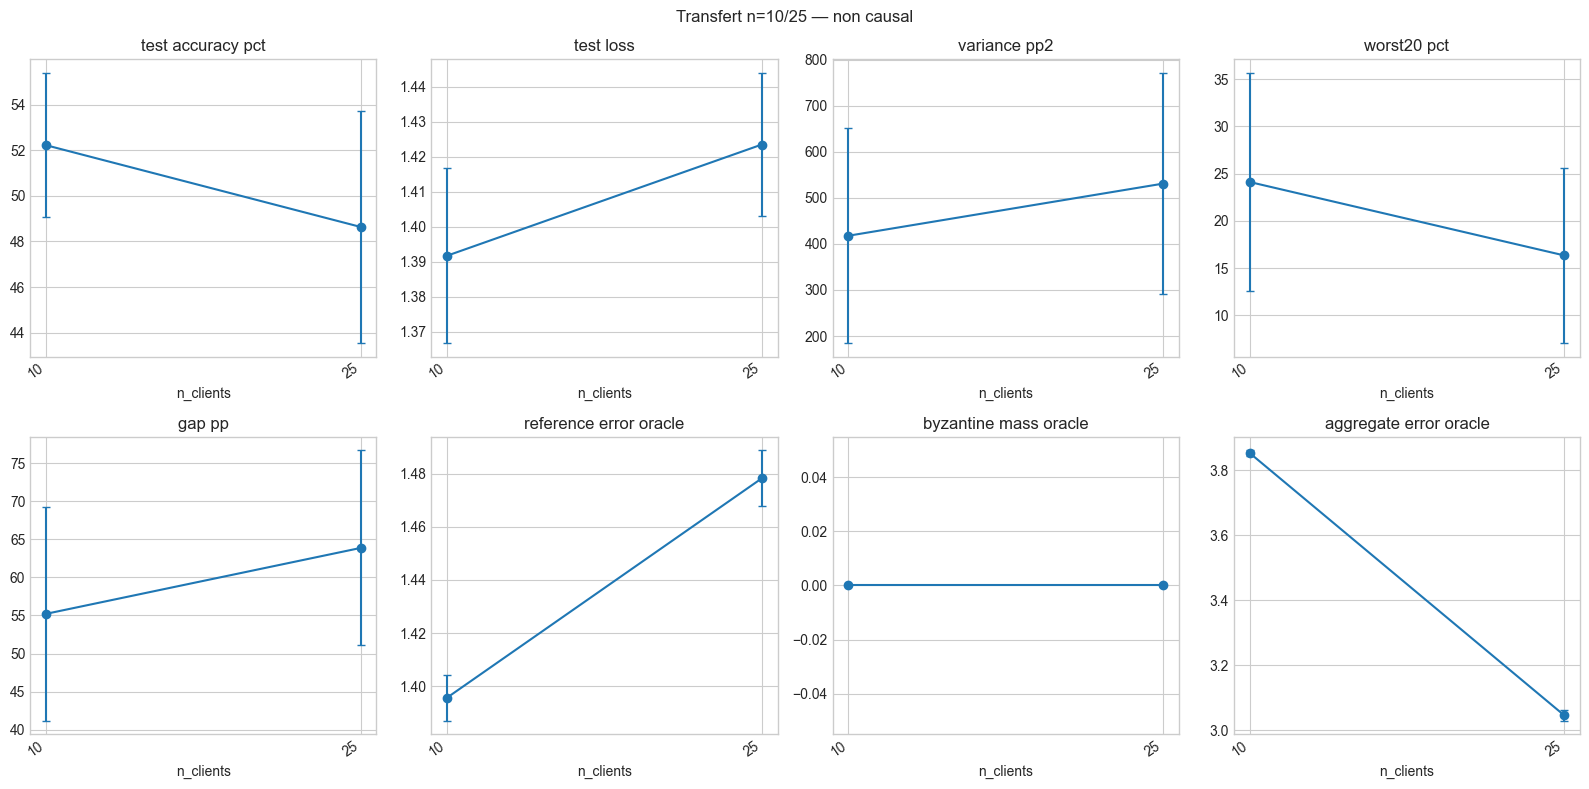

In [48]:
# Transfert des deux profils calibrés de B3 : C=8 à n=10 et C=4 à n=25.
# On évite ainsi de moyenner plusieurs valeurs de C comme si elles étaient des seeds.
n_view = final_df[
    (final_df.campaign == "positioning_v3")
    & (final_df.phase == "b3_local_clip_dp_confirmation")
    & (
        ((final_df.n_clients == 10) & np.isclose(final_df.C_local, 8.0))
        | ((final_df.n_clients == 25) & np.isclose(final_df.C_local, 4.0))
    )
].copy()
n_key = "positioning_v3/B3; profils calibrés n10:C8 et n25:C4"
display(Markdown(
    "**Attention — transfert confondu :** une différence entre n=10 et n=25 "
    "ne peut pas être attribuée causalement à n, car N_i, le batch et parfois C/U changent."
))
print("Cellule de transfert n :", n_key)
plot_axis_panel(n_view, "n_clients", "Transfert n=10/25 — non causal")

Cellule epsilon réalisé : ('positioning_v3', 'd_privacy_screen_v3', np.int64(20), 'fashionmnist', 'lenet5_tanh', np.int64(10), 'client_dirichlet_balanced', 'fixed_without_replacement', 'replace_one', 'single_step_gradient', np.float64(8.0), np.float64(-2.0), 'F_CC', 'none', 'homogeneous')


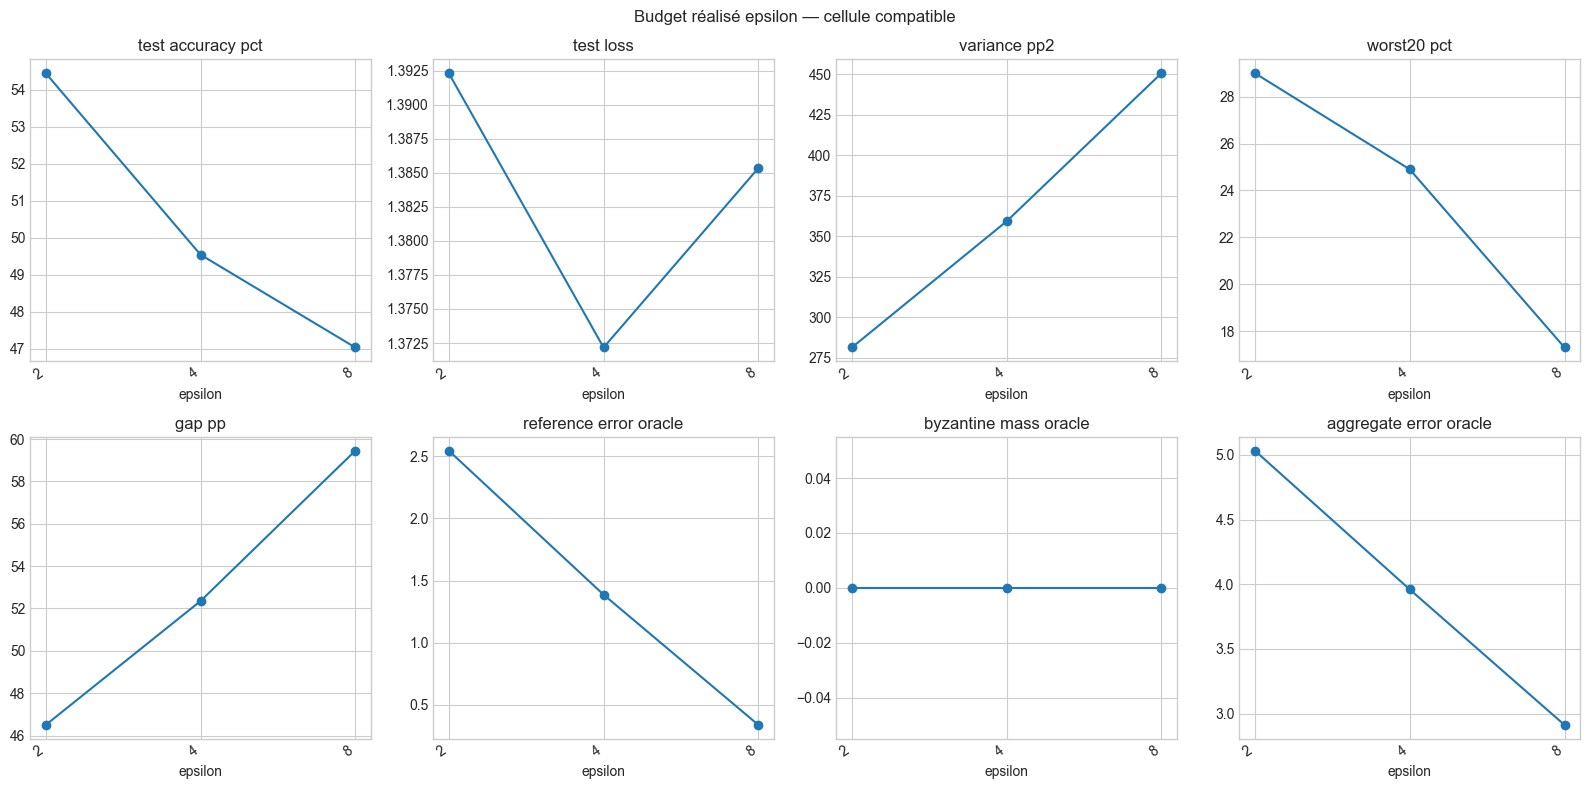

Cellule bruit multi-seeds : ('rcig_end_to_end_v2', 'r0_dynamic_calibration', np.int64(40), 'fashionmnist', 'lenet5_tanh', np.int64(25), 'client_dirichlet_balanced', 'fixed_without_replacement', 'replace_one', 'single_step_gradient', np.float64(4.0), np.float64(0.1), 'rcig_temporal', 'none', np.float64(4.0))


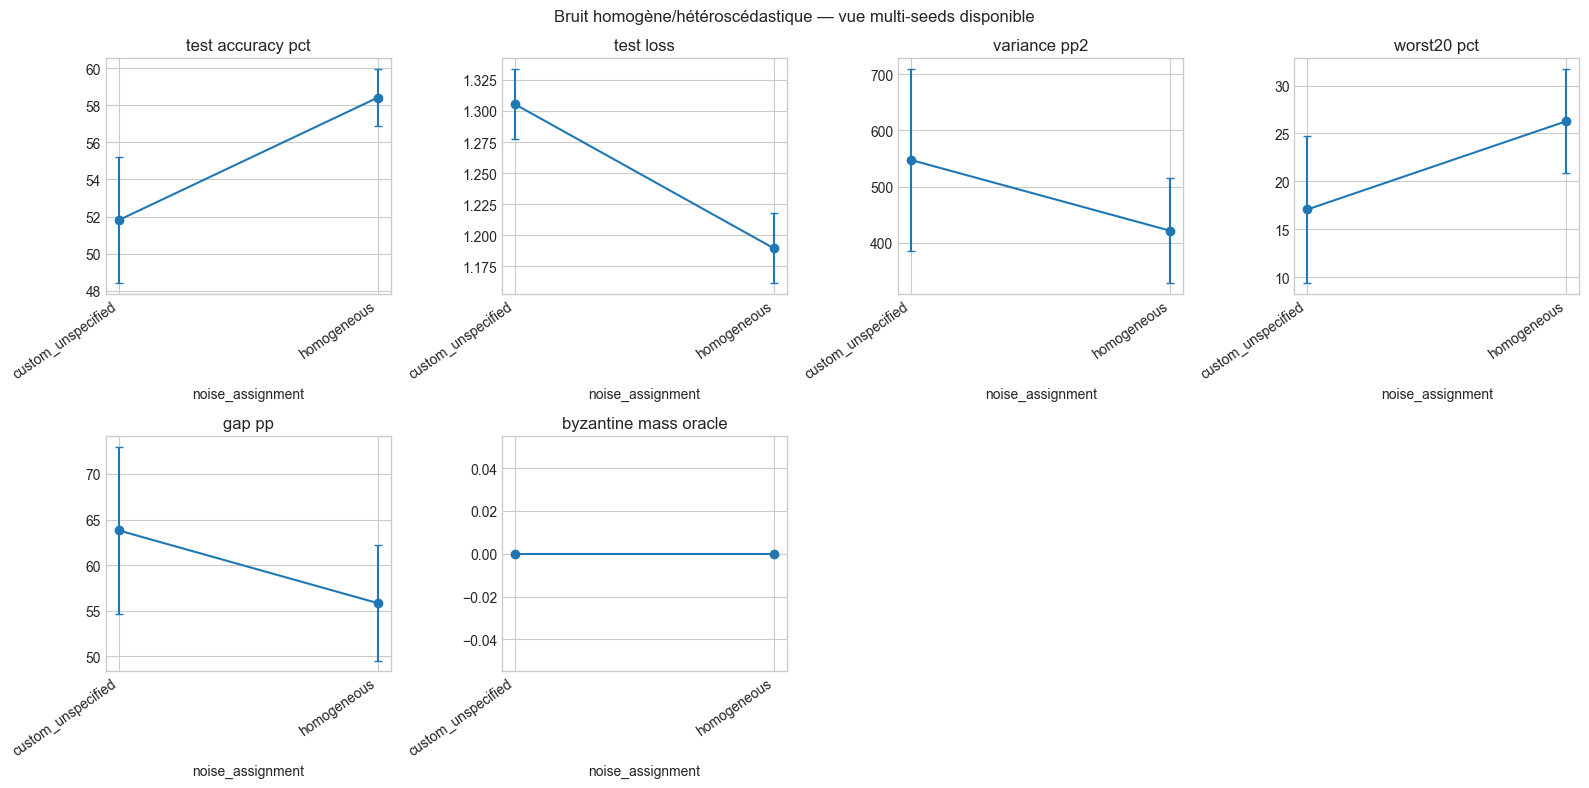

,noise_profile,noise_assignment,sigma_min,sigma_mean,sigma_max,epsilon,test_accuracy_pct,test_loss,worst20_pct,gap_pp
12319,heteroscedastic,custom_unspecified,2.073638,3.068985,4.147276,4.000077,46.06,1.348509,2.70,82.35
12359,heteroscedastic,custom_unspecified,2.073638,3.068985,4.147276,4.000077,49.33,1.306029,30.75,44.90
12399,heteroscedastic,custom_unspecified,2.073638,3.068985,4.147276,4.000077,52.64,1.310767,19.25,58.50
12439,heteroscedastic,custom_unspecified,2.073638,3.068985,4.147276,4.000077,52.23,1.303080,11.15,68.30
12479,heteroscedastic,custom_unspecified,2.073638,3.068985,4.147276,4.000077,55.06,1.284898,30.00,52.60
...,...,...,...,...,...,...,...,...,...,...
16359,homogeneous,homogeneous,2.073638,2.073638,2.073638,4.000077,56.37,1.211126,21.80,59.30
16399,homogeneous,homogeneous,2.073638,2.073638,2.073638,4.000077,56.63,1.229897,24.40,60.15
16439,homogeneous,homogeneous,2.073638,2.073638,2.073638,4.000077,59.45,1.177871,22.60,62.30
16479,homogeneous,homogeneous,2.073638,2.073638,2.073638,4.000077,57.26,1.204095,21.90,60.25


**D2 — assignations mild/strong × identity/reverse :** une seule seed de développement; les deux ordres sont une nuisance appariée, pas des réplications.

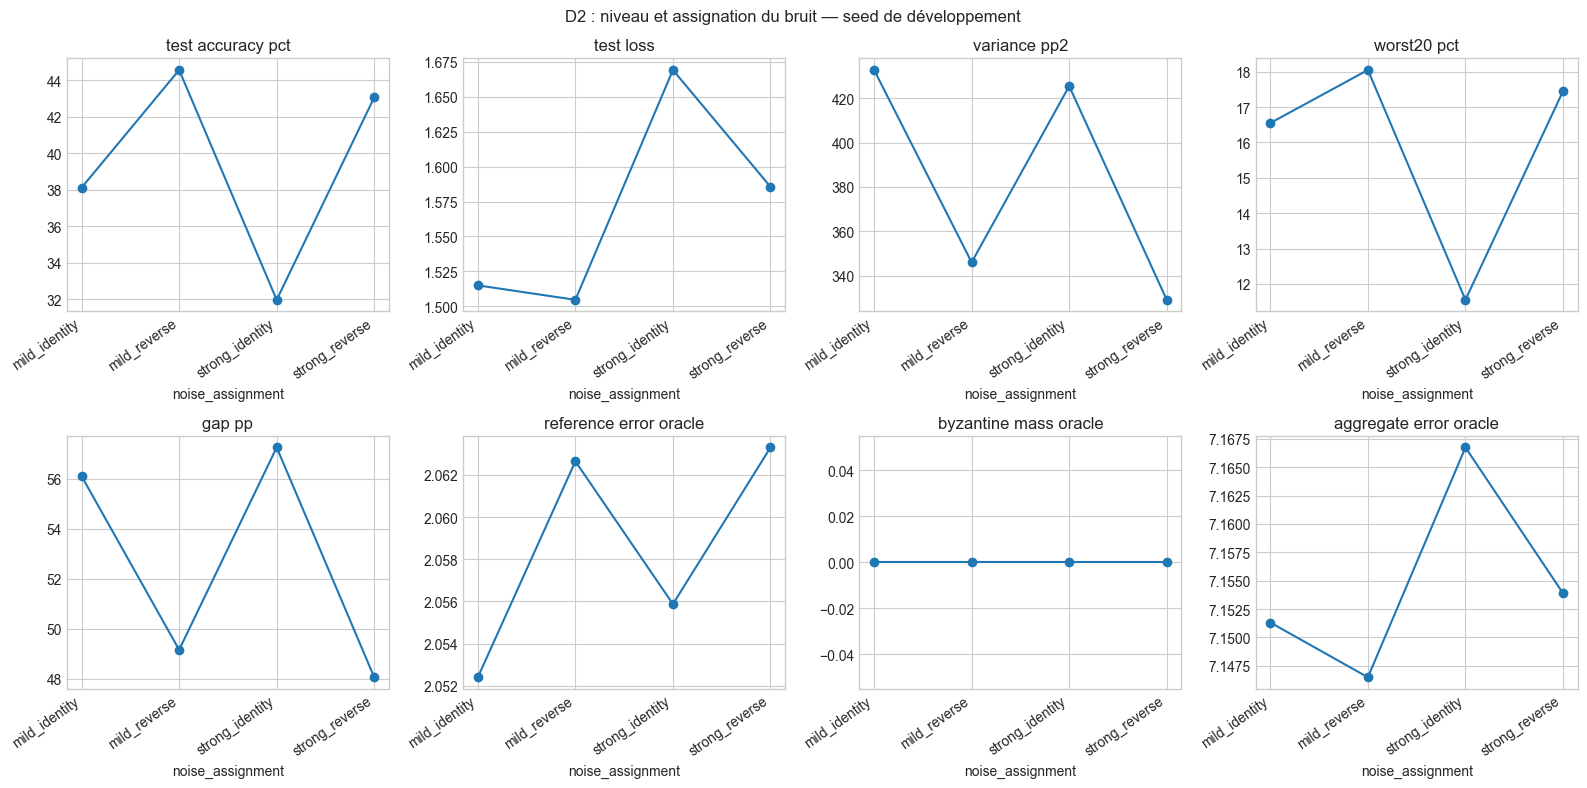

,noise_profile,noise_assignment,sigma_min,sigma_mean,sigma_max,epsilon,test_accuracy_pct,test_loss,variance_pp2,worst20_pct,gap_pp
5019,heteroscedastic,mild_identity,1.835839,2.294799,2.753759,4.00009,38.11,1.514963,432.7249,16.55,56.10
5059,heteroscedastic,mild_reverse,1.835839,2.294799,2.753759,4.00009,44.55,1.504618,345.9725,18.05,49.15
5099,heteroscedastic,strong_identity,1.835839,2.753759,3.671679,4.00009,31.97,1.669257,425.4501,11.55,57.25
5139,heteroscedastic,strong_reverse,1.835839,2.753759,3.671679,4.00009,43.05,1.585559,329.0525,17.45,48.05


In [49]:
# Deux vues privacy : epsilon réalisé, puis profil de bruit/sigma. Elles restent
# stratifiées par campagne/phase/horizon et configuration algorithmique.
privacy_invariants = [
    "campaign", "phase", "horizon", "dataset", "model", "n_clients", "partition",
    "sampling_scheme", "adjacency", "update_mode", "C_local", "alpha", "reference", "attack",
    "noise_assignment",
]
eps_view, eps_key = select_axis_cell(final_df, "epsilon", privacy_invariants)
print("Cellule epsilon réalisé :", eps_key)
plot_axis_panel(eps_view, "epsilon", "Budget réalisé epsilon — cellule compatible")

noise_invariants = [key for key in privacy_invariants if key != "noise_assignment"] + ["target_epsilon"]
noise_view, noise_key = select_axis_cell(final_df, "noise_assignment", noise_invariants)
print("Cellule bruit multi-seeds :", noise_key)
plot_axis_panel(noise_view, "noise_assignment", "Bruit homogène/hétéroscédastique — vue multi-seeds disponible")
if len(noise_view):
    display(noise_view[["noise_profile", "noise_assignment", "sigma_min", "sigma_mean", "sigma_max", "epsilon",
                        "test_accuracy_pct", "test_loss", "worst20_pct", "gap_pp"]]
            .sort_values(["noise_assignment", "sigma_mean"]))

# D2 is deliberately shown separately: identity/reverse are paired assignments,
# not independent seeds, and each arm is still a development result.
d2_view = final_df[
    (final_df.campaign == "positioning_v3")
    & (final_df.phase == "d2_noise_assignment_dev")
    & (final_df.n_clients == 10)
    & np.isclose(final_df.C_local, 8.0)
    & np.isclose(final_df.alpha, 2.0)
    & (final_df.reference == "F_CC")
].copy()
display(Markdown(
    "**D2 — assignations mild/strong × identity/reverse :** une seule seed de "
    "développement; les deux ordres sont une nuisance appariée, pas des réplications."
))
plot_axis_panel(d2_view, "noise_assignment", "D2 : niveau et assignation du bruit — seed de développement")
if len(d2_view):
    display(d2_view[["noise_profile", "noise_assignment", "sigma_min", "sigma_mean", "sigma_max", "epsilon",
                     "test_accuracy_pct", "test_loss", "variance_pp2", "worst20_pct", "gap_pp"]]
            .sort_values("noise_assignment"))

Fractions disponibles dans tout le snapshot : [0.0, 0.2]


**Seulement deux points (0 % et 20 %) : présence/absence d'attaque, aucune conclusion de dose-réponse.**

Cellule fraction byzantine : ('positioning_v3', 'f_confirmation_t20', np.int64(20), 'fashionmnist', 'lenet5_tanh', np.int64(10), 'client_dirichlet_balanced', 'fixed_without_replacement', 'replace_one', 'single_step_gradient', np.False_, np.float64(nan), 'homogeneous', np.float64(8.0), np.float64(2.0), 'F_CC')


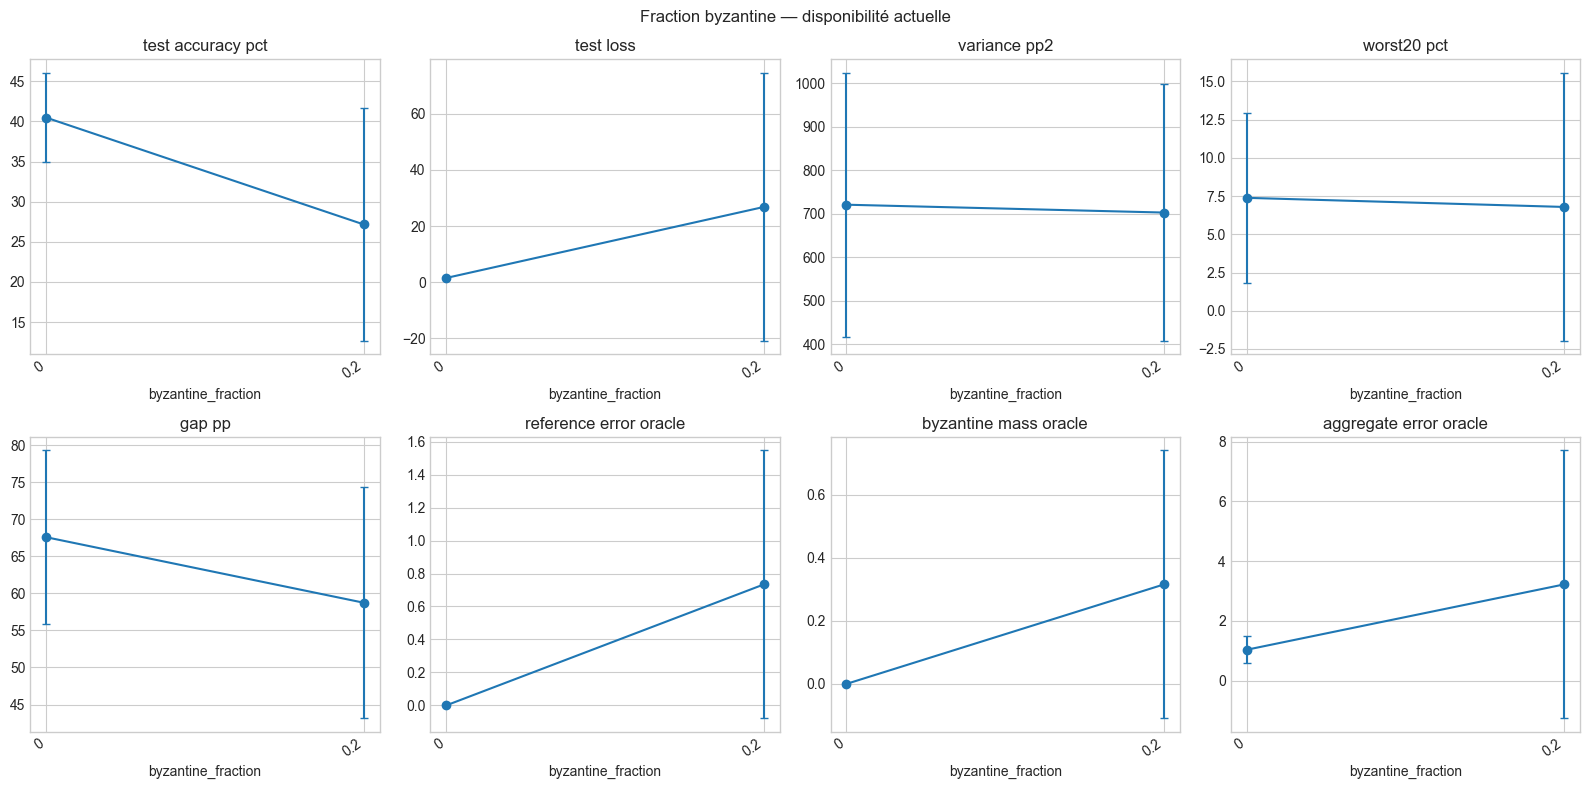

In [50]:
byz_invariants = [
    "campaign", "phase", "horizon", "dataset", "model", "n_clients", "partition",
    "sampling_scheme", "adjacency", "update_mode", "dp_enabled", "target_epsilon",
    "noise_profile", "C_local", "alpha", "reference",
]
byz_view, byz_key = select_axis_cell(final_df, "byzantine_fraction", byz_invariants)
observed_byz = sorted(final_df.byzantine_fraction.dropna().unique().tolist())
print("Fractions disponibles dans tout le snapshot :", observed_byz)
if observed_byz == [0.0]:
    display(Markdown(
        "**Aucun run attaqué n'est encore achevé : la robustesse et l'effet de "
        "la fraction byzantine sont non identifiables dans ce snapshot.**"
    ))
elif observed_byz == [0.0, 0.2]:
    display(Markdown(
        "**Seulement deux points (0 % et 20 %) : présence/absence d'attaque, "
        "aucune conclusion de dose-réponse.**"
    ))
print("Cellule fraction byzantine :", byz_key)
plot_axis_panel(byz_view, "byzantine_fraction", "Fraction byzantine — disponibilité actuelle")

## 11. Développement et évaluation de RCIG — distincts de sa motivation initiale

La section 8.1 expose le problème sur vrais entraînements et le raisonnement de construction. Cette section rassemble les essais synthétiques de développement puis la validation du candidat. Ils ne sont pas présentés comme la preuve qui aurait initialement imposé le choix de RCIG.

### 11.1 Essais intermédiaires de références statiques

La référence inverse-variance a bien réduit une variance linéaire théorique,
mais le gain ne s'est pas transmis à l'agrégat FAR sur Fashion-MNIST. Les audits
synthétiques suivants (`G0b` à `G0f`) montrent aussi que plusieurs références
Gaussian-aware statiques ont échoué au moins un gate préenregistré de qualité,
de rappel des outliers honnêtes ou de robustesse :

- [G0b](../output/analysis/Gaussian_Aware_Robust_Reference_G0b_MPS.md)
- [G0c](../output/analysis/Gaussian_Aware_Robust_Reference_G0c_MPS.md)
- [G0d-F](../output/analysis/Gaussian_Aware_Robust_Reference_G0d_F_MPS.md)
- [G0e](../output/analysis/Gaussian_Aware_Robust_Reference_G0e_Detailed_Analysis.md)
- [G0f](../output/analysis/Gaussian_Aware_Robust_Reference_G0f_Detailed_Analysis.md)

Ces échecs ne constituent pas un théorème d'impossibilité sur toute référence
robuste. Ils motivent une information supplémentaire : **l'identité temporelle
authentifiée** et la comparaison entre un historique ancien et une fenêtre
récente. RCIG teste alors une rupture, et non une simple grande distance dans
une cohorte instantanée.

### 11.2 Construction testée de RCIG

Soient $A_t$ une fenêtre ancienne et $B_t$ une fenêtre récente, toutes deux
strictement antérieures au tour où la référence est utilisée. Elles produisent
$X_t=F(A_t)$ et $Y_t=F(B_t)$. Les matrices $V_{\mathrm{ancien},t}$ et
$V_{\mathrm{récent},t}$ incorporent déjà les covariances nominales transformées
du bruit DP de leurs fenêtres. Il ne faut donc pas ajouter une seconde fois une
covariance DP. Le protocole K7b utilise :

$$
S_t=V_{\mathrm{ancien},t}+V_{\mathrm{récent},t}
+q_{\mathrm{proc},t}I+\xi I,
\qquad
r_t^2=(Y_t-X_t)^\top S_t^{-1}(Y_t-X_t),
$$

où $q_{\mathrm{proc},t}$ représente la variabilité attendue de l'évolution
honnête, et $\xi>0$ est une régularisation numérique qui permet d'inverser la
matrice. Ces quantités sont des approximations à auditer, pas une preuve que
les sorties clippées sont exactement gaussiennes. Le symbole $\xi$ évite toute confusion avec les poids FAR
$\lambda_i$.

Avec un seuil calibré $c$,

$$
w_t=\min\left\{1,\frac{c}{r_t}\right\},
\qquad
F_{\mathrm{RCIG},t}
=\Pi_{B_G}\!\left[X_t+w_t(Y_t-X_t)\right].
$$

On appelle ici **variation temporelle** la différence $Y_t-X_t$. Si sa norme
standardisée $r_t$ ne dépasse pas le seuil $c$, on a $w_t=1$. Au-delà du seuil,
RCIG réduit son amplitude et rapproche la référence de l'historique : avant
projection, il reste sur le segment entre $X_t$ et $Y_t$. Cela ne classe pas
automatiquement un client comme byzantin. On pose $w_t=1$ lorsque $r_t=0$.
Quand $r_t\le c$, la sortie est exactement $Y_t$
seulement si la projection finale est inactive, c'est-à-dire
$\lVert Y_t\rVert_2\le G$. Elle reste conditionnelle à un historique utile :
si l'attaque persistante contamine déjà $A_t$ et $B_t$, cette formule ne fournit
pas à elle seule une garantie Byzantine universelle.

In [51]:
# K7b : lecture des contrastes verrouillés, des lignes d'évaluation et de
# l'extension nulle. Aucun intervalle n'est recalculé avec une autre règle.
k7_root = RESULTS_ROOT / "gaussian_aware_reference_g0g_k7b_rcig_confirmation_mps_v2"
k7_ext_root = RESULTS_ROOT / "gaussian_aware_reference_g0g_k7b_null_extension_mps_v1"
required_k7 = [
    k7_root / "decision.json",
    k7_root / "evaluation_rows.csv",
    k7_ext_root / "decision.json",
]
missing_k7 = [str(path) for path in required_k7 if not path.exists()]
if missing_k7:
    raise FileNotFoundError("Artefacts K7b absents : " + ", ".join(missing_k7))
k7_decision = json.loads((k7_root / "decision.json").read_text(encoding="utf-8"))
k7_extension = json.loads((k7_ext_root / "decision.json").read_text(encoding="utf-8"))
k7_rows = pd.read_csv(k7_root / "evaluation_rows.csv")

contrast_rows = []
for regime in ["homogeneous", "heteroscedastic"]:
    block = k7_decision["primary_contrasts"][regime]
    for key, label in [
        ("attacked_gain_vs_identity_y", "Sous attaque vs Identity-Y"),
        ("no_attack_gain_vs_identity_y", "Sans attaque vs Identity-Y"),
    ]:
        item = block[key]
        contrast_rows.append({
            "Bruit": regime,
            "Contraste": label,
            "Gain moyen (%)": 100 * item["mean"],
            "IC95 bas (%)": 100 * item["two_sided_low"],
            "IC95 haut (%)": 100 * item["two_sided_high"],
            "n": int(item["n"]),
        })
k7_contrasts = pd.DataFrame(contrast_rows)

specificity_rows = []
for key, label in [
    ("heteroscedastic_full_vs_isotropic", "Covariance complète vs approximation isotrope"),
    ("heteroscedastic_full_vs_euclidean", "Covariance complète vs distance euclidienne"),
]:
    item = k7_decision["gaussian_specificity_contrasts"][key]
    specificity_rows.append({
        "Comparaison, bruit hétéroscédastique": label,
        "Gain MSE (%)": 100 * item["mean"],
        "IC95 bas (%)": 100 * item["two_sided_low"],
        "IC95 haut (%)": 100 * item["two_sided_high"],
        "Seeds": int(item["n"]),
    })
k7_specificity = pd.DataFrame(specificity_rows)

k7_mse = (
    k7_rows.groupby(["noise_regime", "threat"], as_index=False)
    .agg(
        identity_y_mse=("identity_y_mse", "mean"),
        rcig_full_mse=("rcig_full_mse", "mean"),
        rcig_activation=("full_gate_active", "mean"),
        seeds=("seed", "nunique"),
    )
)
k7_mse["gain_rcig_vs_identity_pct"] = 100 * (
    1 - k7_mse["rcig_full_mse"] / k7_mse["identity_y_mse"]
)

null_rows = []
for cell, item in k7_extension["combined_null_audits"].items():
    regime, mode = cell.split("_", 1)
    null_rows.append({
        "Bruit": regime,
        "Mode": mode,
        "Activations": f"{item['combined_activations']}/{item['combined_trials']}",
        "Taux (%)": 100 * item["combined_rate"],
        "Borne CP97,5 (%)": 100 * item["CP97_5_upper"],
        "Passe <= 10 %": bool(item["pass"]),
    })
k7_null = pd.DataFrame(null_rows)

display(Markdown("### 11.3 K7b — validation mécanistique synthétique"))
display(Markdown(
    "Ces tests utilisent des vecteurs synthétiques de dimension 8, et non des "
    "images Fashion-MNIST. Identity-Y désigne la référence récente non corrigée. "
    "Le gain est une réduction relative de l'erreur quadratique de la référence "
    "(MSE), **pas un gain d'accuracy**. Les attaques commencent après un historique "
    "propre. Les IC95 ci-dessous portent sur les contrastes appariés entre seeds."
))
display(k7_contrasts.round(2))
display(Markdown("**Apport spécifique de la covariance :**"))
display(k7_specificity.round(2))
display(Markdown(
    "**MSE et activation du gate, calculées depuis `evaluation_rows.csv` :** "
    "le gain du tableau suivant est le rapport des MSE moyennes ; les contrastes "
    "ci-dessus sont la moyenne des gains relatifs appariés. Ces deux statistiques "
    "ne sont pas nécessairement égales."
))
display(k7_mse.round({
    "identity_y_mse": 7,
    "rcig_full_mse": 7,
    "rcig_activation": 3,
    "gain_rcig_vs_identity_pct": 2,
}).rename(columns={
    "noise_regime": "Bruit", "threat": "Attaque",
    "identity_y_mse": "MSE récente Y", "rcig_full_mse": "MSE RCIG",
    "rcig_activation": "Fraction de corrections", "seeds": "Seeds",
    "gain_rcig_vs_identity_pct": "Réduction MSE (%)",
}))
display(Markdown("**Extension nulle indépendante, seuils scientifiques gelés :**"))
display(k7_null.sort_values(["Bruit", "Mode"]).round(2))
display(Markdown(
    "Les bornes nulles de K7b sont **par condition** (360 essais chacune), "
    "et non une borne sur l'union simultanée des six conditions. R1 v2 "
    "ci-dessous teste un critère simultané différent."
))
k7_contrasts.to_csv(RCIG_EXPORT / "k7b_primary_contrasts.csv", index=False)
k7_specificity.to_csv(RCIG_EXPORT / "k7b_covariance_contrasts.csv", index=False)
print("Décision parent K7b :", k7_decision["verdict"])
print("Décision après extension nulle :", k7_extension["verdict"])
print("Limite du claim :", k7_extension["claim_limit"])

### 11.3 K7b — validation mécanistique synthétique

Ces tests utilisent des vecteurs synthétiques de dimension 8, et non des images Fashion-MNIST. Identity-Y désigne la référence récente non corrigée. Le gain est une réduction relative de l'erreur quadratique de la référence (MSE), **pas un gain d'accuracy**. Les attaques commencent après un historique propre. Les IC95 ci-dessous portent sur les contrastes appariés entre seeds.

,Bruit,Contraste,Gain moyen (%),IC95 bas (%),IC95 haut (%),n
0,homogeneous,Sous attaque vs Identity-Y,45.26,40.75,49.78,48
1,homogeneous,Sans attaque vs Identity-Y,0.19,-0.08,0.46,48
2,heteroscedastic,Sous attaque vs Identity-Y,30.66,25.95,35.37,48
3,heteroscedastic,Sans attaque vs Identity-Y,0.14,-0.13,0.41,48


**Apport spécifique de la covariance :**

,"Comparaison, bruit hétéroscédastique",Gain MSE (%),IC95 bas (%),IC95 haut (%),Seeds
0,Covariance complète vs approximation isotrope,1.51,1.21,1.82,48
1,Covariance complète vs distance euclidienne,5.86,5.01,6.71,48


...

,Bruit,Attaque,MSE récente Y,MSE RCIG,Fraction de corrections,Seeds,Réduction MSE (%)
0,heteroscedastic,bitflip_x10,0.000257,0.000161,0.979,48,37.18
1,heteroscedastic,model_replacement,0.000151,0.000116,0.812,48,22.91
2,heteroscedastic,none,0.000036,0.000036,0.042,48,0.13
3,homogeneous,bitflip_x10,0.000207,0.000096,1.000,48,53.87
4,homogeneous,model_replacement,0.000130,0.000076,0.812,48,41.86
5,homogeneous,none,0.000027,0.000026,0.042,48,0.24


**Extension nulle indépendante, seuils scientifiques gelés :**

,Bruit,Mode,Activations,Taux (%),"Borne CP97,5 (%)",Passe <= 10 %
0,heteroscedastic,euclidean,6/360,1.67,3.59,True
1,heteroscedastic,full,7/360,1.94,3.97,True
2,heteroscedastic,isotropic,8/360,2.22,4.33,True
3,homogeneous,euclidean,12/360,3.33,5.75,True
4,homogeneous,full,19/360,5.28,8.12,True
5,homogeneous,isotropic,18/360,5.00,7.79,True


Les bornes nulles de K7b sont **par condition** (360 essais chacune), et non une borne sur l'union simultanée des six conditions. R1 v2 ci-dessous teste un critère simultané différent.

Décision parent K7b : invalid_stop
Décision après extension nulle : advance_to_locked_real_gradient_mechanistic_screen
Limite du claim : synthetic onset-of-attack mechanism only; no end-to-end, fairness, or universal Byzantine robustness claim


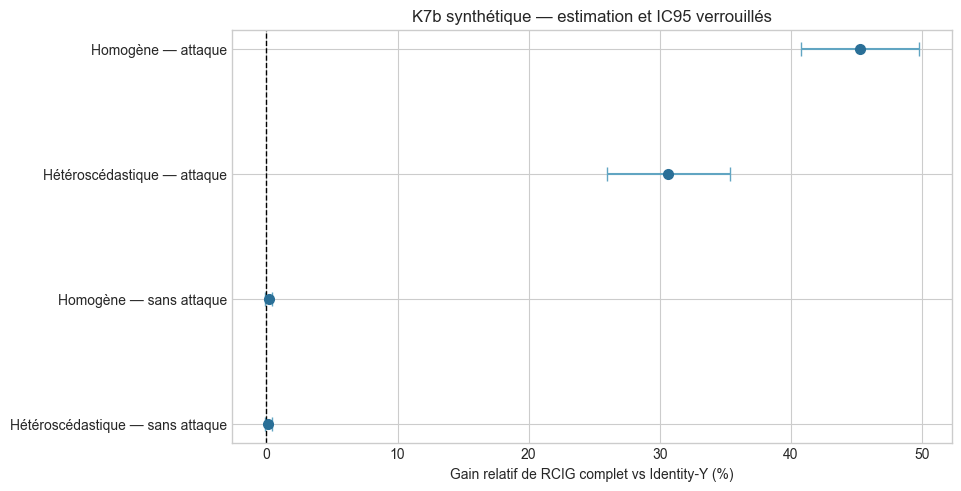

Figure : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/output/analysis/ldp_gradient_far_positioning_notebook/rcig_motivation/k7b_locked_contrasts_ic95.png


In [52]:
# Figure K7b — IC95 lus directement dans decision.json.
plot_df = k7_contrasts.copy()
plot_df["label"] = plot_df.apply(
    lambda r: ("Homogène" if r["Bruit"] == "homogeneous" else "Hétéroscédastique")
    + " — " + ("attaque" if r["Contraste"].startswith("Sous") else "sans attaque"),
    axis=1,
)
plot_df = plot_df.iloc[[0, 2, 1, 3]].reset_index(drop=True)
y = np.arange(len(plot_df))
means = plot_df["Gain moyen (%)"].to_numpy(float)
low = plot_df["IC95 bas (%)"].to_numpy(float)
high = plot_df["IC95 haut (%)"].to_numpy(float)

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
ax.errorbar(
    means, y,
    xerr=np.vstack([means - low, high - means]),
    fmt="o", color="#2A6F97", ecolor="#61A5C2", capsize=5, markersize=7,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(y, plot_df["label"])
ax.set_xlabel("Gain relatif de RCIG complet vs Identity-Y (%)")
ax.set_title("K7b synthétique — estimation et IC95 verrouillés")
ax.invert_yaxis()
path = RCIG_EXPORT / "k7b_locked_contrasts_ic95.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Figure :", path)

In [53]:
# Statut du protocole end-to-end v2. R1 audite l'union simultanée de six
# conditions (2 régimes de bruit × 3 modes), pas le seul gate RCIG-full.
v2_root = RESULTS_ROOT / "rcig_end_to_end_v2"
phase_files = {
    "R0 calibration dynamique": v2_root / "_gates" / "r0_dynamic_calibration.json",
    "R1 validation nulle": v2_root / "_gates" / "r1_dynamic_null.json",
    "R2 mécanisme sous attaque": v2_root / "_gates" / "r2_attack_mechanism.json",
    "R3 confirmation end-to-end": v2_root / "_gates" / "r3_e2e_confirmation.json",
}
status_rows, gates = [], {}
for phase, path in phase_files.items():
    if path.exists():
        payload = json.loads(path.read_text(encoding="utf-8"))
        gates[phase] = payload
        status_rows.append({"Phase": phase, "Artefact": "présent", "Décision": payload["decision"]})
    else:
        status_rows.append({"Phase": phase, "Artefact": "absent", "Décision": "non exécutée"})

display(Markdown("### 11.4 Statut end-to-end v2 : arrêt au gate nul R1"))
display(pd.DataFrame(status_rows))

r1 = gates["R1 validation nulle"]
e = r1["evidence"]
r1_readout = pd.DataFrame([
    {
        "Quantité": "Union globale des 6 conditions activée",
        "Observé": f"{int(e['global_union_false_activation_count'])}/{int(e['paired_seed_blocks'])}",
        "Seuil": "0/36",
        "Passe": False,
    },
    {
        "Quantité": "Borne CP97,5 de cette union globale",
        "Observé": f"{100 * e['global_union_cp97_5_upper']:.2f} %",
        "Seuil": "<= 10 %",
        "Passe": e["global_union_cp97_5_upper"] <= 0.10,
    },
    {
        "Quantité": "Coût de référence sans attaque, borne unilatérale 97,5 %",
        "Observé": f"{100 * e['no_attack_reference_loss_one_sided_97_5_upper']:.4f} %",
        "Seuil": "<= 2 %",
        "Passe": e["no_attack_reference_loss_one_sided_97_5_upper"] <= 0.02,
    },
])
display(r1_readout)

display(Markdown(
    "**Lecture correcte.** R0 a calibré les six cellules avec une couverture "
    "distribution-free simultanée, puis R1 a observé une activation dans un des "
    "36 blocs appariés. Le taux brut (1/36) est faible, mais sa borne exacte "
    "CP97,5 reste à 14,53 %, au-dessus du seuil préenregistré de 10 % ; le "
    "protocole impose donc `stop`. C'est un échec du critère de validation, "
    "pas une preuve que le vrai taux dépasse 10 %. Cette statistique est l'**union** des modes "
    "full, isotropic et euclidean dans les deux régimes de bruit : elle ne doit "
    "pas être présentée comme le taux de fausse activation du seul RCIG-full. "
    "Le coût sans attaque passe largement son gate, mais R2 et R3 étant absents, "
    "nous n'avons encore aucune confirmation v2 sur attaques persistantes, "
    "accuracy, Worst-20, gap ou robustesse end-to-end."
))
print("Sources :", phase_files["R0 calibration dynamique"], "et", phase_files["R1 validation nulle"])
display(Markdown('''
#### Comprendre « 1 bloc sur 36 » et « borne supérieure de 14,53 % »

Un **bloc apparié** correspond à une seed et à deux entraînements de 40 tours,
l'un à bruit homogène et l'autre à bruit hétéroscédastique. Dans chaque
entraînement, trois règles (covariance complète, isotrope, distance
euclidienne) sont évaluées sur le même transcript privé. On compte le bloc
une seule fois dès qu'au moins une règle s'active à un tour évalué dans l'un
des deux régimes. Ce ne sont donc ni 36 clients, ni 36 tours, ni six
répétitions indépendantes par seed.

Dans R1, **aucune attaque n'est présente**. Une activation est donc une
fausse alarme du détecteur de rupture. La seed **820005** est le seul bloc
positif : en bruit homogène, la règle euclidienne s'active au tour 20, puis
les trois règles au tour 21 ; en bruit hétéroscédastique, les trois règles
s'activent au tour 21. Ces activations liées comptent ensemble comme **un
seul bloc positif**.

- **Fréquence observée : 1 / 36 = 2,78 %.**
- **Borne supérieure unilatérale exacte à 97,5 % : 14,53 %.** C'est une
  marge d'incertitude sur le taux de blocs positifs dans de nouvelles
  répétitions indépendantes du même protocole, pas un taux mesuré de 14,53 %.
  La construction Clopper–Pearson garantit une couverture d'au moins 97,5 %
  lorsque ses hypothèses binomiales sont satisfaites.
- Le protocole exigeait **zéro bloc positif et une borne au plus égale à
  10 %**. Avec zéro sur 36, la borne aurait été 9,74 % ; avec un sur 36,
  elle devient 14,53 %. Le gate ne passe donc pas. Cela ne démontre pas que
  le vrai taux dépasse 10 %, et ne mesure pas une perte d'accuracy.

**R1 n'est pas relancé sur les mêmes seeds** : cela n'ajouterait pas de
répétitions indépendantes. Son échec reste enregistré. R2 et R3 sont demandés
comme une **continuation exploratoire séparée**, sans promotion de R1 et sans
retouche de ses seuils. Leurs sorties sont séparées dans
`results/ldp_gradient_far/rcig_r2_r3_exploratory_v1` ; le tableau v2 ci-dessus
continue de décrire uniquement le protocole confirmatoire initial.
'''))

### 11.4 Statut end-to-end v2 : arrêt au gate nul R1

,Phase,Artefact,Décision
0,R0 calibration dynamique,présent,promote
1,R1 validation nulle,présent,stop
2,R2 mécanisme sous attaque,absent,non exécutée
3,R3 confirmation end-to-end,absent,non exécutée


,Quantité,Observé,Seuil,Passe
0,Union globale des 6 conditions activée,1/36,0/36,False
1,"Borne CP97,5 de cette union globale",14.53 %,<= 10 %,False
2,"Coût de référence sans attaque, borne unilatér...",0.0068 %,<= 2 %,True


**Lecture correcte.** R0 a calibré les six cellules avec une couverture distribution-free simultanée, puis R1 a observé une activation dans un des 36 blocs appariés. Le taux brut (1/36) est faible, mais sa borne exacte CP97,5 reste à 14,53 %, au-dessus du seuil préenregistré de 10 % ; le protocole impose donc `stop`. C'est un échec du critère de validation, pas une preuve que le vrai taux dépasse 10 %. Cette statistique est l'**union** des modes full, isotropic et euclidean dans les deux régimes de bruit : elle ne doit pas être présentée comme le taux de fausse activation du seul RCIG-full. Le coût sans attaque passe largement son gate, mais R2 et R3 étant absents, nous n'avons encore aucune confirmation v2 sur attaques persistantes, accuracy, Worst-20, gap ou robustesse end-to-end.

Sources : /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/ldp_gradient_far/rcig_end_to_end_v2/_gates/r0_dynamic_calibration.json et /Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/results/ldp_gradient_far/rcig_end_to_end_v2/_gates/r1_dynamic_null.json



#### Comprendre « 1 bloc sur 36 » et « borne supérieure de 14,53 % »

Un **bloc apparié** correspond à une seed et à deux entraînements de 40 tours,
l'un à bruit homogène et l'autre à bruit hétéroscédastique. Dans chaque
entraînement, trois règles (covariance complète, isotrope, distance
euclidienne) sont évaluées sur le même transcript privé. On compte le bloc
une seule fois dès qu'au moins une règle s'active à un tour évalué dans l'un
des deux régimes. Ce ne sont donc ni 36 clients, ni 36 tours, ni six
répétitions indépendantes par seed.

Dans R1, **aucune attaque n'est présente**. Une activation est donc une
fausse alarme du détecteur de rupture. La seed **820005** est le seul bloc
positif : en bruit homogène, la règle euclidienne s'active au tour 20, puis
les trois règles au tour 21 ; en bruit hétéroscédastique, les trois règles
s'activent au tour 21. Ces activations liées comptent ensemble comme **un
seul bloc positif**.

- **Fréquence observée : 1 / 36 = 2,78 %.**
- **Borne supérieure unilatérale exacte à 97,5 % : 14,53 %.** C'est une
  marge d'incertitude sur le taux de blocs positifs dans de nouvelles
  répétitions indépendantes du même protocole, pas un taux mesuré de 14,53 %.
  La construction Clopper–Pearson garantit une couverture d'au moins 97,5 %
  lorsque ses hypothèses binomiales sont satisfaites.
- Le protocole exigeait **zéro bloc positif et une borne au plus égale à
  10 %**. Avec zéro sur 36, la borne aurait été 9,74 % ; avec un sur 36,
  elle devient 14,53 %. Le gate ne passe donc pas. Cela ne démontre pas que
  le vrai taux dépasse 10 %, et ne mesure pas une perte d'accuracy.

**R1 n'est pas relancé sur les mêmes seeds** : cela n'ajouterait pas de
répétitions indépendantes. Son échec reste enregistré. R2 et R3 sont demandés
comme une **continuation exploratoire séparée**, sans promotion de R1 et sans
retouche de ses seuils. Leurs sorties sont séparées dans
`results/ldp_gradient_far/rcig_r2_r3_exploratory_v1` ; le tableau v2 ci-dessus
continue de décrire uniquement le protocole confirmatoire initial.


### 11.5 Verdict scientifique actuel

| Niveau | Ce qui est soutenu | Ce qui ne l'est pas encore |
|---|---|---|
| Vrais gradients privés, sans attaque | FAR positif et la référence inverse-variance peuvent dégrader performance et fairness, surtout sous hétéroscédasticité | causalité universelle du bruit, supériorité d'une référence temporelle |
| Oracles D2 | le score brut suit fortement le niveau de bruit dans ces cellules et retrouve mal la géométrie propre | diagnostic déployable ; preuve Byzantine |
| K7b synthétique | RCIG réduit la MSE lors d'une attaque qui commence après un historique propre ; la covariance complète apporte un gain sous bruit hétéroscédastique | accuracy/fairness ; attaque persistante contaminant les deux fenêtres ; haute dimension |
| End-to-end v2 | R0 est valide ; R1 montre un coût de référence négligeable dans le protocole | le gate nul simultané échoue ; R2/R3 ne sont pas exécutés |

**Statut : RCIG est un candidat mécanistiquement motivé, pas un algorithme final
validé.** Le passage à une revendication publiable nécessite un protocole nul
qui passe sans retoucher les seuils, puis les phases verrouillées sur vrais
gradients privés sous attaques persistantes et, enfin, les métriques end-to-end.